In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import (
    skew,
    kurtosis,
    spearmanr,
    chi2_contingency,
    binomtest,
    pointbiserialr
)
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def cardinality_check(data, width=25):
    """
    Print a cardinality summary for all columns in a dataset.

    For each column, displays the number of unique values, the data type,
    and up to 4 sample values sorted alphabetically. Useful for identifying
    categorical fields, zero-variance columns, and potential encoding issues
    during initial data analysis.

    Parameters
    ----------
    data : pd.DataFrame
        The dataset to analyse.
    width : int, optional
        Column name display width. Default is 25.

    Examples
    --------
    >>> cardinality_check(nba_data)
    >>> cardinality_check(betting_data, width=30)
    """
    print("=== Cardinality Analysis ===")
    print(f"{'Field':<{width}} {'Unique':>8}  {'Type':<10}  Sample values")
    print("-" * 80)
    for col in sorted(data.columns):
        n = data[col].nunique()
        dtype = str(data[col].dtype)
        vals = data[col].dropna().unique()
        sample = sorted([str(v) for v in vals if str(v) != 'nan'])[:4]
        print(f"  {col:<{width-2}} {n:>6}  {dtype:<10}  {sample}")

In [4]:
def plot_redundancy(data, title='Dataset Redundancy Check (IDA)', figsize=(12, 12)):
    """
    Visualises variable redundancy using hierarchical clustering based on 
    Spearman rank correlation. Columns with zero variance are automatically 
    excluded. All variable types (categorical, numeric, boolean) are handled 
    via factorization before correlation is computed.
    
    Parameters
    ----------
    data : pd.DataFrame
        Input dataset. All column types are supported.
    title : str
        Plot title. Default: 'Dataset Redundancy Check (IDA)'.
    figsize : tuple
        Figure size. Default: (12, 12).
    
    Returns
    -------
    None. Displays a dendrogram where variables that cluster together 
    at low distance values carry redundant information and are candidates 
    for exclusion or consolidation.
    
    Notes
    -----
    - Distance = 1 - |Spearman r|, so distance = 0 means perfect correlation.
    - Clustering method: 'complete' linkage (max distance between clusters).
    - Variables with a single unique value are dropped before computation.
    - Distance matrix is symmetrised via (D + D.T) / 2 to correct for
      floating point asymmetries introduced by Spearman correlation computation.
    """
    dataset = data.copy()
    dataset = dataset.loc[:, dataset.nunique() > 1]
    dataset_numeric = dataset.apply(lambda x: pd.factorize(x)[0])
    corr_matrix, _ = spearmanr(dataset_numeric)
    corr_matrix = np.nan_to_num(corr_matrix)
    distance_matrix = 1 - np.abs(corr_matrix)
    distance_matrix = (distance_matrix + distance_matrix.T) / 2
    np.fill_diagonal(distance_matrix, 0)
    dist_linkage = hierarchy.linkage(squareform(distance_matrix), method='complete')
    fig, ax = plt.subplots(figsize=figsize)
    hierarchy.dendrogram(
        dist_linkage,
        labels=dataset.columns.tolist(),
        ax=ax,
        orientation='right',
        leaf_font_size=10,
        color_threshold=0.6
    )
    ax.set_title(title)
    ax.set_xlabel('Distance (1 - |Spearman r|)')
    plt.tight_layout()
    plt.show()

In [5]:
def build_convergence_table(rq1_results, rq2_results, order=None):
    """
    Merges RQ1 and RQ2 results by period and computes convergence.
    
    Parameters:
        rq1_results : dict — results from Monte Carlo simulation
        rq2_results : dict — results from Binomial test
        order       : list — optional sort order for periods
    
    Returns:
        DataFrame with columns: Period, RQ1 p-val, RQ1, RQ2 p-val, RQ2, Convergence
    """
    df_rq1 = pd.DataFrame.from_dict(rq1_results, orient="index").add_suffix("_rq1")
    df_rq2 = pd.DataFrame.from_dict(rq2_results, orient="index").add_suffix("_rq2")
    df = df_rq1.join(df_rq2, how="inner").reset_index().rename(columns={"index": "Period"})
    df["Convergence"] = "Partial"
    df.loc[(df["test_rq1"] == "Rejected") & (df["test_rq2"] == "Rejected"), "Convergence"] = "Full"
    result = df.rename(columns={
        "pval_rq1": "RQ1 p-val", "test_rq1": "RQ1",
        "pval_rq2": "RQ2 p-val", "test_rq2": "RQ2"
    })[["Period", "RQ1 p-val", "RQ1", "RQ2 p-val", "RQ2", "Convergence"]]
    if order:
        result = result.set_index("Period").loc[order].reset_index()
    return result



# Two Channels of Home-Court Advantage: NBA Close Games as a Testbed

## 1. Abstract

Referee decisions in professional sports are not made in a vacuum. Home-court advantage is well documented, but the mechanisms behind it remain debated. This study examines two independent channels through which it may operate in NBA close games — referee error direction and betting market pricing — and asks whether they respond consistently to changes in crowd presence conditions. NBA Last Two Minute (L2M) reports provide ground truth for referee errors, aggregated to the game level via the Net Whistle Gain (NWG) metric. Pre-game point spreads and cover outcomes from independent bookmakers provide the market signal. The COVID-19 period, during which games were played without fans, serves as a natural experiment. Data covers three periods: Pre-COVID (2015–2019), COVID (2020–2022), and Post-COVID (2023–2025).

## 2. Introduction

Home-court advantage is well documented — referees have been shown to contribute to it through systematic errors favouring the home team [PelechrinisL2M]. Whether this reflects crowd pressure, market belief, or both remains an open question. This study treats referee behavior and betting market pricing as two independent signals and asks whether they respond consistently to the same external conditions. The COVID-19 pandemic, which removed fans from arenas for two seasons, provides a natural experiment for separating these effects.

### 2.1 Background

Home-court referee bias has been linked to crowd pressure [PelechrinisL2M]. The COVID-19 pandemic (seasons 2020–2022) provides natural variation in crowd conditions, allowing comparisons across three periods with different levels of social pressure. Referee decisions and market pricing operate through different mechanisms — one during the game, the other before it — and are independent by design.

### 2.2 Data Sources

Two independent datasets are used — one for each channel.

The NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M] provide official grading of referee decisions in the final two minutes of close games. Referee errors are aggregated to the game level via the Net Whistle Gain (NWG) metric, following Pelechrinis (2023) [PelechrinisL2M].

The NBA betting dataset [KaggleBetting] provides pre-game point spreads and cover outcomes set by independent bookmakers, covering the same period as the L2M reports.

## 3. Methods

This study examines two independent channels through which home-court advantage may operate in NBA close games.

The **Reactive Channel** asks whether referee errors systematically favour the home team — and whether this effect varies with crowd presence. Under the crowd pressure hypothesis, a positive net whistle gain for the home team is expected in periods with fans, and a reduced or absent effect during the fanless COVID period.

The **Inertial Channel** asks whether the betting market systematically overestimates home-court advantage in close games — reflected in the home team covering the spread less than half the time. Under the collective belief hypothesis, this effect would persist even during the COVID period when no fans were present.

The two channels are independent by design — spreads are set before the game, so bookmakers cannot observe referee decisions at the time of pricing. No causal link between the two signals is assumed.

Structural convergence in this study refers to a process where two initially separate channels — the Reactive Channel and the Inertial Channel — respond in the same direction under the same crowd-related conditions, despite being driven by different mechanisms. Structural convergence is not tested directly as a hypothesis — it is an interpretive framework applied to the joint results of RQ1 and RQ2. If both channels are rejected in the same periods and fail to reject in the same periods, convergence is observed. If they diverge, the two channels operate independently.

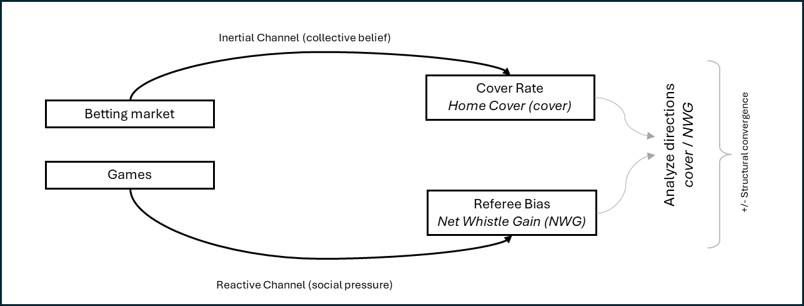  
*Fig. 1 — The Structural Convergence Framework*

### 3.1 Key Variables & Definitions

NBA referees make split-second decisions on potential violations throughout the game. The NBA Last Two Minute reports grade every such decision in the final two minutes of close games — each play is classified as a Correct Call (CC), Incorrect Call (IC), Incorrect Non-Call (INC), or Correct Non-Call (CNC). A CC means the referee made the right call. An IC means a violation was called that did not occur — the penalized team was wrongly disadvantaged. An INC means a real violation was missed — the offending team escaped a penalty. CNC entries are excluded from analysis as their definition changed across seasons.

In NBA betting, bookmakers set a points gap — the spread — before each game. The home team must win by more than the spread to "cover." If the home team is listed at −5.5, they must win by 6 or more points. If they win by 3, they did not cover despite winning the game. A game ending exactly on the spread is a push — the bet is returned and the game is excluded from cover analysis.

Before formalizing the hypotheses, we define the two primary metrics used throughout the analysis.

**Net Whistle Gain ($NWG$)** — the net count of referee errors favouring the home team over the away team in the final two minutes of a close game. A positive value indicates net home bias; a negative value indicates net away bias; zero indicates no bias. Formally:

$$\beta = |\{ \text{INC} : \text{committing\_side} = \text{home} \}| + |\{ \text{IC} : \text{disadvantaged\_side} = \text{home} \}|$$

$$\delta = |\{ \text{INC} : \text{disadvantaged\_side} = \text{home} \}| + |\{ \text{IC} : \text{committing\_side} = \text{home} \}|$$

$$NWG = \beta - \delta$$

**Cover Outcome** — a binary variable indicating whether the home team beat the point spread set by bookmakers before the game. Takes the value 1 if the home team covered, 0 if it did not. Pushes are excluded.

$$\text{cover} = \begin{cases} 1 & \text{if home team beat the spread} \\ 0 & \text{if home team did not beat the spread} \\ \text{excluded} & \text{if margin} = \text{spread (push)} \end{cases}$$

**Cover Rate** — the proportion of games in which the home team covered the spread, aggregated across a set of games.

$$\text{cover rate} = \frac{\sum \text{cover}}{n_{\text{games}}}$$

**Point Spread** — the pre-game margin set by bookmakers representing their expectation of the home team's winning margin. A negative spread indicates the home team is favoured — they must win by more than the spread to cover. A positive spread indicates the home team is the underdog — they cover by losing by less than the spread or winning outright. Measured in points.

### 3.2 Formal Statistical Framework

The two channels are tested independently at the game level, using the same observational unit for both hypotheses. Structural Convergence requires that RQ1 and RQ2 operate on the same observational unit — a game-level test for RQ1 ensures direct comparability with RQ2. A play-level replication check following Pelechrinis (2023) [PelechrinisL2M] is also conducted for methodological transparency.

#### 3.2.1 Reactive Channel Hypothesis

$$H_0^{RQ1}: P(NWG > 0) \leq 0.50$$
$$H_1^{RQ1}: P(NWG > 0) > 0.50$$

Under $H_0^{RQ1}$, referee errors are equally likely to favour either team. The test statistic is the number of games with $NWG > 0$. Games with $NWG = 0$ carry no directional information and are excluded. Under $H_0^{RQ1}$, the number of positive-NWG games follows $B(n, 0.5)$. The one-sided p-value is:

$$p = P(X \geq k \mid X \sim B(n, 0.5))$$

where $k$ is the observed number of games with $NWG > 0$ and $n$ is the total number of non-zero NWG games.

#### 3.2.2 Inertial Channel Hypothesis

$$H_0^{RQ2}: P(\text{cover} = 1) \geq 0.50$$
$$H_1^{RQ2}: P(\text{cover} = 1) < 0.50$$

Under $H_0^{RQ2}$, the number of games where the home team covers follows $B(n, 0.5)$. The one-sided p-value is:

$$p = P(X \leq k \mid X \sim B(n, 0.5))$$

where $k$ is the observed number of covers and $n$ is the total number of games with a valid cover outcome. Push games ($home\_covered = NaN$) are excluded.

Both tests are conducted across three temporal periods: Pre-COVID (2015–2019), COVID (2020–2022), and Post-COVID (2023–2025).

### 3.3 Variables

For each game we measure the following variables.

**Whistle Benefit ($\beta$)** — the count of referee errors favouring the home team at the play level. For each graded play, the committing side identifies the team committing the infraction and the disadvantaged side identifies the team disadvantaged by it. These two fields operationalise $\beta$ and $\delta$ as defined in Section 3.2.

**Whistle Detriment ($\delta$)** — the count of referee errors favouring the away team at the play level. Formally defined in Section 3.2.

**Net Whistle Gain ($NWG$)** — the net difference between referee errors favouring the home team and referee errors favouring the away team in a game. Positive values indicate home bias; negative values indicate away bias; zero indicates no bias. Used to determine the direction of referee errors per game — the Sign Test counts games with $NWG > 0$ as the primary test statistic for $H_0^{RQ1}$.

**Asymmetry Ratio ($AR$)** — an alternative expression of $NWG$ as a proportion. Undefined when $\beta + \delta = 0$. Formally defined in Section 3.2.

**Point Spread** — pre-game market expectation of the home team's margin, used in the construction of the cover outcome variable.

**Cover Outcome** — binary outcome indicating whether the home team beat the spread. The primary test statistic for $H_0^{RQ2}$. Pushes are excluded.

**Control Variables** — season, temporal period (Pre-COVID / COVID / Post-COVID), playoff status, and attendance as a proxy for crowd pressure.

### 3.4 Assumptions

1. L2M grades are treated as ground truth for referee error classification.
2. Errors are independent across plays within a game.
3. The three periods (Pre-COVID, COVID, Post-COVID) are structurally distinct with respect to crowd presence conditions — this assumption is tested empirically in Section 7.2.
4. Betting lines are set before the game with no access to L2M data — bookmakers cannot observe referee errors at the time of line setting.
5. CNC decisions are excluded — their grading criteria changed across seasons [PelechrinisL2M].
6. This study does not test real-time market efficiency. $NWG$ is a post-game measure and cannot be used as a trading signal. Structural Convergence requires only that both signals consistently point in the same direction — not that one predicts the other.

All tests are conducted at $\alpha = 0.05$.

### 3.5 Glossary

**Point Spread** — Pre-game margin set by bookmakers. Example: Lakers $-5.5$ must win by 6+ points to cover.

**Cover** — A team covers when they beat the bookmaker's margin. Throughout this study, *cover* refers exclusively to the home team covering the spread. The favourite covers by winning by more than the spread; the underdog covers by losing by less (or winning outright). Pushes are excluded from all cover rate calculations.

**Push** — Final margin equals the spread exactly. No winner — stakes returned. Pushes are excluded from cover rate calculations.

**INC (Incorrect Non-Call)** — A violation occurred but was not called. Example: a clear push-off goes uncalled in the final minute.

**IC (Incorrect Call)** — A call was made but no violation occurred. Example: a foul is called on a defender who did not make contact.

**L2M Report** — Official NBA post-game grading of every referee decision in the final two minutes of close games. Published since March 2015.

**NWG (Net Whistle Gain)** — Net referee errors favouring the home team. Positive = home bias; negative = away bias; zero = no bias. Formally defined in Section 3.2.

**AR (Asymmetry Ratio)** — NWG expressed as a proportion: $AR = 0.5$ indicates no bias; $AR > 0.5$ indicates home bias; $AR < 0.5$ indicates away bias. Undefined when $\beta + \delta = 0$. Formally defined in Section 3.2.

**Market Mispricing** — The systematic deviation of the home team cover rate from 50% in close games, as tested via $H_0^{RQ2}$.

**Structural Convergence** — The hypothesis that two independent signals — NWG and cover rate — consistently point in the same direction, without requiring a causal link between them. Full convergence requires both channels to reject their respective null hypotheses; partial convergence is observed when only one channel rejects.

## 4. Initial Data Analysis (IDA)

This study draws on two independently collected datasets. The first is the NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M], selected as the primary source for referee error classification because it provides official NBA grading of every decision in the final two minutes of close games.  

The second is the NBA betting dataset [KaggleBetting], selected as an independent source for market pricing data covering the same period. The two datasets are analyzed separately before being merged into a single game-level master dataset.

### 4.1 NBA Last Two Minute Reports (L2M)

#### 4.1.1 Dataset Overview

The primary dataset is the NBA Last Two Minute (L2M) reports, maintained by atlhawksfanatic [AtlhawksfanaticL2M]. A Last Two Minute Report is a play-by-play grading of all calls and material non-calls in the last two minutes of the fourth quarter or the last two minutes of any overtime period, for all games that were within 5 points at that stage. The dataset is compiled from two sources: archived PDF reports for earlier seasons and the official NBA API for more recent ones, supplemented with box score data from stats.nba.com which adds attendance and player minutes [AtlhawksfanaticL2M]. The full list of variables is described in the README of [AtlhawksfanaticL2M].

**Each row represents a single graded referee decision — the observational unit is a referee decision, not a game.**

#### 4.1.2 Data Quality

##### Shape

The dataset dimensions are inspected to confirm that the file was read correctly.

In [6]:
# Download file or use direct read
nba_data = pd.read_csv('data/input/L2M_stats_nba.zip', low_memory=False)

# nba_data = pd.read_csv('https://ai-and-ml-2026.s3.eu-north-1.amazonaws.com/decision-bias-study/data/L2M_stats_nba.zip', low_memory=False)

In [7]:
nba_data = pd.read_csv('data/input/L2M_stats_nba.zip', low_memory=False)

print(nba_data.head())
# Shape
print('Shape:', nba_data.shape)

  period     time         call_type decision  \
0     Q4  01:52.0    Foul: Shooting      CNC   
1     Q4  01:43.0    Foul: Shooting       CC   
2     Q4  01:32.0    Foul: Shooting       CC   
3     Q4  01:09.0  Foul: Loose Ball       CC   
4     Q4  00:53.0    Foul: Shooting      CNC   

                         game_details  page                    file  \
0  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
1  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
2  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
3  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
4  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   

      game_date  away_team home_team  ... committing_min committing_team  \
0  Mar 01, 2015  Cavaliers   Rockets  ...      30.950000             HOU   
1  Mar 01, 2015  Cavaliers   Rockets  ...      50.800000             CLE   
2  Mar 01, 2015  Cavaliers   Rockets  ...      42.233333

The dataset contains 90,302 rows and 64 columns. Each row represents a single graded play — either a call made by referees or a potential violation that was not called. It is fully described in the README of [AtlhawksfanaticL2M]. Based on the source documentation, the following columns are identified as candidates for analysis.

##### Data Types

Inspecting the type of each column identifies potential parsing issues. Dates stored as strings or booleans stored as objects will require conversion before analysis.

In [8]:
dtype_groups = nba_data.dtypes.reset_index()
dtype_groups.columns = ['column', 'dtype']
for dtype, group in dtype_groups.groupby('dtype'):
    print(f"\n{dtype}:")
    for col in group['column']:
        print(f"  {col}")


bool:
  playoff

int64:
  gid
  home_score
  away_score
  season
  time_min

float64:
  page
  game_id
  ImposibleIndicator
  VideolLink
  Qualifier
  posID
  posTeamId
  teamIdInFavor
  errorInFavor
  imgChart
  GameId
  HomeTeamId
  AwayTeamId
  GAME_ID
  ATTENDANCE
  committing_min
  disadvantaged_min
  time_sec
  time2

object:
  period
  time
  call_type
  decision
  game_details
  file
  game_date
  away_team
  home_team
  date
  call
  type
  home
  away
  gcode
  national_tv
  networks
  PCTime
  Difficulty
  posStart
  posEnd
  GameDate
  L2M_Comments
  committing_team
  committing_side
  disadvantaged_team
  disadvantaged_side
  type2


> **Data Types** --- All 53 columns are inspected for parsing issues. A full description of each column is available in the source documentation [AtlhawksfanaticL2M]. Key columns have the expected types: `playoff` is `bool`, `season` and `ATTENDANCE` are numeric, and categorical columns (decision, committing_side, disadvantaged_side, call_type, period) are object, consistent with string-encoded categorical variables in pandas. Three columns require conversion before analysis: `date`, `game_date`, and `GameDate` are stored as `object` and require datetime conversion. `GAME_ID` is `float64` but represents integer game IDs. Columns originating from the official NBA API are not applicable for PDF-sourced games and their missingness is examined in the following section. Columns containing personal information --- player names and referee identities --- have been excluded on ethical grounds and are therefore absent from the dataset. All conversions will be performed in the Tidy Data Preparation section.

##### Missing Values

Columns with missing values are identified and quantified. The source and treatment of each missing value group is examined before any imputation or exclusion decision is made.

In [9]:
missing = nba_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
print(f"\n{missing.to_string()}")

Columns with missing values: 34

Qualifier             90302
teamIdInFavor         90302
errorInFavor          90302
L2M_Comments          89809
networks              88993
game_details          58270
page                  58270
Difficulty            34148
GameDate              32032
HomeTeamId            32032
posID                 32032
posStart              32032
ImposibleIndicator    32032
VideolLink            32032
posEnd                32032
posTeamId             32032
PCTime                32032
game_id               32032
AwayTeamId            32032
imgChart              32032
GameId                32032
disadvantaged_min     11681
ATTENDANCE             6509
disadvantaged_team     5801
disadvantaged_side     5801
committing_min         3183
decision               2502
committing_side        2433
committing_team        2433
GAME_ID                 631
call_type                48
call                     48
type                     48
type2                    48


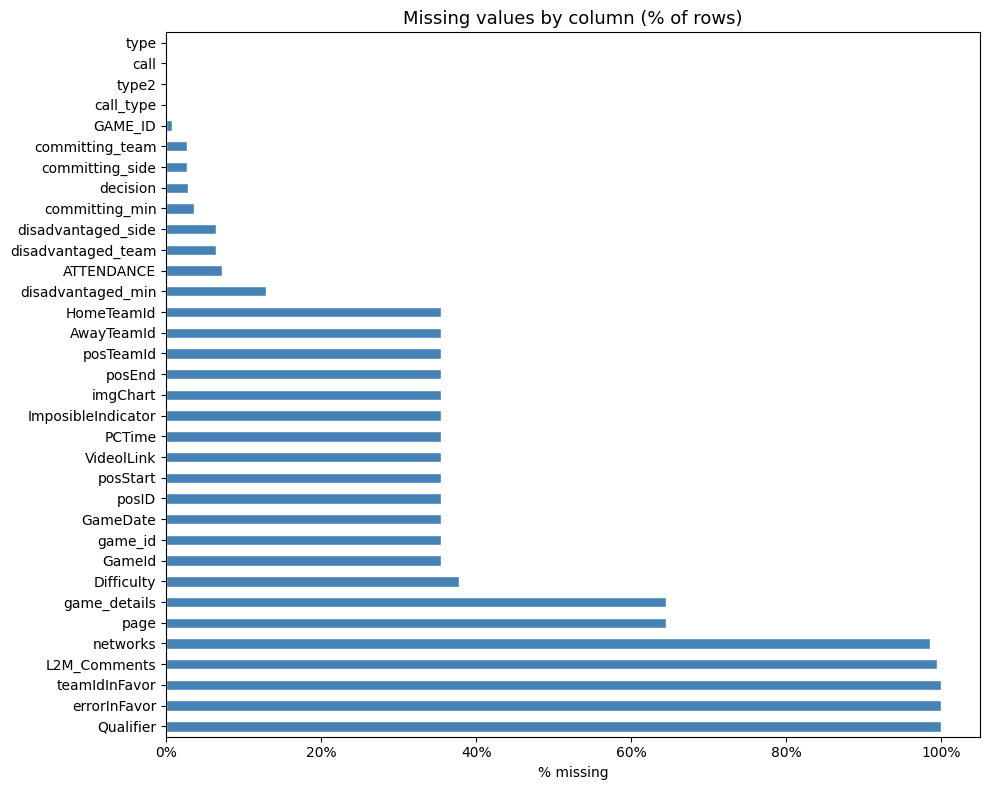

Columns with missing values: 34 / 53


In [10]:
# Missing values by column
missing = nba_data.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 8))
missing.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Missing values by column (% of rows)', fontsize=13)
ax.set_xlabel('% missing')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

print(f"Columns with missing values: {len(missing)} / {len(nba_data.columns)}")

**Missing Values** --- Missing values are identified across all columns and fall into three categories.

* **Expected and structural:** `game_details` and `page` have 58,270 missing values each --- absent for all API-sourced games. `Qualifier`, `teamIdInFavor`, `errorInFavor`, `L2M_Comments`, and `networks` are largely or entirely missing and are not used in the analysis. `game_id`, `PCTime`, `ImposibleIndicator`, `VideolLink`, `posID`, `posStart`, `posEnd`, `posTeamId`, `imgChart`, `GameId`, `GameDate`, `HomeTeamId`, and `AwayTeamId` have exactly 32,032 missing values each --- corresponding to PDF-sourced games for which the API data is not available.

* **Require attention:** `decision` has 2,502 missing values representing plays not detectable without technology, excluded from analysis following Pelechrinis (2023) [PelechrinisL2M]. `committing_side` and `committing_team` have 2,433 missing values each, while `disadvantaged_side` and `disadvantaged_team` have 5,801 --- these are critical for $\beta$ and $\delta$ calculations and are examined in the Tidy Data Preparation section. `ATTENDANCE` has 6,509 missing values. `GAME_ID` has 631 missing values.

* **Known data quality issues:** `call_type`, `call`, `type`, and `type2` share 48 missing values --- the same rows. `committing_min` has 3,183 missing values and `disadvantaged_min` has 11,681, partly due to NBA input errors [AtlhawksfanaticL2M]. The treatment of all remaining missing values is deferred to the Tidy Data Preparation section.

##### Duplicates

Duplicate rows are identified to assess data integrity.

In [11]:
print(f"Duplicate rows: {nba_data.duplicated().sum()}")
print(f"Total rows: {len(nba_data)}")

Duplicate rows: 58
Total rows: 90302


> **Duplicates** --- The dataset contains 58 duplicate rows out of 90,302, corresponding to less than $0.1\%$ of the data. These are examined at the raw dataset level only. After column selection in the Tidy Data Preparation section, additional duplicates may emerge as a result of dropping identifying columns --- this will be re-examined after tidying.

The cardinality of each column is examined to identify categorical fields, columns with a single unique value (zero variance), and potential encoding issues such as mixed types or unexpected string representations of numeric values.

In [12]:
# Cardinality check for all columns
cardinality_check(nba_data)

=== Cardinality Analysis ===
Field                       Unique  Type        Sample values
--------------------------------------------------------------------------------
  ATTENDANCE                2175  float64     ['0.0', '1000.0', '10079.0', '1008.0']
  AwayTeamId                  30  float64     ['1610612737.0', '1610612738.0', '1610612739.0', '1610612740.0']
  Difficulty                   5  object      ['Blatant/Hard', 'Difficult', 'Observable', 'Technical']
  GAME_ID                   4454  float64     ['12000007.0', '12100023.0', '21400880.0', '21400883.0']
  GameDate                  2101  object      ['2019-01-01T00:00:00', '2019-01-02T00:00:00', '2019-01-03T00:00:00', '2019-01-04T00:00:00']
  GameId                    2810  float64     ['12000007.0', '12100023.0', '21800552.0', '21800561.0']
  HomeTeamId                  30  float64     ['1610612737.0', '1610612738.0', '1610612739.0', '1610612740.0']
  ImposibleIndicator           1  float64     ['0.0']
  L2M_Comments     

> **Cardinality Analysis**
>
> **Core analytical fields** — `decision` contains exactly 4 values (CC, CNC, IC, INC) with no formatting inconsistencies, ensuring exact NWG aggregation. `committing_side` and `disadvantaged_side` are strictly binary (home/away), confirming a clean Home vs Away model.
>
> **Game identification fields** — `playoff` is strictly binary, `season` covers exactly 11 seasons (2015–2025), and `gid` has 4,487 unique values consistent with the expected number of close games.
>
> **Temporal fields** — `period` contains 5 values (Q4–Q7): Q4 is the standard final regulation period while Q5–Q7 represent overtime periods, capturing the highest-intensity game conclusions where structural convergence is most likely to occur.
>
> **Empty and zero-variance fields** — `Qualifier`, `teamIdInFavor`, and `errorInFavor` have zero unique values, justifying manual NWG calculation via `decision` and `side` rather than relying on missing pre-computed columns. `ImposibleIndicator` has a single value (0.0) and is excluded as a zero-variance field.

#### 4.1.3 Column-Level Analysis

The dataset contains 53 columns after removal of personal identifiers. Based on the source documentation [AtlhawksfanaticL2M], columns fall into two structural groups defined by their observational unit.

**Play-level columns** — one value per graded referee decision: `decision`, `committing_side`, `committing_team`, `disadvantaged_side`, `disadvantaged_team`, `call_type`, `call`, `type`, `type2`, `period`, `time`, `time_min`, `time_sec`, `time2`, `PCTime`, `committing_min`, `disadvantaged_min`.

**Game-level columns** — one value per game, repeated for every play within that game: `gid`, `date`, `season`, `playoff`, `home`, `away`, `home_team`, `away_team`, `home_score`, `away_score`, `national_tv`, `ATTENDANCE`, 'GAME_ID', 'game_id', 'GameId', 'gcode' and all API and pipeline metadata columns.

In [13]:
game_column = ['gid', 'date', 'game_date', 'GameDate',
               'home', 'away', 'home_team', 'away_team', 
               'home_score', 'away_score', 
               'season', 'playoff', 
               'ATTENDANCE', 'national_tv',
               'GAME_ID', 'game_id', 'GameId', 'gcode',
               'HomeTeamId', 'AwayTeamId']

games = nba_data.drop_duplicates(subset='gid')[game_column].copy()

This classification is verified empirically — within each group, the number of unique values per `gid` is examined. Play-level columns show multiple distinct values per game; game-level columns show exactly one unique value per game.

Based on the source documentation [AtlhawksfanaticL2M] and the research questions defined in Section 3, a subset of columns is identified as candidates for analysis. The following sections examine each column group in detail, with the goal of determining which columns are suitable for inclusion in the final analytical dataset.

Column redundancy is assessed using the chi-squared test of independence for categorical columns and exact match rate where two columns represent the same value in different formats. Coverage analysis (% non-null) identifies structurally incomplete columns. A statistically significant chi-squared result indicates that two columns are associated — the stronger the association, the more redundant the columns are.

In [14]:
print(sorted(nba_data.columns.tolist(), key=str.lower))

['ATTENDANCE', 'away', 'away_score', 'away_team', 'AwayTeamId', 'call', 'call_type', 'committing_min', 'committing_side', 'committing_team', 'date', 'decision', 'Difficulty', 'disadvantaged_min', 'disadvantaged_side', 'disadvantaged_team', 'errorInFavor', 'file', 'game_date', 'game_details', 'game_id', 'GAME_ID', 'GameDate', 'GameId', 'gcode', 'gid', 'home', 'home_score', 'home_team', 'HomeTeamId', 'imgChart', 'ImposibleIndicator', 'L2M_Comments', 'national_tv', 'networks', 'page', 'PCTime', 'period', 'playoff', 'posEnd', 'posID', 'posStart', 'posTeamId', 'Qualifier', 'season', 'teamIdInFavor', 'time', 'time2', 'time_min', 'time_sec', 'type', 'type2', 'VideolLink']


From the sorted column list, several groups of similarly named columns are identified, suggesting redundancy or complementary representations of the same concept.

In [15]:
groups = defaultdict(list)
for col in nba_data.columns:
    prefix = col.lower().split('_')[0]
    groups[prefix].append(col)

for prefix, cols in sorted(groups.items()):
    if len(cols) > 1:
        print(f"{prefix}: {cols}")

# find the columns that are not in any group
grouped_cols = set()
for cols in groups.values():
    if len(cols) > 1:
        grouped_cols.update(cols)

ungrouped = [col for col in nba_data.columns if col not in grouped_cols]
print("Ungrouped columns:")
print(ungrouped)

away: ['away_team', 'away', 'away_score']
call: ['call_type', 'call']
committing: ['committing_min', 'committing_team', 'committing_side']
disadvantaged: ['disadvantaged_min', 'disadvantaged_team', 'disadvantaged_side']
game: ['game_details', 'game_date', 'game_id', 'GAME_ID']
home: ['home_team', 'home', 'home_score']
time: ['time', 'time_min', 'time_sec']
Ungrouped columns:
['period', 'decision', 'page', 'file', 'date', 'type', 'gid', 'gcode', 'national_tv', 'networks', 'PCTime', 'ImposibleIndicator', 'Difficulty', 'VideolLink', 'Qualifier', 'posID', 'posStart', 'posEnd', 'posTeamId', 'teamIdInFavor', 'errorInFavor', 'imgChart', 'GameId', 'GameDate', 'HomeTeamId', 'AwayTeamId', 'L2M_Comments', 'season', 'playoff', 'ATTENDANCE', 'type2', 'time2']


* **Game ID group**: `gid`, `game_id`, `GAME_ID`, `GameId`, `gcode` — four game identifier columns from different sources.

GAME_ID: NBA API game ID, same as gid  
game_id: nba.com url for L2M game, last part of “https://official.nba.com/l2m/L2MReport.html/”, not applicable for PDFs  
GameId: from official API  
gcode: NBA game code  
gid: NBA game ID  

The Game ID group contains five identifier columns from different pipeline sources. Coverage and consistency are examined at the game level to identify the primary key for downstream analysis.

In [16]:
print(nba_data[['gid', 'GAME_ID', 'game_id', 'GameId', 'gcode']].drop_duplicates().head(5))

print(f"Total games: {len(games)}")
print(f"gid missing: {games['gid'].isnull().sum()}")
print(f"GAME_ID missing: {games['GAME_ID'].isnull().sum()}")
print(f"game_id missing: {games['game_id'].isnull().sum()}")
print(f"GameId missing: {games['GameId'].isnull().sum()}")
print(f"gcode missing: {games['gcode'].isnull().sum()}")

match = (games['gid'] == games['GAME_ID']).sum()
total = games['GAME_ID'].notna().sum()
print(f"\ngid vs GAME_ID match (per game): {match} / {total}")

         gid     GAME_ID  game_id  GameId            gcode
0   21400883  21400883.0      NaN     NaN  20150301/CLEHOU
21  21400880  21400880.0      NaN     NaN  20150301/GSWBOS
30  21400884  21400884.0      NaN     NaN  20150301/NOPDEN
43  21400886  21400886.0      NaN     NaN  20150302/GSWBKN
51  21400888  21400888.0      NaN     NaN  20150302/LACMIN
Total games: 4487
gid missing: 0
GAME_ID missing: 33
game_id missing: 1677
GameId missing: 1677
gcode missing: 0

gid vs GAME_ID match (per game): 4454 / 4454


> **Game ID group** --- Five game identifier columns exist: `gid`, `GAME_ID`, `game_id`, `GameId`, and `gcode`. At the game level ($4{,}487$ unique games), `gid` and `gcode` have complete coverage. `GAME_ID` has 33 missing values. `game_id` and `GameId` have $1{,}677$ missing values each. `gid` matches `GAME_ID` exactly across all $4{,}454$ non-missing cases. **The `gid` column is used as the primary game identifier throughout the analysis.**

* **Date group**: `date`, `game_date`, `GameDate` — three representations of the game date from different pipeline sources.

The date group contains three representations of the game date. Coverage, data types, and value consistency are examined to select the primary date column for downstream analysis.

In [17]:
print("Missing values (per game):")
print(f"date: {games['date'].isnull().sum()}")
print(f"game_date: {games['game_date'].isnull().sum()}")
print(f"GameDate: {games['GameDate'].isnull().sum()}")

print("\nData types:")
print(f"date: {games['date'].dtype}")
print(f"game_date: {games['game_date'].dtype}")
print(f"GameDate: {games['GameDate'].dtype}")

print("\nSample values:")
print(games[['date', 'game_date', 'GameDate']].head(5))

print("\nMatch date vs game_date:")
games['date_parsed'] = pd.to_datetime(games['date'])
games['game_date_parsed'] = pd.to_datetime(games['game_date'], format='mixed')
match = (games['date_parsed'] == games['game_date_parsed']).sum()
print(f"Matching: {match} / {games['game_date'].notna().sum()}")

Missing values (per game):
date: 0
game_date: 0
GameDate: 1677

Data types:
date: object
game_date: object
GameDate: object

Sample values:
          date     game_date GameDate
0   2015-03-01  Mar 01, 2015      NaN
21  2015-03-01  Mar 01, 2015      NaN
30  2015-03-01  Mar 01, 2015      NaN
43  2015-03-02  Mar 02, 2015      NaN
51  2015-03-02  Mar 02, 2015      NaN

Match date vs game_date:
Matching: 4487 / 4487


> **Date group** --- Three date columns exist: `date`, `game_date`, and `GameDate`. At the game level, `date` and `game_date` have complete coverage (0 missing), while `GameDate` has $1{,}677$ missing values corresponding to PDF-sourced games. All three columns are stored as `object` (string). `date` uses ISO format (YYYY-MM-DD), `game_date` uses a human-readable format (Mar 01, 2015), and `GameDate` uses datetime with time component from the official API. `date` and `game_date` are confirmed to represent identical values across all $4{,}487$ games. **The `date` column is selected for analysis as it has complete coverage and ISO format which is directly compatible with datetime conversion and betting data merge.**

* **Time group**: `time`, `time_min`, `time_sec`, `time2`, `PCTime` --- five representations of time remaining in the period, from raw string to parsed numeric values. `time`: time remaining in the period when play occurred. `time_min`: minutes remaining in period. `time_sec`: seconds remaining in period. `time2`: fractional minutes left (e.g., 1.9 would be one minute and 54 seconds).

The time group contains five play-level columns representing time remaining in the period. Data types, coverage, and association between columns are examined to identify redundant representations and select the primary time column for downstream analysis.

In [18]:
# Time group — five representations of time remaining
print("Data types:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test vs time:")
for col in ['time_min', 'time_sec', 'time2']:
    subset = nba_data[['time', col]].dropna()
    ct = pd.crosstab(subset['time'], subset[col])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"  time vs {col}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nChi-squared test time vs PCTime (where both non-null):")
subset = nba_data[['time', 'PCTime']].dropna()
ct = pd.crosstab(subset['time'], subset['PCTime'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"  time vs PCTime: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample values:")
print(nba_data[['time', 'time_min', 'time_sec', 'time2', 'PCTime']].head(5))

Data types:
  time: object
  time_min: int64
  time_sec: float64
  time2: float64
  PCTime: object

Coverage per column:
  time: 90302 / 90302 (100.0%)
  time_min: 90302 / 90302 (100.0%)
  time_sec: 90302 / 90302 (100.0%)
  time2: 90302 / 90302 (100.0%)
  PCTime: 58270 / 90302 (64.5%)

Unique values:
  time: 1515
  time_min: 8
  time_sec: 600
  time2: 1394
  PCTime: 1339

Chi-squared test vs time:
  time vs time_min: chi2=632114.0, p=0.00e+00, dof=10598
  time vs time_sec: chi2=54090898.0, p=0.00e+00, dof=906886
  time vs time2: chi2=125790686.0, p=0.00e+00, dof=2109002

Chi-squared test time vs PCTime (where both non-null):
  time vs PCTime: chi2=77965260.0, p=0.00e+00, dof=1790244

Sample values:
      time  time_min  time_sec     time2 PCTime
0  01:52.0         1      52.0  1.866667    NaN
1  01:43.0         1      43.0  1.716667    NaN
2  01:32.0         1      32.0  1.533333    NaN
3  01:09.0         1       9.0  1.150000    NaN
4  00:53.0         0      53.0  0.883333    NaN


> **Time group** --- The time group contains five columns representing time remaining in the period. `time` (object), `time_min` (int64), `time_sec` (float64), and `time2` (float64) all have complete coverage (100%). Chi-squared tests confirm significant association between `time` and all other columns ($p < 0.001$ in all cases) --- all four are redundant representations of the same value at different levels of precision (8, 600, and 1,394 unique values respectively). `PCTime` (object) has 64.5% coverage --- absent for all PDF-sourced games --- and is significantly associated with `time` where both non-null ($p < 0.001$). `PCTime` is dropped as structurally incomplete and redundant with `time`. The remaining four columns are retained in the raw data for potential future temporal analysis.

The maximum value of `time_min` is 12, which is unexpected --- L2M reports should only cover the last two minutes of each period. These rows are investigated below.

In [19]:
print(nba_data['time_min'].describe())

count    90302.000000
mean         0.435029
std          0.575313
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         12.000000
Name: time_min, dtype: float64


In [20]:
print(nba_data[nba_data['time_min'] > 2][['period', 'time', 'time_min', 'season', 'decision']].head(10))

    period     time  time_min  season decision
6       Q5  04:34.0         4    2015       CC
7       Q5  04:34.0         4    2015       CC
8       Q5  04:05.0         4    2015      CNC
9       Q5  03:54.0         3    2015      INC
134     Q5  04:50.0         4    2015      CNC
135     Q5  04:42.0         4    2015       CC
136     Q5  04:26.0         4    2015      CNC
137     Q5  04:02.0         4    2015       CC
138     Q5  03:43.0         3    2015       CC
139     Q5  03:41.0         3    2015      CNC


> **time_min range** --- Rows with `time_min > 2` are exclusively from overtime periods (Q5) in the 2015 season, where the full 5-minute overtime period was graded rather than only the last two minutes. This is a known inconsistency in early L2M reporting [AtlhawksfanaticL2M]. These rows are retained in the analysis --- excluding them would disproportionately reduce the already smallest season in the dataset (2015).

* **Call group**: `call_type`, `call`, `type`, `type2` --- `call_type` is the full description, `call` is the first component before the colon, `type` is the second component after the colon, and `type2` is a standardized version of `type`.

The call group contains four play-level columns representing the same infraction at different levels of granularity. Coverage, unique values, and association between columns are examined to identify the most granular representation for downstream analysis.

In [21]:
# Call group — four columns representing the same infraction at different granularity levels
call_cols = ['call_type', 'call', 'type', 'type2']

print("Coverage per column:")
for col in call_cols:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values per column:")
for col in call_cols:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test vs call_type:")
for col in ['call', 'type', 'type2']:
    subset = nba_data[['call_type', col]].dropna()
    ct = pd.crosstab(subset['call_type'], subset[col])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"  call_type vs {col}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample values:")
print(nba_data[call_cols].head(5))

Coverage per column:
  call_type: 90254 / 90302 (99.9%)
  call: 90254 / 90302 (99.9%)
  type: 90254 / 90302 (99.9%)
  type2: 90254 / 90302 (99.9%)

Unique values per column:
  call_type: 74
  call: 7
  type: 72
  type2: 53

Chi-squared test vs call_type:
  call_type vs call: chi2=541524.0, p=0.00e+00, dof=438
  call_type vs type: chi2=6408034.0, p=0.00e+00, dof=5183
  call_type vs type2: chi2=4693208.0, p=0.00e+00, dof=3796

Sample values:
          call_type  call        type       type2
0    Foul: Shooting  FOUL    SHOOTING    SHOOTING
1    Foul: Shooting  FOUL    SHOOTING    SHOOTING
2    Foul: Shooting  FOUL    SHOOTING    SHOOTING
3  Foul: Loose Ball  FOUL  LOOSE BALL  LOOSE BALL
4    Foul: Shooting  FOUL    SHOOTING    SHOOTING


> **Call group** --- The call group contains four columns representing the same infraction at different levels of granularity. All four have identical coverage (99.9%, 48 missing). `call_type` is the most granular (74 unique values, e.g. `Foul: Shooting`), `call` is the highest-level category (7 unique values, e.g. `FOUL`), and `type` and `type2` are intermediate representations (72 and 53 unique values respectively). Chi-squared tests confirm significant association between `call_type` and all three columns ($p < 0.001$ in all cases). `call`, `type`, and `type2` are dropped. `call_type` is retained as it provides the finest granularity required for the Monte Carlo simulation, where error probabilities are estimated separately per call type.

The distribution of `call` and `call_type` is examined to understand the composition of graded plays.

In [22]:
print("\nSample values:")
print(nba_data[call_cols].head(5))
print("\nUnique values call:")
total = nba_data['call'].notna().sum()
vc = nba_data['call'].value_counts()
print(pd.DataFrame({'count': vc, 'pct': vc/total*100}).round(1))
print("\nUnique values call_type (top 10):")
total = nba_data['call_type'].notna().sum()
vc = nba_data['call_type'].value_counts().head(10)
print(pd.DataFrame({'count': vc, 'pct': vc/total*100}).round(1))


Sample values:
          call_type  call        type       type2
0    Foul: Shooting  FOUL    SHOOTING    SHOOTING
1    Foul: Shooting  FOUL    SHOOTING    SHOOTING
2    Foul: Shooting  FOUL    SHOOTING    SHOOTING
3  Foul: Loose Ball  FOUL  LOOSE BALL  LOOSE BALL
4    Foul: Shooting  FOUL    SHOOTING    SHOOTING

Unique values call:
                      count   pct
call                             
FOUL                  79158  87.7
TURNOVER               7383   8.2
STOPPAGE               1296   1.4
INSTANT REPLAY         1219   1.4
VIOLATION              1190   1.3
EJECTION                  4   0.0
FREE THROW TECHNICAL      4   0.0

Unique values call_type (top 10):
                                count   pct
call_type                                  
Foul: Personal                  27223  30.2
Foul: Shooting                  23121  25.6
Foul: Offensive                 17318  19.2
Foul: Loose Ball                 8303   9.2
Turnover: Traveling              3224   3.6
Foul: Defense 

> `call` provides a higher-level categorization with 7 unique values (FOUL: 87.7%, TURNOVER: 8.2%, STOPPAGE: 1.4%, INSTANT REPLAY: 1.4%, VIOLATION: 1.3%, EJECTION and FREE THROW TECHNICAL: $<0.1\%$ each). `type` and `type2` are intermediate representations (72 and 53 unique values respectively), derived from `call_type` and sharing the same 48 missing values. `call_type` is retained as the most granular representation. The distribution of violation types is examined below.

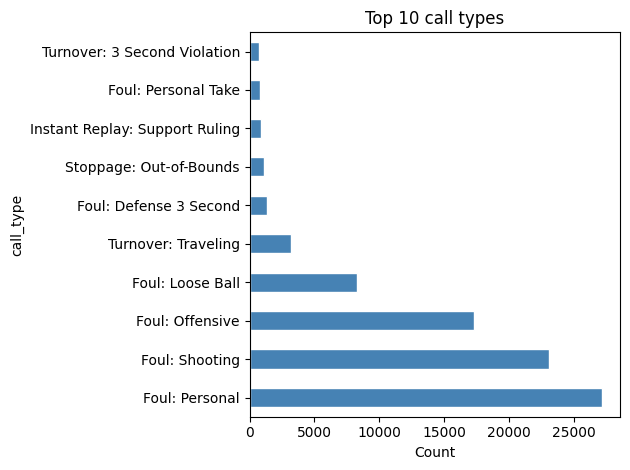

In [23]:
nba_data['call_type'].value_counts().head(10).plot(
    kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 call types')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

* **Home group**: `home`, `home_team`, `HomeTeamId`, `home_score` — abbreviation, nickname, and API identifier for the home team.
home: home team abbreviation  
home_score: home final score from the L2M reports, incomplete variable  
home_team: home team nickname

The home group contains four game-level columns identifying the home team by abbreviation, full name, final score, and API identifier. Coverage, unique values, and association between columns are examined at the game level to identify redundant representations and select the columns retained for downstream analysis.

In [24]:
print("Data types:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {games[col].dtype}")

print("\nCoverage per column:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {games[col].notna().sum()} / {len(games)} ({games[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {games[col].nunique()}")

print("\nChi-squared test:")
for pair in [('home', 'home_team'), ('home', 'HomeTeamId')]:
    subset = games[[pair[0], pair[1]]].dropna()
    ct = pd.crosstab(subset[pair[0]], subset[pair[1]])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"  {pair[0]} vs {pair[1]}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample mapping:")
print(games[['home', 'home_team', 'HomeTeamId']].drop_duplicates().sort_values('home').head(10))

Data types:
  home: object
  home_team: object
  home_score: int64
  HomeTeamId: float64

Coverage per column:
  home: 4487 / 4487 (100.0%)
  home_team: 4487 / 4487 (100.0%)
  home_score: 4487 / 4487 (100.0%)
  HomeTeamId: 2810 / 4487 (62.6%)

Unique values:
  home: 30
  home_team: 30
  home_score: 81
  HomeTeamId: 30

Chi-squared test:
  home vs home_team: chi2=130123.0, p=0.00e+00, dof=841
  home vs HomeTeamId: chi2=81490.0, p=0.00e+00, dof=841

Sample mapping:
      home home_team    HomeTeamId
34000  ATL     Hawks  1.610613e+09
66     ATL     Hawks           NaN
33003  BKN      Nets  1.610613e+09
43     BKN      Nets           NaN
32723  BOS   Celtics  1.610613e+09
21     BOS   Celtics           NaN
77     CHA   Hornets           NaN
33556  CHA   Hornets  1.610613e+09
88     CHI     Bulls           NaN
31955  CHI     Bulls  1.610613e+09


> **Home group** --- The home group contains four columns. `home` (object) and `home_team` (object) both have complete coverage (100%) and are significantly associated ($\chi^2 = 2{,}618{,}758$, $p < 0.001$) --- one is fully determined by the other. `HomeTeamId` (float64) is the NBA API numeric identifier with 32,032 missing values (35.5%) corresponding to PDF-sourced games, but is significantly associated with `home` where non-missing ($\chi^2 = 1{,}689{,}830$, $p < 0.001$). `home_score` (int64) has complete coverage (100%) and 81 unique values --- not redundant with the identifier columns and retained for in-game context analysis. `home` is retained as the primary team identifier (abbreviation format) for merging with the betting dataset. home_team and home together identify each team by abbreviation and full name. `HomeTeamId` is dropped --- structurally incomplete and redundant with `home`.

* **Away group**: `away`, `away_team`, `AwayTeamId` — same structure for the away team.  
away: away team abbreviation  
away_score: away final score from the L2M reports, incomplete variable  
away_team: away team nickname  
AwayTeamId: from official API  

The away group mirrors the home group — four game-level columns identifying the away team by abbreviation, full name, final score, and API identifier. Coverage, unique values, and association between columns are examined at the game level.

In [25]:
print("Data types:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {games[col].dtype}")

print("\nCoverage per column:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {games[col].notna().sum()} / {len(games)} ({games[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {games[col].nunique()}")

print("\nChi-squared test:")
for pair in [('away', 'away_team'), ('away', 'AwayTeamId')]:
    subset = games[[pair[0], pair[1]]].dropna()
    ct = pd.crosstab(subset[pair[0]], subset[pair[1]])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"  {pair[0]} vs {pair[1]}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample mapping:")
print(games[['away', 'away_team', 'AwayTeamId']].drop_duplicates().sort_values('away').head(10))

Data types:
  away: object
  away_team: object
  away_score: int64
  AwayTeamId: float64

Coverage per column:
  away: 4487 / 4487 (100.0%)
  away_team: 4487 / 4487 (100.0%)
  away_score: 4487 / 4487 (100.0%)
  AwayTeamId: 2810 / 4487 (62.6%)

Unique values:
  away: 30
  away_team: 30
  away_score: 79
  AwayTeamId: 30

Chi-squared test:
  away vs away_team: chi2=130123.0, p=0.00e+00, dof=841
  away vs AwayTeamId: chi2=81490.0, p=0.00e+00, dof=841

Sample mapping:
      away away_team    AwayTeamId
32120  ATL     Hawks  1.610613e+09
230    ATL     Hawks           NaN
32622  BKN      Nets  1.610613e+09
788    BKN      Nets           NaN
32322  BOS   Celtics  1.610613e+09
863    BOS   Celtics           NaN
875    CHA   Hornets           NaN
32099  CHA   Hornets  1.610613e+09
310    CHI     Bulls           NaN
34229  CHI     Bulls  1.610613e+09


> **Away group** --- The away group mirrors the home group exactly. `away` (object) and `away_team` (object) both have complete coverage (100%) and are significantly associated ($\chi^2 = 2{,}618{,}758$, $p < 0.001$). `AwayTeamId` (float64) has 32,032 missing values (35.5%) --- absent for PDF-sourced games --- and is significantly associated with `away` where non-missing ($\chi^2 = 1{,}689{,}830$, $p < 0.001$). `away_score` (int64) has complete coverage and 79 unique values --- retained for in-game context analysis. `away` is retained as the primary team identifier (abbreviation format) for merging with the betting dataset. away_team and away together identify each team by abbreviation and full name. `AwayTeamId` is dropped --- structurally incomplete and redundant with `away`.

* **Committing group**: `committing_min`, `committing_team`, `committing_side` — attributes of the player committing the infraction.  
committing: committing player or team of the graded infraction in L2M, may be blank  
committing_min: total minutes played by player committing action (note, may be NA because the player did not play and likely an input error from NBA on L2M)  
committing_side: home/away for committing player  
committing_team: team for committing player

The committing group contains three play-level columns identifying the team and player that committed the infraction. Coverage, unique values, and association between columns are examined to determine which columns are retained for downstream analysis.

In [26]:
# Committing group
print("Data types:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
subset = nba_data[['committing_team', 'committing_side']].dropna()
ct = pd.crosstab(subset['committing_team'], subset['committing_side'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"  committing_team vs committing_side: chi2={chi2:.1f}, p={p:.4f}, dof={dof}")

print("\nSample:")
print(nba_data[['committing_team', 'committing_side', 'home_team']].dropna().head(10))

Data types:
  committing_team: object
  committing_side: object
  committing_min: float64

Coverage per column:
  committing_team: 87869 / 90302 (97.3%)
  committing_side: 87869 / 90302 (97.3%)
  committing_min: 87119 / 90302 (96.5%)

Unique values:
  committing_team: 30
  committing_side: 2
  committing_min: 2536

Chi-squared test:
  committing_team vs committing_side: chi2=224.4, p=0.0000, dof=29

Sample:
   committing_team committing_side home_team
0              HOU            home   Rockets
1              CLE            away   Rockets
2              HOU            home   Rockets
3              HOU            home   Rockets
4              CLE            away   Rockets
5              HOU            home   Rockets
6              CLE            away   Rockets
8              CLE            away   Rockets
9              CLE            away   Rockets
10             HOU            home   Rockets


> **Committing group** --- The committing group contains three columns. `committing_team` (object) and `committing_side` (object) have identical coverage (97.3%, 2,433 missing). Chi-squared test shows a statistically significant but weak association ($\chi^2 = 224.4$, $p < 0.001$, $dof = 29$) --- they are not redundant. `committing_team` identifies the specific franchise while `committing_side` encodes the relative position (home/away) which changes with each game. `committing_min` (float64) records minutes played by the committing player (96.5% coverage) and is dropped. `committing_team` is retained for potential team-level analysis. `committing_side` is retained as the core variable for $\beta$ and $\delta$ calculation. The treatment of 2,433 missing values is deferred.

In [27]:
print('Unique values:')
print(nba_data['committing_side'].unique())
print()
print('Missing:', nba_data['committing_side'].isnull().sum())
print()
print(nba_data['committing_side'].value_counts(dropna=False))

Unique values:
['home' 'away' nan]

Missing: 2433

committing_side
away    44183
home    43686
NaN      2433
Name: count, dtype: int64


> **committing_side distribution** --- The `committing_side` column identifies whether the player committing the infraction belongs to the home or away team. Together with `decision`, it is the core column for calculating $\beta$ and $\delta$ as defined in Section 3.3. The column takes two clean values: `home` and `away`, with 2,433 missing values (2.7%). The distribution is nearly balanced --- 44,183 away (49.9%) and 43,686 home (49.4%) --- which is expected as there is no a priori reason for one side to commit more infractions. Missing values will be examined in the Tidy Data Preparation section.

* **Disadvantaged group**: `disadvantaged_min`, `disadvantaged_team`, `disadvantaged_side` — attributes of the player disadvantaged by the infraction.  
disadvantaged_min: total minutes played by player disadvantaged by action  
disadvantaged_side: home/away for disadvantaged player  
disadvantaged_team: team for disadvantaged player

The disadvantaged group mirrors the committing group — three play-level columns identifying the team and player disadvantaged by the infraction. Coverage, unique values, and association between columns are examined at the play level.

In [28]:
# Disadvantaged group
print("Data types:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
subset = nba_data[['disadvantaged_team', 'disadvantaged_side']].dropna()
ct = pd.crosstab(subset['disadvantaged_team'], subset['disadvantaged_side'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"  disadvantaged_team vs disadvantaged_side: chi2={chi2:.1f}, p={p:.4f}, dof={dof}")

print("\nSample:")
print(nba_data[['disadvantaged_team', 'disadvantaged_side', 'home_team']].dropna().head(10))

Data types:
  disadvantaged_team: object
  disadvantaged_side: object
  disadvantaged_min: float64

Coverage per column:
  disadvantaged_team: 84501 / 90302 (93.6%)
  disadvantaged_side: 84501 / 90302 (93.6%)
  disadvantaged_min: 78621 / 90302 (87.1%)

Unique values:
  disadvantaged_team: 30
  disadvantaged_side: 2
  disadvantaged_min: 2426

Chi-squared test:
  disadvantaged_team vs disadvantaged_side: chi2=224.4, p=0.0000, dof=29

Sample:
   disadvantaged_team disadvantaged_side home_team
0                 CLE               away   Rockets
1                 HOU               home   Rockets
2                 CLE               away   Rockets
3                 CLE               away   Rockets
4                 HOU               home   Rockets
5                 CLE               away   Rockets
6                 HOU               home   Rockets
8                 HOU               home   Rockets
9                 HOU               home   Rockets
10                CLE               away   Roc

In [29]:
print('Unique values:')
print(nba_data['disadvantaged_side'].unique())
print()
print('Missing:', nba_data['disadvantaged_side'].isnull().sum())
print()
print(nba_data['disadvantaged_side'].value_counts(dropna=False))

Unique values:
['away' 'home' nan]

Missing: 5801

disadvantaged_side
home    42428
away    42073
NaN      5801
Name: count, dtype: int64


> **Disadvantaged group** --- The disadvantaged group mirrors the committing group structurally. `disadvantaged_team` (object) and `disadvantaged_side` (object) have identical coverage (93.6%, 5,801 missing). Chi-squared test shows a statistically significant but weak association ($\chi^2 = 224.4$, $p < 0.001$, $dof = 29$) --- they are not redundant. `disadvantaged_team` identifies the specific franchise while `disadvantaged_side` encodes the relative position (home/away). `disadvantaged_min` (float64) records minutes played by the disadvantaged player (87.1% coverage) and is dropped. `disadvantaged_team` is retained for potential team-level analysis. `disadvantaged_side` is retained as a core variable for $\beta$ and $\delta$ calculation. The treatment of 5,801 missing values is deferred.

* **Decision column** --- The decision column is a play-level column and the core variable of the analysis. The distribution of values is examined to understand the balance between correct and incorrect calls, and to confirm the presence of blank entries that will be excluded. `decision` takes four values: **CC** (Correct Call), **CNC** (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call).

In [30]:
print(nba_data['decision'].value_counts(dropna=False))

decision
CNC    60590
CC     21023
INC     5391
NaN     2502
IC       796
Name: count, dtype: int64


The key variable is `decision`, which takes four values: **CC** (Correct Call), **CN**C (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call). A fifth value — blank — indicates plays that were not detectable without technology and are excluded from analysis.

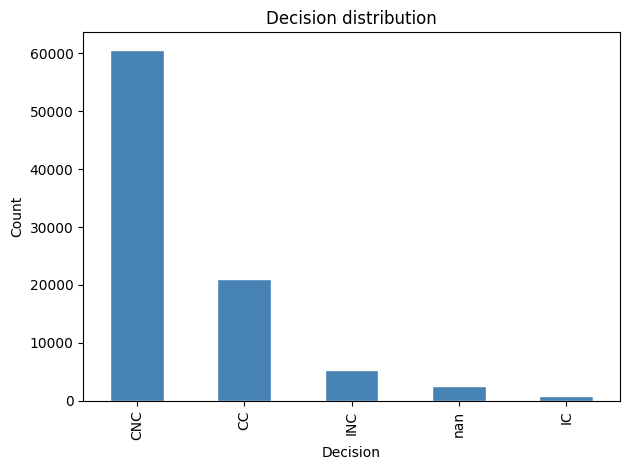

In [31]:
nba_data['decision'].value_counts(dropna=False).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Decision distribution')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The `decision` column is the core variable of the analysis. It takes four values: CC (Correct Call), CNC (Correct Non-Call), IC (Incorrect Call), and INC (Incorrect Non-Call). A fifth value — blank (NaN) — indicates plays not detectable without technology.

The distribution shows that CNC accounts for 60,590 entries (67.2% of all rows), followed by CC (21,023), INC (5,391), NaN (2,502), and IC (796). Pelechrinis (2023) notes that CNC criteria changed across seasons — during the 2015 season there were 6.4 CNC entries per game, while during the 2022 season there were almost 14 [PelechrinisL2M]. This inconsistency makes CNC unsuitable for longitudinal analysis. NaN entries are also excluded as they represent plays not detectable without technology. The working dataset therefore consists of CC (21,023), IC (796), and INC (5,391) — a total of 27,210 rows.

* **Season column** --- the distribution of rows by season is examined to confirm coverage and identify any gaps.

The season column is a identifier used for temporal classification across the three crowd presence periods defined in Section 3.1.

In [32]:
# Games per season
print(nba_data.groupby('season')['gid'].nunique())

season
2015    139
2016    439
2017    428
2018    475
2019    455
2020    395
2021    406
2022    442
2023    474
2024    411
2025    423
Name: gid, dtype: int64


2018 has more games (475) than 2019 (455), yet 2019 has more rows. This means the difference is not in the number of games — we check average actions per game to find the cause.

**Note** — the dataset contains 395–475 games per season, not 1,230. L2M reports are released only for close games (≤5 points in the last two minutes). A standard NBA season has 1,230 games (30 teams × 82 games / 2), of which approximately 35–40% qualify as close games by this definition.

In [33]:
# Rows per game by season
print(nba_data.groupby('season').apply(
    lambda x: len(x) / x['gid'].nunique(), include_groups=False
).round(1))

season
2015    14.2
2016    15.6
2017    17.6
2018    22.3
2019    25.1
2020    20.8
2021    19.5
2022    20.0
2023    24.3
2024    20.1
2025    16.9
dtype: float64


2019 peaks at 25.1 actions per game — the highest in the dataset. 2019 has more rows than 2018 despite fewer games (455 vs 475): the average actions per game in 2019 is 25.1 — the highest in the dataset — compared to the 2018 value shown above.

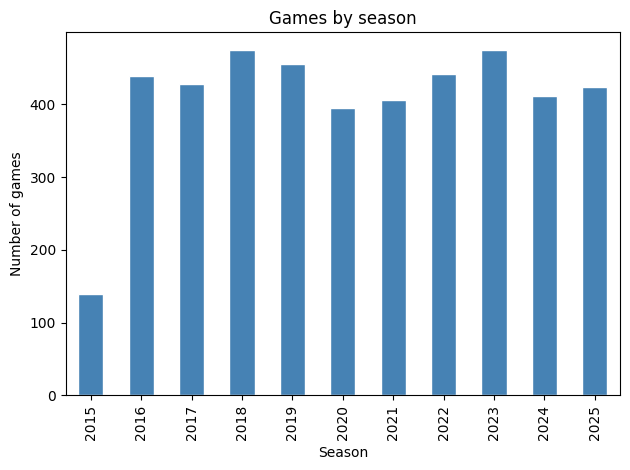

In [34]:
nba_data.groupby('season')['gid'].nunique().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Games by season')
plt.xlabel('Season')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

> **Observation** — 2015 has significantly fewer rows (1,972) and fewer games (139) as it was the first year of L2M reporting. Coverage stabilizes from 2016 onward. The drop in 2020–2022 reflects both fewer games (395–442 vs 455–475 in 2018–2019) and fewer graded actions per game (19.5–20.8 vs 25.1 in 2019). 2025 shows the lowest actions per game (16.9) because the season was still ongoing when the data was collected.

* **Playoff column** --- the split between regular season and playoff games is examined. Dummy variable equal to `True` if the game occurred in the playoffs.

In [35]:
print('Unique values:')
print(games['playoff'].unique())
print()
print('Missing:', games['playoff'].isnull().sum())
print()
print(games['playoff'].value_counts())
print(f'Total games: {len(games)}')

Unique values:
[False  True]

Missing: 0

playoff
False    4191
True      296
Name: count, dtype: int64
Total games: 4487


> **Playoff column** --- The `playoff` column is a boolean variable with no missing values. At the game level ($4{,}487$ unique games), 4,191 games (93.4%) are regular season and 296 games (6.6%) are playoff games. The column is used as a control variable in the analysis.

* **Attendance column** --- The range and distribution of values are examined, including games with zero attendance which correspond to the COVID bubble.

Unique values and missing --- the range of attendance values and missing entries are identified.

In [36]:
print('Unique values:')
print(games['ATTENDANCE'].unique())
print()
print('Missing:', games['ATTENDANCE'].isnull().sum())
print()
print(games['ATTENDANCE'].value_counts(dropna=False))

Unique values:
[18345. 18624. 13109. ... 19734. 19932. 17561.]

Missing: 324

ATTENDANCE
NaN        324
18997.0    114
19800.0    105
18203.0     88
19600.0     87
          ... 
18224.0      1
12533.0      1
16875.0      1
21696.0      1
18355.0      1
Name: count, Length: 2176, dtype: int64


> **Observation** — At the game level, `ATTENDANCE` has $324$ missing values out of $4{,}487$ games ($7.2\%$).

Distribution --- the attendance distribution is visualized to identify patterns and anomalies.

count     4163.0
mean     17367.0
std       3534.0
min          0.0
25%      16630.0
50%      18175.0
75%      19483.0
max      23143.0
Name: ATTENDANCE, dtype: float64


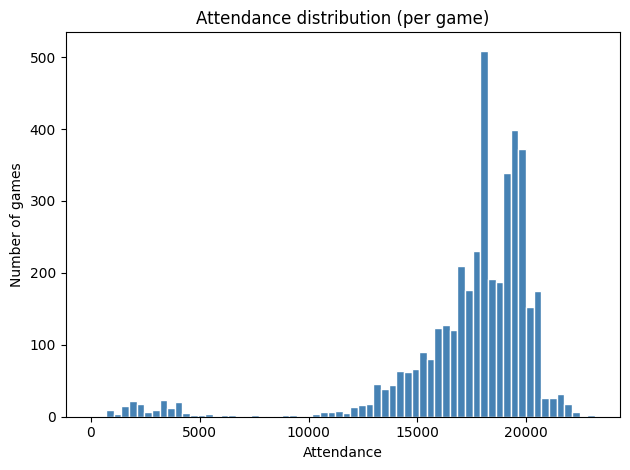

In [37]:
print(games['ATTENDANCE'].dropna().describe().round(0))
games['ATTENDANCE'].dropna().plot(
    kind='hist', bins='fd', color='steelblue', edgecolor='white')
plt.title('Attendance distribution (per game)')
plt.xlabel('Attendance')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

> **Observation** — At the game level, `ATTENDANCE` has $324$ missing values out of $4{,}487$ games ($7.2\%$). Among the $4{,}163$ games with recorded attendance, values range from $0$ to $23{,}143$ with a median of $18{,}175$. The minimum of $0$ corresponds to COVID bubble games played without fans.

Low attendance investigation --- the histogram shows a small group below 5,000. The seasons these belong to are identified below.

In [38]:
result = games[games['ATTENDANCE'] < 5000]['season'] \
    .value_counts() \
    .sort_index()
print('Rows with ATTENDANCE < 5000 (unique games):')
print(result)

Rows with ATTENDANCE < 5000 (unique games):
season
2021    148
2022      1
Name: count, dtype: int64


Zero attendance appears only in 2022, not in 2020. The NBA 2020 season was completed in a controlled bubble environment in Orlando — all games were recorded under a single venue and attendance was uniformly zero, but the ATTENDANCE column records this as missing rather than zero for that period. The structural absence of fans in 2020 is therefore real, but is captured by the season variable rather than `ATTENDANCE`.

In [39]:
mask = (nba_data['ATTENDANCE'] < 5000) & (nba_data['season'] == 2022)
cols = ['gid', 'season', 'home_team', 'away_team', 'date', 'call_type', 'decision', 'ATTENDANCE']
print(f'Rows: {mask.sum()}, Unique games: {nba_data[mask]["gid"].nunique()}')
print(nba_data[mask][cols].to_string())

Rows: 13, Unique games: 1
            gid  season home_team away_team        date               call_type decision  ATTENDANCE
59965  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59966  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59967  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59968  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59969  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting       CC         0.0
59970  22100850    2022   Raptors   Nuggets  2022-02-12  Foul: Defense 3 Second      INC         0.0
59971  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59972  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59973  22100850    2022   Raptors   Nuggets  2022-02-12          

The single 2022 game with restricted attendance is confirmed and 13 rows are verified to correspond to one game.

In [40]:
print(games.groupby('home_team')['ATTENDANCE'].median().sort_values(ascending=False).head(15))

home_team
Bulls            21116.0
76ers            20319.5
Mavericks        20157.0
Knicks           19812.0
Raptors          19800.0
Heat             19600.0
Nuggets          19520.0
Cavaliers        19432.0
Trail Blazers    19393.0
Clippers         19060.0
Lakers           18997.0
Celtics          18624.0
Spurs            18354.0
Jazz             18306.0
Thunder          18203.0
Name: ATTENDANCE, dtype: float64


Тhe peaks in the attendance distribution reflect fixed arena capacities. Bulls lead with median 21,116, followed by 76ers (20,319) and Mavericks (20,157). This is expected — arenas have a maximum capacity which creates natural clustering. This does not affect our analysis.

Although ATTENDANCE is recorded as integer values, its classification as a discrete variable is justified by its nature as count data (number of spectators), rather than merely its numerical representation.

> **Observation** — At the game level, `ATTENDANCE` has $324$ missing values ($7.2\%$). The distribution clusters between $13{,}000$–$23{,}143$, reflecting fixed arena capacities. Bulls lead with a median of $21{,}116$, followed by 76ers ($20{,}319$) and Mavericks ($20{,}157$). A secondary cluster falls below $5{,}000$ — games from the 2021 season played with restricted crowd capacity due to the COVID-19 pandemic, and a single Raptors vs Nuggets game (February 12, 2022) played without fans due to local public health restrictions.

* **national_tv**: national TV network for the game, "no" indicates none
The `national_tv` column is a game-level column identifying the national broadcast network for each game. `no` indicates the game was not nationally broadcast.

In [41]:
print('Unique values (per game):')
print(games['national_tv'].value_counts(dropna=False))
print()
print('Missing:', games['national_tv'].isnull().sum())
print(f'Total games: {len(games)}')

Unique values (per game):
national_tv
no                              3235
ESPN                             358
NBA TV                           355
TNT                              308
ABC                              114
NBATV                             36
TNT/truTV/Max                     32
TNT/truTV                         17
TNT OT                             9
TNT/Max                            6
ABC/ESPN+                          4
ESPN/ESPN2                         3
ABC/ESPN/ESPN+/Disney+             3
ABC/ESPN                           3
ESPN & ABC Simulcast               1
ESPN2                              1
ESPN 2                             1
ABC/ESPN/ESPN2/ESPN+/Disney+       1
Name: count, dtype: int64

Missing: 0
Total games: 4487


> **national_tv** --- The `national_tv` column identifies the national broadcast network for each game. It is a per-game attribute repeated for every row within a game, so the analysis is performed at the game level ($4{,}487$ unique games). There are no missing values. The majority of games were not nationally broadcast (3,235 games, 72.1%). Among nationally broadcast games, ESPN (358), NBA TV (355), and TNT (308) are the most frequent networks, followed by ABC (114). The remaining values represent multi-network simulcasts and variants. For analysis, `national_tv` is treated as a binary variable: `1` if the game was broadcast on any national network, and `0` otherwise. This binary grouping captures 1,252 nationally broadcast games (27.9%) versus 3,235 non-nationally broadcast games (72.1%).

* **Period column** --- the distribution of game periods is examined.

The period column is a play-level column identifying the game period in which each referee decision occurred.

In [42]:
print('Period distribution:')
print(nba_data['period'].value_counts())

Period distribution:
period
Q4    78374
Q5    10533
Q6     1189
Q7      129
Q8       77
Name: count, dtype: int64


> **Period column** --- The `period` column identifies the game period of each graded play. The majority of plays occur in Q4 ($78{,}374$, 86.8%). Overtime periods Q5 through Q8 account for $11{,}928$ rows (13.2%), distributed across Q5 ($10{,}533$), Q6 ($1{,}189$), Q7 ($129$), and Q8 ($77$). Overtime games are included in the analysis as they represent close game situations where crowd pressure and referee bias are equally relevant.

##### **Ungrouped Column** 

Several columns are excluded from further analysis. `page` and `file` are PDF pipeline artifacts absent for all API-sourced games. `gcode` and `networks` duplicate information already captured by `gid` and `national_tv` respectively. The remaining API-sourced columns have 32,032 or more missing values corresponding to all PDF-sourced games and are not used in the analysis.

`page` and `file` are PDF pipeline artifacts documented in the source [AtlhawksfanaticL2M]. `page` records the page number within the PDF report and `file` stores the source filename. Both are absent for all API-sourced games. Their missingness pattern and content are verified below to confirm they carry no analytical value.

In [43]:
print("=== page ===")
print(f"Missing: {nba_data['page'].isna().sum()} ({nba_data['page'].isna().mean():.1%})")
print(f"Sample: {nba_data['page'].dropna().head(3).tolist()}")

print("\n=== file ===")
print(f"Missing: {nba_data['file'].isna().sum()} ({nba_data['file'].isna().mean():.1%})")
print(f"Unique: {nba_data['file'].nunique()}")
print(f"Sample PDF: {nba_data[nba_data['file'].str.endswith('.pdf', na=False)]['file'].iloc[0]}")
print(f"Sample API: {nba_data[nba_data['file'].str.endswith('.csv', na=False)]['file'].iloc[0]}")

=== page ===
Missing: 58270 (64.5%)
Sample: [1.0, 1.0, 1.0]

=== file ===
Missing: 0 (0.0%)
Unique: 4488
Sample PDF: L2M-CLE-HOU-3-1-15.pdf
Sample API: 0021800552.csv


> **Observation** — `page` has 58,270 missing values (64.5%) — absent for all API-sourced games as page numbers are only relevant for PDF reports. It carries no analytical value and is dropped. `file` has complete coverage (0 missing) with 4,488 unique values — one per game — but encodes the same game identity as `gid` in two different formats ('L2M-CLE-HOU-3-1-15.pdf' for PDF-sourced, '0021800552.csv' for API-sourced). `file` is redundant with `gid` and is dropped.

`networks` is a shorthand TV network identifier. Its missingness pattern and association with `national_tv` are examined to determine whether it is redundant.

In [44]:
print("=== networks ===")
print(f"Missing: {nba_data['networks'].isna().sum()} ({nba_data['networks'].isna().mean():.1%})")
print(f"\nnetworks value counts:")
print(nba_data['networks'].value_counts(dropna=False))
print(f"\nnational_tv value counts (where networks notna):")
print(nba_data[nba_data['networks'].notna()]['national_tv'].value_counts(dropna=False))

=== networks ===
Missing: 88993 (98.6%)

networks value counts:
networks
NaN      88993
NBALP     1041
TNT        103
ABC         62
ESPN        57
NBATV       46
Name: count, dtype: int64

national_tv value counts (where networks notna):
national_tv
no       1041
TNT       103
ABC        62
ESPN       57
NBATV      46
Name: count, dtype: int64


> **Observation** — `networks` has 98.6% missing values (88,993 rows). Among the 1,309 non-missing rows, the mapping to `national_tv` is exact: `NBALP` (1,041) corresponds to `no` in `national_tv`, while `TNT` (103), `ABC` (62), `ESPN` (57), and `NBATV` (46) match directly. `networks` is structurally incomplete and fully redundant with `national_tv`. `networks` is dropped. `national_tv` is retained.

The remaining API-sourced columns are examined individually. `teamIdInFavor`, `errorInFavor`, and `Qualifier` are 100% missing and are excluded without further analysis. For the remaining columns, missingness pattern, unique values, and relationship with retained columns are examined where relevant.

The remaining API-sourced columns are examined individually — missingness, unique values, and relationship with retained columns are inspected.

In [45]:
print("=== 100% missing ===")
for col in ['teamIdInFavor', 'errorInFavor', 'Qualifier']:
    print(f"  {col}: missing={nba_data[col].isna().sum()} ({nba_data[col].isna().mean():.1%})")

print("\n=== ImposibleIndicator ===")
print(nba_data['ImposibleIndicator'].value_counts(dropna=False))

print("\n=== L2M_Comments ===")
print(nba_data['L2M_Comments'].value_counts(dropna=False))

print("\n=== Difficulty ===")
print(nba_data['Difficulty'].value_counts(dropna=False))
print()
print(pd.crosstab(nba_data['Difficulty'], nba_data['decision'], normalize='index').round(3))

print("\n=== posID, posStart, posEnd, imgChart, VideolLink ===")
for col in ['posID', 'posStart', 'posEnd', 'imgChart', 'VideolLink']:
    print(f"  {col}: missing={nba_data[col].isna().sum()} ({nba_data[col].isna().mean():.1%}), unique={nba_data[col].nunique()}")

print("\n=== posTeamId ===")
print(nba_data[['posTeamId', 'committing_team']].drop_duplicates().sort_values('committing_team'))
print(f"Unique posTeamId: {nba_data['posTeamId'].nunique()}")

=== 100% missing ===
  teamIdInFavor: missing=90302 (100.0%)
  errorInFavor: missing=90302 (100.0%)
  Qualifier: missing=90302 (100.0%)

=== ImposibleIndicator ===
ImposibleIndicator
0.0    58270
NaN    32032
Name: count, dtype: int64

=== L2M_Comments ===
L2M_Comments
NaN                                                                                                                                    89809
Due to a technical issue, video links for this report are not available at this time.                                                    203
NOTE: Due to a technical issue, video links may be unavailable.                                                                           72
NOTE: Due to technical issues, video is unavailable for this L2M report.                                                                  51
NOTE: Video and player names may be unavailable due to a technical issue.                                                                 46
NOTE: Due to a technical 

In [46]:
print(nba_data['posTeamId'].dropna().unique()[:10])
print(nba_data[['posTeamId', 'committing_team']].dropna().drop_duplicates('committing_team').sort_values('committing_team'))

[1.61061276e+09 1.61061276e+09 1.61061276e+09 1.61061276e+09
 1.61061274e+09 1.61061274e+09 1.61061274e+09 1.61061275e+09
 1.61061274e+09 1.61061275e+09]
          posTeamId committing_team
32120  1.610613e+09             ATL
32622  1.610613e+09             BKN
32323  1.610613e+09             BOS
32099  1.610613e+09             CHA
31955  1.610613e+09             CHI
32423  1.610613e+09             CLE
32297  1.610613e+09             DAL
31901  1.610613e+09             DEN
32081  1.610613e+09             DET
31924  1.610613e+09             GSW
31921  1.610613e+09             HOU
31956  1.610613e+09             IND
32349  1.610613e+09             LAC
31998  1.610613e+09             LAL
32373  1.610613e+09             MEM
32037  1.610613e+09             MIA
32192  1.610613e+09             MIL
32165  1.610613e+09             MIN
32394  1.610613e+09             NOP
31997  1.610613e+09             NYK
32012  1.610613e+09             OKC
32322  1.610613e+09             ORL
31870  1.610613e+0

> **Observation** — `teamIdInFavor`, `errorInFavor`, and `Qualifier` are 100% missing — never populated, dropped. `ImposibleIndicator` takes only one value (0.0) across all 58,270 non-null rows — carries no information, dropped. `L2M_Comments` is 99.5% missing and contains only technical notices about video availability — no analytical value, dropped. `Difficulty` shows a clear relationship with `decision` (Undetectable: 60% INC, Observable: 5.1% INC) suggesting it encodes call difficulty — a potential confounder. However, it has 37.8% missing values absent for all PDF-sourced games, making it structurally incomplete for the full dataset. `Difficulty` is dropped but noted as a limitation. `posTeamId` is a float64 NBA API team identifier with a one-to-one mapping to `committing_team` — redundant and 35.5% missing, dropped. `posID`, `posStart`, `posEnd`, `imgChart`, and `VideolLink` are all 35.5% missing — absent for all PDF-sourced games by design — and encode positional and video metadata not relevant to the analysis. All are dropped.

#### 4.1.4 Summary

The dendrogram is used as an orientation tool to verify the column selection decisions, not as a decision-making instrument.

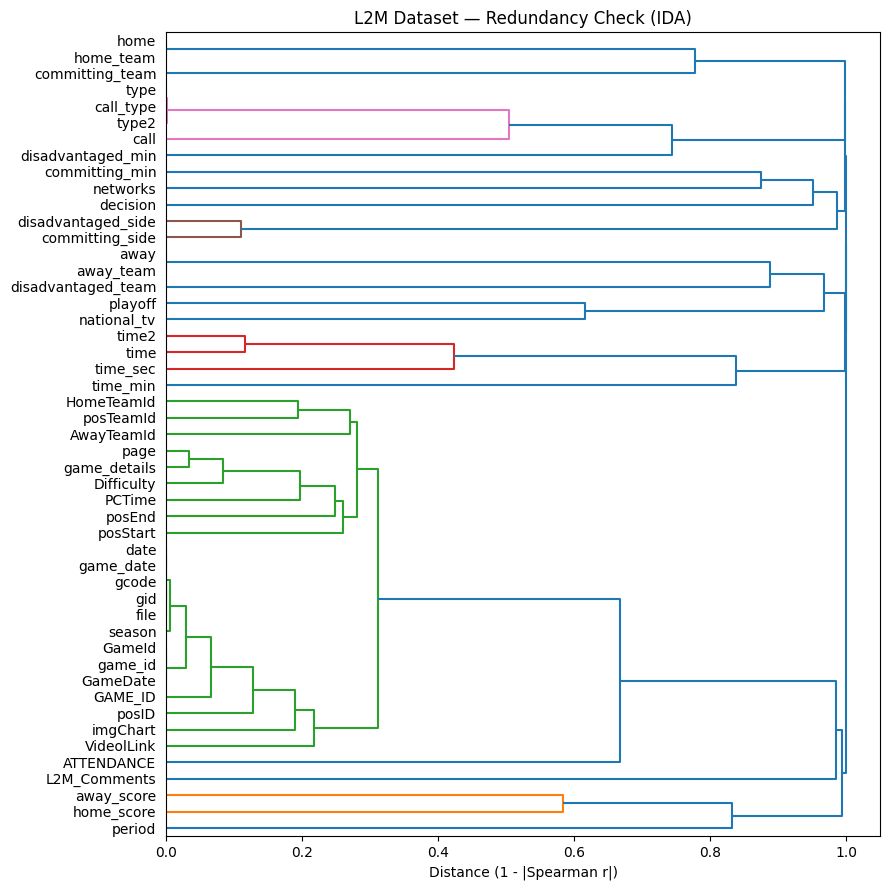

In [47]:
plot_redundancy(nba_data, title='L2M Dataset — Redundancy Check (IDA)', figsize=(9, 9) )

The dendrogram is computed over all 53 columns of the raw `nba_data` dataset using Spearman rank correlation as the distance metric ($d = 1 - |r_s|$). Spearman is used because the dataset contains a mixture of discrete, ordinal, and categorical (label-encoded) columns — Pearson correlation assumes linearity and normality, which cannot be assumed across column types of this kind. Columns that are more strongly associated appear closer together in the dendrogram; columns with no monotonic relationship appear at $d \approx 1.0$. The dendrogram is used as an orientation tool to verify the column selection decisions made in Section 4.1.3, not as a decision-making instrument.

> **Redundancy Check — L2M Dataset (full)** — Four clusters are identified.
> The **side cluster** ($d \approx 0.1$) groups `committing_side` and `disadvantaged_side` — the two core analytical columns are strongly associated, as the direction of benefit is fully determined by either column alone.
> The **call cluster** ($d \approx 0.5$) groups `call_type`, `type2`, and `call` — three representations of the same infraction at different levels of granularity; only `call_type` is retained.
> The **time cluster** ($d \approx 0.1$) groups `time2` and `time`, with `time_sec` joining at $d \approx 0.8$ — all three represent the same play clock value at different precision levels; only `time_sec` is retained.
> The **score cluster** ($d \approx 0.6$) groups `away_score` and `home_score` — both are retained as they are used for score validation in Section 5.4.3.
> The **metadata cluster** ($d < 0.4$) contains all remaining columns — game identifier duplicates, position tracking fields, PDF pipeline artefacts, and API metadata — all candidates for exclusion as documented in Section 4.1.3.

> **Structural observation** — The dendrogram confirms the two-level structure of the dataset without explicit labelling: play-level columns (`committing_side`, `disadvantaged_side`, `call_type`, `time`, `decision`) cluster separately from game-level columns (`season`, `playoff`, `ATTENDANCE`, `home_score`, `away_score`), consistent with the observational unit separation defined in Section 4.1.3 and the tidy data principle that each type of observational unit forms its own table [WickhamTidy].

Based on the column-level analysis, the following columns are selected for the analytical dataset: `decision`, `committing_side`, `disadvantaged_side`, and `call_type` for referee error measurement; `gid`, `date`, `season`, and `playoff` for game identification and temporal segmentation; `home`, `away`, `home_team`, and `away_team` for merge with the betting dataset; `ATTENDANCE` as a crowd pressure proxy; `national_tv` as a game visibility control variable; `home_score` and `away_score` for in-game context; `period`, `time`, `time_min`, `time_sec`, and `time2` for temporal context; `committing_team` and `disadvantaged_team` for merge key validation. All other columns are excluded as redundant, structurally incomplete, or not relevant to the research questions.

In [48]:
drop_cols = [
    # ID group — redundant with gid
    'GAME_ID', 'game_id', 'GameId', 'gcode',
    # Date group — redundant with date
    'game_date', 'GameDate',
    # Time group — structurally incomplete, redundant with time
    'PCTime',
    # Call group — redundant with call_type
    'call', 'type', 'type2',
    # Home group — structurally incomplete, redundant with home
    'HomeTeamId',
    # Away group — structurally incomplete, redundant with away
    'AwayTeamId',
    # Committing group — not used in analysis
    'committing_min',
    # Disadvantaged group — not used in analysis
    'disadvantaged_min',
    # Ungrouped — PDF pipeline artifacts
    'page', 'file', 'game_details',
    # Ungrouped — redundant with national_tv
    'networks',
    # Ungrouped — API columns, structurally incomplete or uninformative
    'teamIdInFavor', 'errorInFavor', 'Qualifier', 'ImposibleIndicator',
    'L2M_Comments', 'Difficulty', 'posID', 'posStart', 'posEnd',
    'posTeamId', 'imgChart', 'VideolLink'
]

print(nba_data.columns.tolist())
keep_cols = list(set(nba_data.columns.tolist()) - set(drop_cols))
print(keep_cols)
print(nba_data[keep_cols].head())

['period', 'time', 'call_type', 'decision', 'game_details', 'page', 'file', 'game_date', 'away_team', 'home_team', 'date', 'call', 'type', 'home', 'away', 'gid', 'gcode', 'home_score', 'away_score', 'national_tv', 'networks', 'game_id', 'PCTime', 'ImposibleIndicator', 'Difficulty', 'VideolLink', 'Qualifier', 'posID', 'posStart', 'posEnd', 'posTeamId', 'teamIdInFavor', 'errorInFavor', 'imgChart', 'GameId', 'GameDate', 'HomeTeamId', 'AwayTeamId', 'L2M_Comments', 'season', 'playoff', 'GAME_ID', 'ATTENDANCE', 'committing_min', 'committing_team', 'committing_side', 'disadvantaged_min', 'disadvantaged_team', 'disadvantaged_side', 'type2', 'time_min', 'time_sec', 'time2']
['home_team', 'away', 'national_tv', 'disadvantaged_side', 'time_min', 'away_team', 'away_score', 'call_type', 'home_score', 'committing_team', 'season', 'disadvantaged_team', 'committing_side', 'time2', 'home', 'date', 'playoff', 'decision', 'period', 'time', 'ATTENDANCE', 'gid', 'time_sec']
  home_team away national_tv dis

### 4.2 NBA Betting Data

#### 4.2.1 Dataset Overview

The betting dataset is sourced from Kaggle [KaggleBetting] and covers all NBA games from October 2007 to June 2025. Scores, point spreads, totals, and other odds are included for each game. The dataset draws from two sources: Sportsbook Reviews Online for the period October 30, 2007 to January 16, 2023, and ESPN from January 17, 2023 onward. Each row represents a single game. The full list of variables is described in the source documentation [KaggleBetting].

Two notes from the source documentation are relevant for this study. First, second half and moneyline odds are absent from the ESPN-sourced data (since January 2023). Second, team abbreviations follow specific conventions: Seattle is encoded as `okc` and New Jersey as `bkn` for consistency across seasons.

**Each row represents a single game — the observational unit is a game.**

#### 4.2.2 Data Quality

##### Shape

The dataset dimensions are inspected to confirm that the file was read correctly.

In [49]:
# Download file or use direct read
betting_data = pd.read_csv('data/input/nba_2008-2025.zip')
# betting_data = pd.read_csv('https://ai-and-ml-2026.s3.eu-north-1.amazonaws.com/decision-bias-study/data/nba_2008-2025.zip')
print(betting_data.head())
print(betting_data.shape)

   season        date  regular  playoffs  away home  score_away  score_home  \
0    2008  2007-10-30     True     False   por   sa          97         106   
1    2008  2007-10-30     True     False  utah   gs         117          96   
2    2008  2007-10-30     True     False   hou  lal          95          93   
3    2008  2007-10-31     True     False   phi  tor          97         106   
4    2008  2007-10-31     True     False   wsh  ind         110         119   

   q1_away  q2_away  ...  ot_home  whos_favored  spread  total  \
0       26       23  ...        0          home    13.0  189.5   
1       28       34  ...        0          home     1.0  212.0   
2       16       27  ...        0          away     5.0  199.0   
3       22       28  ...        0          home     6.5  191.0   
4       23       22  ...       16          away     1.5  203.5   

   moneyline_away  moneyline_home  h2_spread  h2_total id_spread  id_total  
0           900.0         -1400.0        5.0      9

> **Shape** --- The dataset contains $23{,}118$ rows and $27$ columns. The first few rows are displayed to verify the structure and content of the dataset.

##### Data Types

Inspecting the type of each column identifies potential parsing issues.

In [50]:
dtype_groups = betting_data.dtypes.reset_index()
dtype_groups.columns = ['column', 'dtype']
for dtype, group in dtype_groups.groupby('dtype'):
    print(f"\n{dtype}:")
    for col in group['column']:
        print(f"  {col}")


bool:
  regular
  playoffs

int64:
  season
  score_away
  score_home
  q1_away
  q2_away
  q3_away
  q4_away
  ot_away
  q1_home
  q2_home
  q3_home
  q4_home
  ot_home
  id_total

float64:
  spread
  total
  moneyline_away
  moneyline_home
  h2_spread
  h2_total
  id_spread

object:
  date
  away
  home
  whos_favored


> **Data Types** --- All 27 columns are inspected for parsing issues. A full description of each column is available in the source documentation [KaggleBetting]. `regular` and `playoffs` are `bool`, consistent with binary indicators in the source dataset. Score and quarter columns (`score_away`, `score_home`, `q1_away` through `ot_home`) are `int64` as expected. Betting columns (`spread`, `total`, `moneyline_away`, `moneyline_home`, `h2_spread`, `h2_total`, `id_spread`) are `float64` as expected. `id_total` is `int64`. Team identifier columns (`away`, `home`) and `whos_favored` are `object` as expected for string categories. One column requires conversion before analysis: `date` is stored as `object` and requires datetime conversion before merging with the L2M dataset. All conversions will be performed in the Tidy Data Preparation section.

##### Missing Values

The missing values analysis is the first step in column selection. Columns are evaluated by their missingness pattern to identify which are structurally incomplete and can be dropped before analysis.

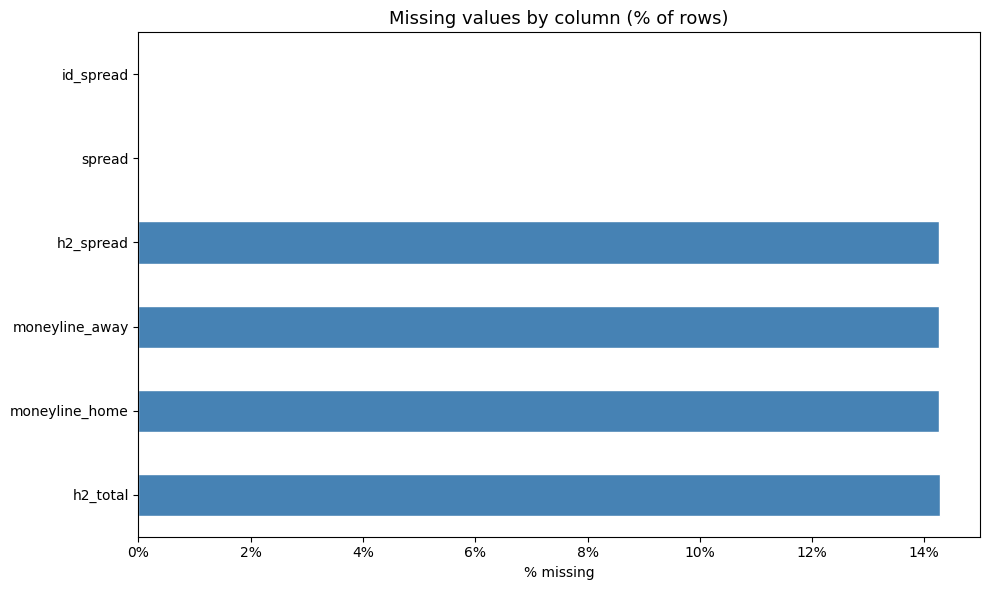

Columns with missing values: 6 / 27

h2_total          3301
moneyline_away    3298
moneyline_home    3298
h2_spread         3296
spread               3
id_spread            3


In [51]:
missing = betting_data.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(10, 6))
missing.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Missing values by column (% of rows)', fontsize=13)
ax.set_xlabel('% missing')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()
print(f"Columns with missing values: {len(missing)} / {len(betting_data.columns)}")
print(f"\n{betting_data.isnull().sum()[betting_data.isnull().sum() > 0].sort_values(ascending=False).to_string()}")

The three games with missing `spread` values are investigated to determine whether they can be recovered or should be excluded.

In [52]:
print("Games with missing spread:")
print(betting_data[betting_data['spread'].isnull()][['season', 'date', 'home', 'away', 'spread', 'id_spread']])

Games with missing spread:
       season        date home away  spread  id_spread
15939    2020  2019-12-19  lac  hou     NaN        NaN
18724    2022  2022-02-24  sac  den     NaN        NaN
18747    2022  2022-02-27  por  den     NaN        NaN


> **Missing Values** --- 6 out of 27 columns have missing values, falling into two structural groups. The first group comprises `h2_total` ($3{,}301$), `moneyline_away` ($3{,}298$), `moneyline_home` ($3{,}298$), and `h2_spread` ($3{,}296$) --- these correspond to the ESPN-sourced data from January 2023 onward, where second half and moneyline odds are absent by design as noted in the source documentation [KaggleBetting]. The second group contains `spread` and `id_spread` with 3 missing values each, corresponding to three specific games: LAC vs HOU (2019-12-19), SAC vs DEN (2022-02-24), and POR vs DEN (2022-02-27). These games have no spread data and will be excluded from the betting market analysis. The treatment of all missing values is deferred to the Tidy Data Preparation section.

##### Duplicates

Duplicate rows are identified to assess data integrity.

In [53]:
print(f"Duplicate rows: {betting_data.duplicated().sum()}")
print(f"Total rows: {len(betting_data)}")

Duplicate rows: 0
Total rows: 23118


> **Duplicates** — The dataset contains no duplicate rows.

The cardinality of each column is examined to identify categorical fields, columns with a single unique value (zero variance), and potential encoding issues such as mixed types or unexpected string representations of numeric values.

In [54]:
# Cardinality check for all columns
cardinality_check(betting_data)

=== Cardinality Analysis ===
Field                       Unique  Type        Sample values
--------------------------------------------------------------------------------
  away                        30  object      ['atl', 'bkn', 'bos', 'cha']
  date                      3688  object      ['2007-10-30', '2007-10-31', '2007-11-01', '2007-11-02']
  h2_spread                   37  float64     ['0.0', '0.5', '0.503', '0.505']
  h2_total                    84  float64     ['100.0', '100.5', '101.0', '101.5']
  home                        30  object      ['atl', 'bkn', 'bos', 'cha']
  id_spread                    3  float64     ['0.0', '1.0', '2.0']
  id_total                     3  int64       ['0', '1', '2']
  moneyline_away             665  float64     ['-1000.0', '-101.0', '-102.0', '-103.0']
  moneyline_home             674  float64     ['-1000.0', '-10000.0', '-1005.0', '-101.0']
  ot_away                     39  int64       ['0', '1', '10', '11']
  ot_home                     39  i

> **Cardinality Analysis**
>
> **Core analytical fields** — `id_spread` and `id_total` each have exactly 3 values (0, 1, 2) — both are integer columns. `whos_favored` is strictly binary (home/away). `spread` has 46 unique values — all multiples of 0.5, with no formatting inconsistencies.
>
> **Game identification fields** — `playoffs` and `regular` are strictly boolean. `season` covers 18 seasons (2008–2025). `home` and `away` contain 30 unique team abbreviations in lowercase — requiring standardisation to uppercase before merging with the L2M dataset.
>
> **Score fields** — `score_home` and `score_away` have 100 and 106 unique values respectively. Quarter scores (`q1`–`q4`) have 44–49 unique values each. `h2_spread` contains three anomalous decimal values (`0.503`, `0.505`) among otherwise clean 0.5-point increments — these warrant inspection before use.
>
> **High-cardinality fields** — `moneyline_home` and `moneyline_away` have 674 and 665 unique values respectively. `total` has 170 unique values. These fields are not used in the analysis.
>
> **Temporal coverage** — `date` has 3,688 unique values covering October 2007 to June 2025. The dataset contains 18 seasons compared to 11 in the L2M dataset — the overlap period (2015–2025) is applied during data preparation.

#### 4.2.3 Column-Level Analysis

The dataset contains 27 columns. Based on the source documentation [KaggleBetting] and the research questions defined in Section 3, a subset of columns is identified as candidates for analysis. The following sections examine each column group in detail, with the goal of determining which columns are suitable for inclusion in the final analytical dataset.

* **Game identifier group**: `season`, `date`, `home`, `away`, `regular`, `playoffs` --- columns identifying each game and its context.

In [55]:
id_cols = ['season', 'date', 'home', 'away', 'regular', 'playoffs']
print("Data types:")
for col in id_cols:
    print(f"  {col}: {betting_data[col].dtype}")

print("\nCoverage per column:")
for col in id_cols:
    print(f"  {col}: {betting_data[col].notna().sum()} / {len(betting_data)} ({betting_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in id_cols:
    print(f"  {col}: {betting_data[col].nunique()}")

print("\nSeason range:")
print(f"  {betting_data['season'].min()} - {betting_data['season'].max()}")

print("\nRegular/Playoffs split:")
print(betting_data['regular'].value_counts(dropna=False))
print(betting_data['playoffs'].value_counts(dropna=False))

Data types:
  season: int64
  date: object
  home: object
  away: object
  regular: bool
  playoffs: bool

Coverage per column:
  season: 23118 / 23118 (100.0%)
  date: 23118 / 23118 (100.0%)
  home: 23118 / 23118 (100.0%)
  away: 23118 / 23118 (100.0%)
  regular: 23118 / 23118 (100.0%)
  playoffs: 23118 / 23118 (100.0%)

Unique values:
  season: 18
  date: 3688
  home: 30
  away: 30
  regular: 2
  playoffs: 2

Season range:
  2008 - 2025

Regular/Playoffs split:
regular
True     21578
False     1540
Name: count, dtype: int64
playoffs
False    21611
True      1507
Name: count, dtype: int64


The unique team abbreviations in `home` and `away` are examined to identify non-standard values before merging with the L2M dataset.

In [56]:
print("Unique home teams:")
print(sorted(betting_data['home'].unique()))
print(f"\nUnique away teams:")
print(sorted(betting_data['away'].unique()))

Unique home teams:
['atl', 'bkn', 'bos', 'cha', 'chi', 'cle', 'dal', 'den', 'det', 'gs', 'hou', 'ind', 'lac', 'lal', 'mem', 'mia', 'mil', 'min', 'no', 'ny', 'okc', 'orl', 'phi', 'phx', 'por', 'sa', 'sac', 'tor', 'utah', 'wsh']

Unique away teams:
['atl', 'bkn', 'bos', 'cha', 'chi', 'cle', 'dal', 'den', 'det', 'gs', 'hou', 'ind', 'lac', 'lal', 'mem', 'mia', 'mil', 'min', 'no', 'ny', 'okc', 'orl', 'phi', 'phx', 'por', 'sa', 'sac', 'tor', 'utah', 'wsh']


> **Observation** — Both `home` and `away` contain 30 unique team abbreviations stored in lowercase, with identical sets across both columns — one per NBA team. Six abbreviations appear in non-standard form: `gs`, `no`, `utah`, `ny`, `sa`, `wsh` — these differ from the official NBA three-letter abbreviations (`gsw`, `nop`, `uta`, `nyk`, `sas`, `was`).

> **Game identifier group** --- All six columns have complete coverage (100%). `season` covers 18 seasons from 2008 to 2025. `date` is stored as `object` and requires datetime conversion before merging with the L2M dataset. `home` and `away` each have 30 unique values --- one per NBA team --- stored in lowercase format which differs from the L2M dataset. `regular` and `playoffs` are boolean columns with no missing values. The dataset contains $21{,}578$ regular season games and $1{,}507$ playoff games. Note that `regular` and `playoffs` are not mutually exclusive by design --- $1{,}540$ rows have `regular = False` while $1{,}507$ have `playoffs = True`, suggesting a small number of games may be neither regular season nor playoff (e.g. pre-season). `date`, `home`, and `away` are the merge keys for linking with the L2M dataset.

* **Score group**: `score_away`, `score_home`, `q1_away`, `q2_away`, `q3_away`, `q4_away`, `ot_away`, `q1_home`, `q2_home`, `q3_home`, `q4_home`, `ot_home` --- final and quarter-by-quarter scores for each game.

Score columns are examined to determine whether they should be treated as continuous or categorical variables. The number of unique values and the distribution are inspected.

In [57]:
score_cols = ['score_away', 'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away',
              'ot_away', 'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home']
print(betting_data[score_cols].head())
print("Unique values per column:")
for col in score_cols:
    print(f"  {col}: {betting_data[col].nunique()}")

   score_away  score_home  q1_away  q2_away  q3_away  q4_away  ot_away  \
0          97         106       26       23       28       20        0   
1         117          96       28       34       24       31        0   
2          95          93       16       27       27       25        0   
3          97         106       22       28       17       30        0   
4         110         119       23       22       25       33        7   

   q1_home  q2_home  q3_home  q4_home  ot_home  
0       29       30       22       25        0  
1       30       21       21       24        0  
2       25       18       19       31        0  
3       24       34       23       25        0  
4       28       20       22       33       16  
Unique values per column:
  score_away: 106
  score_home: 100
  q1_away: 45
  q2_away: 46
  q3_away: 47
  q4_away: 45
  ot_away: 39
  q1_home: 46
  q2_home: 47
  q3_home: 49
  q4_home: 44
  ot_home: 39


All 12 score columns have complete coverage (100%). `score_away` and `score_home` have 106 and 100 unique values, respectively, consistent with continuous numeric variables. Quarter columns (`q1` through `q4`) have 44--49 unique values each. `ot_away` and `ot_home` have 39 unique values each. Most games end in regulation — overtime scores of 0 are the most frequent value in both columns. The high number of unique values across all columns supports treating them as continuous numeric variables. For this study, only `score_away` and `score_home` are used to calculate the cover outcome. Quarter-by-quarter scores are not required for the analysis.

The distribution of score columns is visualised to determine whether they behave as continuous variables.


             min    max   mean  median
score_away  66.0  176.0  107.9   108.0
score_home  64.0  175.0  110.3   110.0


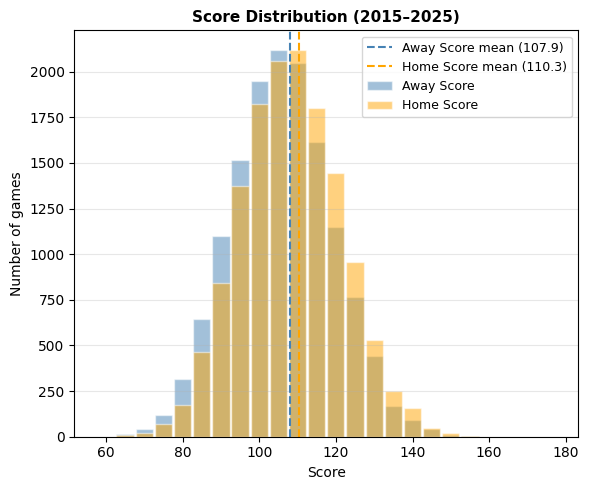

In [58]:
print(betting_data[betting_data['season'] >= 2015][['score_away', 'score_home']].agg(
    ['min', 'max', 'mean', 'median']
).round(1).T)


fig, ax = plt.subplots(figsize=(6, 5))

for col, color, label in [
    ('score_away', 'steelblue', 'Away Score'),
    ('score_home', 'orange', 'Home Score')
]:
    data_period = betting_data[betting_data['season'] >= 2015][col]
    bins = range(60, 185, 5)
    counts, edges = np.histogram(data_period, bins=bins)
    ax.bar(edges[:-1], counts, width=4.5, color=color, alpha=0.5,
           edgecolor='white', label=label)
    ax.axvline(data_period.mean(), color=color, linestyle='--', lw=1.5,
               label=f'{label} mean ({data_period.mean():.1f})')

ax.set_xlabel('Score', fontsize=10)
ax.set_ylabel('Number of games', fontsize=10)
ax.set_title('Score Distribution (2015–2025)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

> **Score distribution** — `score_away` and `score_home` are discrete integer columns. `score_away` ranges from 66 to 176 with a median of 108. `score_home` ranges from 64 to 175 with a median of 110. Both columns are retained — `score_diff = score_home - score_away` is derived in Data Engineering.

* **Betting group**: `whos_favored`, `spread`, `total`, `moneyline_away`, `moneyline_home` --- pre-game betting lines set by independent bookmakers.

Coverage and unique values are examined for all betting columns to identify structurally incomplete columns and determine the analytical value of each.

In [59]:
bet_cols = ['whos_favored', 'spread', 'total', 'moneyline_away', 'moneyline_home']
print(betting_data[bet_cols])
print("Coverage per column:")
for col in bet_cols:
    print(f"  {col}: {betting_data[col].notna().sum()} / {len(betting_data)} ({betting_data[col].notna().mean():.1%})")

print("\nUnique values per column:")
for col in bet_cols:
    print(f"  {col}: {betting_data[col].nunique()}")

      whos_favored  spread  total  moneyline_away  moneyline_home
0             home    13.0  189.5           900.0         -1400.0
1             home     1.0  212.0           100.0          -120.0
2             away     5.0  199.0          -230.0           190.0
3             home     6.5  191.0           255.0          -305.0
4             away     1.5  203.5          -125.0           105.0
...            ...     ...    ...             ...             ...
23113         away     4.5  225.5             NaN             NaN
23114         away     6.5  227.5             NaN             NaN
23115         home     8.5  223.5             NaN             NaN
23116         away     5.5  222.5             NaN             NaN
23117         home     6.5  215.5             NaN             NaN

[23118 rows x 5 columns]
Coverage per column:
  whos_favored: 23118 / 23118 (100.0%)
  spread: 23115 / 23118 (100.0%)
  total: 23118 / 23118 (100.0%)
  moneyline_away: 19820 / 23118 (85.7%)
  moneyline_home:

`whos_favored` and `spread` are examined together as they jointly define the cover outcome. `whos_favored` indicates which team is favored, while `spread` quantifies the expected margin. The distribution of both columns is examined.

In [60]:
print(betting_data['whos_favored'].value_counts(dropna=False))

whos_favored
home    15391
away     7727
Name: count, dtype: int64


> Home teams are favoured in $15{,}391$ games (66.6%) and away teams in $7{,}727$ games (33.4%) across all 18 seasons covered by the dataset.

`spread` and `score_diff` are examined for association. Both variables are discrete with natural ordering — Spearman rank correlation is used instead of Pearson, which assumes continuous normally distributed data, or Chi-square, which is appropriate for unordered categorical variables.


In [61]:
betting_data['score_diff'] = betting_data['score_home'] - betting_data['score_away']
clean = betting_data[['spread', 'score_diff']].dropna()
r, p = spearmanr(clean['spread'], clean['score_diff'])
print(f"Spearman r = {r:.4f},  p = {p:.4f}")

Spearman r = 0.2021,  p = 0.0000


> `whos_favored` is a categorical column with 2 unique values: `home` ($15{,}391$, 66.6%) and `away` ($7{,}727$, 33.4%). Together with `spread` and `id_spread`, it is retained for cover outcome derivation in Data Engineering.

`total`, `moneyline_away`, and `moneyline_home` are examined for completeness and relevance to the central hypothesis.

In [62]:
# total — discrete, half-point increments
print("=== total ===")
print(betting_data['total'].agg(['min', 'max', 'mean', 'median', 'nunique']).round(1))

# moneyline — American odds format, coverage check only
print(f"\nmoneyline_away missing: {betting_data['moneyline_away'].isnull().sum()} ({betting_data['moneyline_away'].isnull().mean():.1%})")
print(f"moneyline_home missing: {betting_data['moneyline_home'].isnull().sum()} ({betting_data['moneyline_home'].isnull().mean():.1%})")

=== total ===
min        170.0
max        262.5
mean       210.2
median     210.0
nunique    170.0
Name: total, dtype: float64

moneyline_away missing: 3298 (14.3%)
moneyline_home missing: 3298 (14.3%)


In [63]:
cols = ['total', 'moneyline_away', 'moneyline_home', 'spread', 'score_diff']
clean = betting_data[cols].dropna()

print("=== Spearman rank correlation ===")
corr_matrix = clean.apply(lambda x: clean.apply(lambda y: spearmanr(x, y)[0]))
print(corr_matrix.round(3).to_string())

=== Spearman rank correlation ===
                total  moneyline_away  moneyline_home  spread  score_diff
total           1.000          -0.035           0.033   0.030      -0.008
moneyline_away -0.035           1.000          -0.999   0.530       0.454
moneyline_home  0.033          -0.999           1.000  -0.531      -0.454
spread          0.030           0.530          -0.531   1.000       0.216
score_diff     -0.008           0.454          -0.454   0.216       1.000


> The correlation matrix confirms three structural patterns in the betting data. First, `moneyline_away` and `moneyline_home` are near-perfect mirror variables (r = −0.999) — both price the same game from opposite sides, which accounts for the near-perfect negative correlation.. Second, `spread` and moneyline are moderately correlated (r ≈ 0.53) — both measure expected team strength but in different formats. Third, `total` is effectively independent of all other variables (r < 0.04), confirming that the over/under line captures a separate dimension of the game — total scoring — unrelated to which team wins or by how much.

* **Second half group**: `h2_spread`, `h2_total` --- second half betting lines set by bookmakers at half-time based on first half performance. These lines have no direct relevance to the central hypothesis as L2M data covers only the final two minutes of each period. Examined for completeness only.

Coverage and descriptive statistics are examined. The correlation between `h2_spread`, `h2_total` and the core variables is examined.

In [64]:
print(betting_data[['h2_spread', 'h2_total']].head())

cols = ['h2_spread', 'h2_total', 'spread', 'score_diff']
clean = betting_data[cols].dropna()
corr_matrix = clean.apply(lambda x: clean.apply(lambda y: spearmanr(x, y)[0]))
print(corr_matrix.round(3).to_string())

   h2_spread  h2_total
0        5.0      95.0
1        3.0     105.5
2        3.0      99.0
3        2.0      96.5
4        1.0     105.0
            h2_spread  h2_total  spread  score_diff
h2_spread       1.000     0.041   0.337      -0.041
h2_total        0.041     1.000   0.018      -0.023
spread          0.337     0.018   1.000       0.216
score_diff     -0.041    -0.023   0.216       1.000


> The Spearman correlation matrix shows a moderate association between `h2_spread` and `spread` ($r_s = 0.337$), consistent with both columns capturing the expected point margin at different points in time. `h2_total` shows near-zero correlation with all other variables ($r_s \leq 0.041$). Both columns have over 3,296 missing values.

* **Outcome group**: `id_spread`, `id_total` --- post-game outcomes. According to the source documentation [KaggleBetting]: `id_spread` is 1 if the favorite covered, 0 if the underdog covered, 2 if push. `id_total` is 1 if the total went over, 0 if under, 2 if push.

The distribution and relevance to the central hypothesis are examined.

In [65]:
print(betting_data[['id_spread', 'id_total']].value_counts(dropna=False))

id_spread  id_total
1.0        0           5696
0.0        1           5644
           0           5615
1.0        1           5558
2.0        1            182
           0            151
1.0        2            142
0.0        2            125
2.0        2              2
NaN        1              2
           0              1
Name: count, dtype: int64


> `id_spread` and `id_total` are post-game outcome variables. `id_spread` records whether the favorite covered the spread: 1 (favorite covered), 0 (underdog covered), 2 (push). `id_total` records whether the total went over: 1 (over), 0 (under), 2 (push). Both have 3 missing values --- the same games with missing `spread` identified earlier. Push outcomes are rare: 142 for `id_spread` and 182 for `id_total`. `id_spread` is noted as a candidate for the cover outcome calculation --- however, it is defined from the perspective of the **favorite**, not the **home team**. Since the central hypothesis requires cover from the perspective of the home team, `id_spread` cannot be used directly and a new `home_cover` variable will be derived in the Tidy Data Preparation section. `id_total` is not relevant to the central hypothesis.

#### 4.2.4 Summary

Based on the column-level analysis the following columns are retained for the analytical dataset: `date`, `home`, and `away` for merging with the L2M dataset; `season` and `playoffs` for temporal segmentation; `score_home`, `score_away`, `whos_favored`, `spread`, and `id_spread` for deriving the `home_covered` outcome variable.

The following columns are excluded based on the IDA findings above. `regular` is a mirror variable of `playoffs` (distance 0 in the redundancy check) — only one is needed. `moneyline_home` and `moneyline_away` have 3,298 missing values each, corresponding to all ESPN-sourced games from January 2023 onward, and correlate with `spread` (r≈0.53) — they measure the same pre-game expectation in a different format. `h2_spread` and `h2_total` have 3,296 and 3,301 missing values respectively for the same reason, and are half-time lines — not pre-game measures. `total` and `id_total` test the over/under market, which is structurally independent of the spread outcome (r<0.04). Quarter scores (`q1`–`q4`, `ot`) are redundant with `score_home` and `score_away` — they sum to the final score by definition.

> **Summary** — The betting dataset contains 23,118 games across seasons 2008–2025. After filtering to seasons 2015–2025 to match the L2M coverage period and dropping the three games with missing `spread`, the analytical subset contains 14,154 games. Home teams are favoured in 66.6% of games. The `id_spread` outcome variable is complete for 99.9% of games. No duplicate rows are present. The dataset is structurally clean and ready for merge with the L2M game-level data.

The dendrogram is used as an orientation tool to verify the column selection decisions, not as a decision-making instrument.

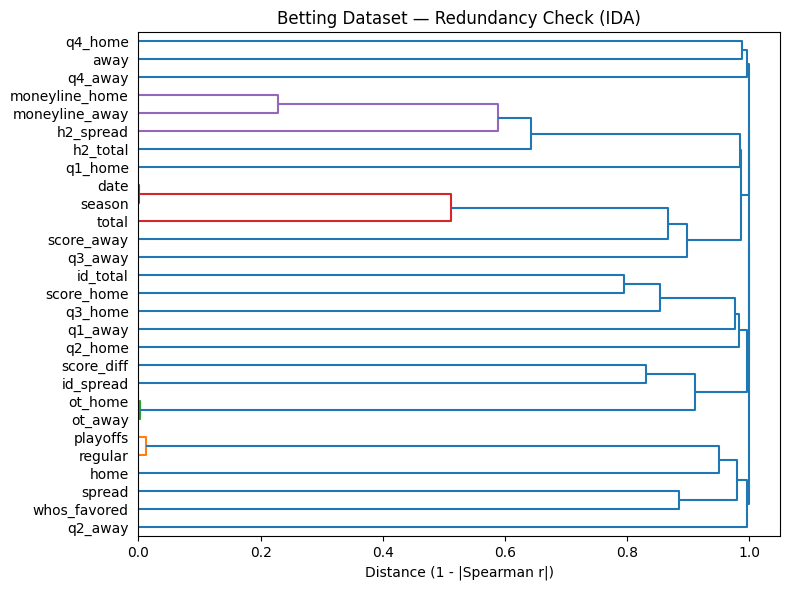

In [66]:
plot_redundancy(betting_data, title='Betting Dataset — Redundancy Check (IDA)',  figsize=(8, 6) )

The dendrogram is used as an orientation tool to verify the column selection decisions made in Section 4.2.3, not as a decision-making instrument. The plot is computed over all 27 columns of the betting dataset, including `score_diff` derived in Section 4.2.3.

> **Redundancy Check — Betting Dataset** — Four clusters are identified.
> The **moneyline cluster** ($d \approx 0.2$) groups `moneyline_home` and `moneyline_away` — near-perfect mirror variables pricing the same game from opposite sides ($r = -0.999$), merging at the lowest distance in the plot. `h2_spread` and `h2_total` join this cluster at $d \approx 0.6$ — both are secondary half-time lines with over 3,296 missing values; all four are excluded from the analysis.
> The **season cluster** ($d \approx 0.5$) groups `date`, `season`, and `total` — all three merge at moderate distance, suggesting shared structure among temporal and market variables.
> The **playoffs cluster** ($d \approx 0.05$) groups `playoffs` and `regular` — mirror boolean variables encoding the same game type from opposite sides; only `playoffs` is retained.
> The **overtime cluster** groups `ot_home` and `ot_away` — mirror variables encoding the same overtime event from opposite perspectives; both are excluded as overtime scores are redundant with `score_home` and `score_away`.
> The remaining variables — quarter scores, final scores, `id_spread`, `spread`, `whos_favored`, `score_diff`, and `id_total` — all join at $d > 0.8$, confirming low redundancy among the candidate analytical columns.

## 5. Data Engineering

The two source datasets operate at different observational levels. Following Wickham (2014) [WickhamTidy], each type of observational unit is stored in its own table before combining — play-level decisions in `nba_meta` and game-level betting lines in `betting_clean`. The pipeline proceeds in four stages, illustrated in Figure 2.

First, each dataset is cleaned independently: `nba_data` is reduced to `nba_meta` (play-level, all decisions) and filtered to `play_data` (play-level, CC/IC/INC only); `betting_data` is reduced to `betting_clean` (game-level). Second, `nba_meta` is aggregated from play-level to game-level to produce `nba_games`, computing $\beta$ and $\delta$ for each game — this step is required before merging because joining a play-level dataset directly to a game-level dataset would violate the tidy principle that each observational unit forms its own table [WickhamTidy]. Third, `nba_games` and `betting_clean` are merged on `date`, `home`, and `away` to produce `merged_data`. Fourth, analytical variables (`nwg`, `ar`, `home_covered`, `period`) are derived from `merged_data` to produce the final output dataset `game_data`. The two output datasets — `game_data` and `play_data` — serve distinct roles in the analysis sections that follow.

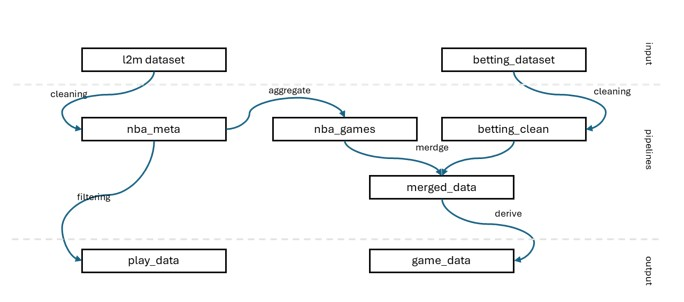  
*Fig. 2 — Data Preparation Pipeline*

### 5.1 L2M Preparation

The L2M dataset provides the play-level decisions used to compute the game-level NWG metric. At the play level, `play_data` serves as the basis for the Monte Carlo replication check. At the game level, the aggregated `nwg` variable in `game_data` is the test statistic for the primary Sign Test. This requires a clean play-level dataset with consistent `decision`, `committing_side`, and `disadvantaged_side` values.

Before applying any filters, the missing values in the three core analytical columns — `decision`, `committing_side`, and `disadvantaged_side` — are examined to determine which can be safely dropped and which must be retained.

In [67]:
print("=== decision ===")
print(nba_data['decision'].value_counts(dropna=False))

print("\n=== committing_side — decision distribution where NaN ===")
print(nba_data[nba_data['committing_side'].isna()]['decision'].value_counts(dropna=False))
print("\nTop call_type:")
print(nba_data[nba_data['committing_side'].isna()]['call_type'].value_counts().head(5))

print("\n=== disadvantaged_side — decision distribution where NaN ===")
print(nba_data[nba_data['disadvantaged_side'].isna()]['decision'].value_counts(dropna=False))
print("\nTop call_type:")
print(nba_data[nba_data['disadvantaged_side'].isna()]['call_type'].value_counts().head(5))

=== decision ===
decision
CNC    60590
CC     21023
INC     5391
NaN     2502
IC       796
Name: count, dtype: int64

=== committing_side — decision distribution where NaN ===
decision
CC     1566
CNC     719
NaN      81
INC      44
IC       23
Name: count, dtype: int64

Top call_type:
call_type
Instant Replay: Support Ruling     787
Foul: Personal                     290
Foul: Shooting                     288
Instant Replay: Overturn Ruling    265
Turnover: 24 Second Violation      191
Name: count, dtype: int64

=== disadvantaged_side — decision distribution where NaN ===
decision
CC     1971
NaN    1617
CNC    1501
INC     666
IC       46
Name: count, dtype: int64

Top call_type:
call_type
Turnover: Traveling               1538
Instant Replay: Support Ruling     846
Foul: Defense 3 Second             485
Turnover: 3 Second Violation       335
Foul: Personal                     313
Name: count, dtype: int64


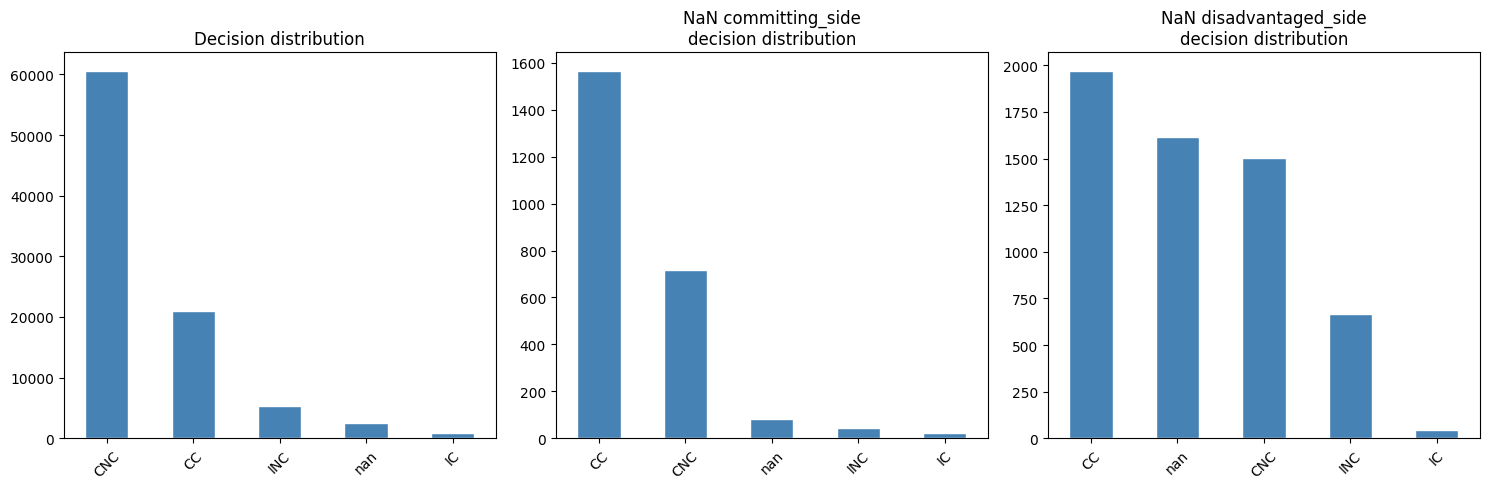

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nba_data['decision'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Decision distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

nba_data[nba_data['committing_side'].isna()]['decision'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('NaN committing_side\ndecision distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

nba_data[nba_data['disadvantaged_side'].isna()]['decision'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('NaN disadvantaged_side\ndecision distribution')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> **Observation** --- Following Pelechrinis (2023) [PelechrinisL2M], `decision` has $2{,}502$ missing values representing plays not detectable without technology --- these are dropped. CNC ($60{,}590$) is excluded as its grading criteria are inconsistent across seasons [PelechrinisL2M]. Missing values in `committing_side` ($2{,}433$) and `disadvantaged_side` ($5{,}801$) are retained because they arise from play types where no specific player is identified by definition --- Instant Replay rulings and structural violations such as Traveling and Defense 3-second --- and contain real referee errors: $67$ incorrect decisions (IC + INC, 2.7%) and $712$ incorrect decisions (IC + INC, 12.3%) respectively. Removing them would discard valid analytical signal.

> Missing values in `committing_side` and `disadvantaged_side` are retained because they contain real referee errors. Among the $2{,}433$ rows with missing `committing_side`, 67 are incorrect decisions (IC + INC, 2.7%). Among the $5{,}801$ rows with missing `disadvantaged_side`, $712$ are incorrect decisions (IC + INC, 12.3%). These missing values do not indicate data quality issues --- they arise from play types where no specific player is identified by definition, such as Instant Replay rulings ($787$ and $846$ respectively) and structural violations (Traveling: $1{,}538$, Defense 3-second: $485$). Removing them would discard valid analytical signal from the working dataset.



#### 5.1.1 **Clean**

The raw dataset `nba_data` is cleaned in four steps. First, columns are retained based on the column-level analysis in Section 4.1.3. Second, column types are converted and names are standardised to lowercase. Third, duplicate rows that emerge after column selection are removed. Fourth, rows with missing `decision` values — plays not detectable without technology — are dropped. The resulting dataset is `nba_meta`.

In [69]:
# Step 1 — Apply column selection
cols_before = len(nba_data.columns)
nba_meta = nba_data[keep_cols].copy()
print(f"Columns: {cols_before} → {len(nba_meta.columns)}")

# Step 2 — Type conversions and column renaming
nba_meta['date'] = pd.to_datetime(nba_meta['date'])
nba_meta['playoff'] = nba_meta['playoff'].astype(int)
nba_meta.columns = nba_meta.columns.str.lower()
nba_meta['attendance'] = nba_meta['attendance'].astype('Int64')

# Step 3 — Drop duplicates
rows_before = len(nba_meta)
nba_meta = nba_meta.drop_duplicates()
print(f"After drop duplicates: {len(nba_meta)} (dropped {rows_before - len(nba_meta)})")

# Step 4 — Drop blank decisions
rows_before = len(nba_meta)
nba_meta = nba_meta[nba_meta['decision'].notna()].copy()
print(f"After drop decision NaN: {len(nba_meta)} (dropped {rows_before - len(nba_meta)})")
print(f"\nFinal nba_meta: {nba_meta.shape}")

Columns: 53 → 23
After drop duplicates: 89460 (dropped 842)
After drop decision NaN: 86963 (dropped 2497)

Final nba_meta: (86963, 23)


#### 5.1.2 **Filter**

`nba_meta` is filtered to retain only CC, IC, and INC decisions, excluding CNC entries. CNC decisions are excluded because their grading criteria changed substantially across seasons — from $6.4$ entries per game in 2015 to almost $14$ in 2022 [PelechrinisL2M] — making them inconsistent as an analytical signal. Following the observational unit separation confirmed in Section 4.1.4, game-level columns (`home_score`, `away_score`, `attendance`, `national_tv`, `committing_team`, `disadvantaged_team`) are dropped — game-level context is carried separately in `nba_games`. `gid` is retained as the foreign key linking each play to its game. Temporal columns (`period`, `time`, `time2`, `time_min`, `time_sec`, `date`) and team identifiers (`home`, `away`, `home_team`, `away_team`) are retained for potential sub-analysis. The resulting dataset `play_data` contains one row per graded referee decision.

In [70]:
play_level_cols = [
    'gid', 'decision', 'committing_side', 'disadvantaged_side', 'call_type',
    'season', 'playoff',
    'period', 'time', 'time2', 'time_min', 'time_sec',
    'date', 'home', 'away', 'home_team', 'away_team'
]

play_data = nba_meta[nba_meta['decision'].isin(['CC', 'IC', 'INC'])][play_level_cols].copy()
print(f"Shape: {play_data.shape}")
print(f"\nDecision distribution:")
print(play_data['decision'].value_counts())

print(play_data.head())

Shape: (27127, 17)

Decision distribution:
decision
CC     20958
INC     5374
IC       795
Name: count, dtype: int64
        gid decision committing_side disadvantaged_side  \
1  21400883       CC            away               home   
2  21400883       CC            home               away   
3  21400883       CC            home               away   
6  21400883       CC            away               home   
7  21400883       CC             NaN                NaN   

                        call_type  season  playoff period     time     time2  \
1                  Foul: Shooting    2015        0     Q4  01:43.0  1.716667   
2                  Foul: Shooting    2015        0     Q4  01:32.0  1.533333   
3                Foul: Loose Ball    2015        0     Q4  01:09.0  1.150000   
6                  Foul: Shooting    2015        0     Q5  04:34.0  4.566667   
7  Instant Replay: Support Ruling    2015        0     Q5  04:34.0  4.566667   

   time_min  time_sec       date home away home

Following Pelechrinis (2023) [PelechrinisL2M], the whistle benefit $\beta$ and whistle detriment $\delta$ are defined solely by `committing_side` and `decision`. An incorrect non-call (INC) where the committing team is home means the home team escaped a penalty --- a benefit to the home team. An incorrect call (IC) where the committing team is away means the away team was wrongly penalized --- again a benefit to the home team. The `disadvantaged_side` column serves as a consistency check but is not required for this calculation.

| $committing\_side$ | $disadvantaged\_side$ | $decision$ | Benefit |
|---|---|---|---|
| $home$ | $away$ | $INC$ | $home\ (\beta)$ |
| $away$ | $home$ | $IC$ | $home\ (\beta)$ |
| $away$ | $home$ | $INC$ | $away\ (\delta)$ |
| $home$ | $away$ | $IC$ | $away\ (\delta)$ |
| $home$ | $away$ | $CC$ | neutral |
| $away$ | $home$ | $CC$ | neutral |
| $home$ | $home$ | $*$ | anomaly |
| $away$ | $away$ | $*$ | anomaly |


The play-level dataset contains one row per graded referee decision. Each decision is characterised by its outcome (CC, IC, or INC), the side that committed the infraction, the type of infraction, and the game identifier used for aggregation. Season and playoff status enable temporal segmentation across the three periods defined in Section 3.1.

In [71]:
play_data.to_csv('data/output/play_data.csv', index=False)
print(play_data.columns)

Index(['gid', 'decision', 'committing_side', 'disadvantaged_side', 'call_type',
       'season', 'playoff', 'period', 'time', 'time2', 'time_min', 'time_sec',
       'date', 'home', 'away', 'home_team', 'away_team'],
      dtype='object')


### 5.2 Betting Data Preparation

The betting dataset is the empirical basis for the Inertial Channel (RQ2) defined in Section 3.3.2. To derive the cover outcome variable for RQ2, each game must have a verified cover outcome derived from `spread`, `whos_favored`, and `id_spread` as defined in Section 4.2.3. `betting_data` enters the pipeline at the input layer (Figure 2) and participates in four steps: its game-level structure drives the aggregation of `nba_meta` to `nba_games`; it is cleaned to `betting_clean` in this section; `betting_clean` is merged with `nba_games` to produce `merged_data`; and analytical variables are derived from `merged_data` to produce `game_data`. The cleaning resolves two structural incompatibilities identified in Section 4.2: the dataset covers seasons 2008–2025 while the L2M dataset covers only 2015–2025, and team abbreviations differ between the two sources.

**Aggregate**: `nba_meta` is aggregated to game level to produce `nba_games`, computing $\beta$ and $\delta$ for each game. The aggregation target is defined by the game identifiers in `betting_clean` — `date`, `home`, and `away` — which serve as the merge keys.

**Clean**: Games before season 2015 are excluded to match the L2M coverage period. The three games with missing `spread` values are dropped as the cover outcome cannot be computed without a spread. `date` is converted to datetime and team abbreviations are converted to uppercase to match the L2M dataset.

**Merge**: `nba_games` and `betting_clean` are merged on `date`, `home`, and `away` to produce `merged_data`.

**Derive**: Analytical variables (`nwg`, `ar`, `home_covered`, `period`) are derived from `merged_data` to produce the final output dataset `game_data`.

#### 5.2.1 Clean

The cleaning step is performed first because `betting_clean` defines the scope and format of the data for all subsequent steps in the pipeline — the coverage period (2015–2025), the merge keys (`date`, `home`, `away`), and the cover outcome variable (`home_covered`) all depend on a clean, consistently formatted betting dataset. Games before season 2015 are excluded to match the L2M coverage period. The three games with missing `spread` values are dropped as the cover outcome cannot be computed without a spread. `date` is converted to datetime and team abbreviations are converted to uppercase. The six mismatches identified in Section 4.2.3 are resolved.

Games before season 2015 are excluded to match the L2M coverage period, which starts with the 2015 season when the NBA first began releasing L2M reports.

Games with missing `spread` values are dropped. The cover outcome `home_covered` is derived from `spread`, `whos_favored`, and `id_spread` — without a spread value the cover outcome cannot be determined.

In [72]:
# Step 1 — Filter to L2M coverage period
rows_before = len(betting_data)
betting_clean = betting_data[betting_data['season'] >= 2015].copy()
print(f"After season filter: {len(betting_clean)} (dropped {rows_before - len(betting_clean)})")

After season filter: 14157 (dropped 8961)


Three games are dropped leaving $14{,}154$ rows. The three dropped games are LAC vs HOU (2019-12-19), SAC vs DEN (2022-02-24), and POR vs DEN (2022-02-27) — identified in Section 4.2.2.

`date` is converted to `datetime64` to enable date-based merging. `id_spread` and `id_total` are converted to `Int64` — per source documentation [KaggleBetting] both contain only integer values (0, 1, 2). Team abbreviations in `home` and `away` are converted to uppercase.

In [73]:
betting_clean['date'] = pd.to_datetime(betting_clean['date'])

print(betting_clean[['id_spread', 'id_total']].dtypes)
print(betting_clean[['id_spread', 'id_total']].value_counts(dropna=False))

betting_clean['home'] = betting_clean['home'].str.upper()
betting_clean['away'] = betting_clean['away'].str.upper()
betting_clean.columns = betting_clean.columns.str.lower()

print(f"\nBetting dataset: {betting_clean.shape}")
print(f"\nColumn dtypes:")
print(betting_clean.dtypes)

id_spread    float64
id_total       int64
dtype: object
id_spread  id_total
1.0        0           3483
0.0        1           3476
           0           3428
1.0        1           3423
2.0        1            113
1.0        2             85
2.0        0             79
0.0        2             67
NaN        1              2
           0              1
Name: count, dtype: int64

Betting dataset: (14157, 28)

Column dtypes:
season                     int64
date              datetime64[ns]
regular                     bool
playoffs                    bool
away                      object
home                      object
score_away                 int64
score_home                 int64
q1_away                    int64
q2_away                    int64
q3_away                    int64
q4_away                    int64
ot_away                    int64
q1_home                    int64
q2_home                    int64
q3_home                    int64
q4_home                    int64
ot_home    

> **Observation** — `date` is converted to `datetime64[ns]`. `id_spread` and `id_total` are converted to `Int64`. The value counts confirm no unexpected values — both columns contain only 0, 1, and 2. `betting_clean` contains $14{,}154$ rows and $28$ columns.


Team abbreviations are standardised to match the L2M dataset. The six non-standard abbreviations identified in Section 4.2.3 are replaced: `WSH→WAS`, `GS→GSW`, `NY→NYK`, `SA→SAS`, `NO→NOP`, `UTAH→UTA`.

In [74]:
# Standardize team abbreviations
abbrev_map = {
    'WSH': 'WAS',
    'GS': 'GSW',
    'NY': 'NYK',
    'SA': 'SAS',
    'NO': 'NOP',
    'UTAH': 'UTA'
}

betting_clean['home'] = betting_clean['home'].replace(abbrev_map)
betting_clean['away'] = betting_clean['away'].replace(abbrev_map)

# Verify
l2m_teams = set(nba_meta['home'].unique()) | set(nba_meta['away'].unique())
bet_teams = set(betting_clean['home'].unique()) | set(betting_clean['away'].unique())
print("Remaining mismatches:")
print(bet_teams - l2m_teams)

Remaining mismatches:
set()


> **Observation** — No remaining mismatches. All 30 team abbreviations in `betting_clean` are now consistent with the L2M dataset.

#### 5.2.2 **Aggregate**

`nba_meta` is aggregated from play-level to game-level to produce `nba_games`. For each game, $\beta$ and $\delta$ are computed using the full Pelechrinis (2023) [PelechrinisL2M] formula across all plays — rows with missing `committing_side` and `disadvantaged_side` are retained as they contain valid incorrect decisions, as documented in Section 5.1. CC and CNC decisions contribute to `n_plays` but not to $\beta$ or $\delta$.

The play-level and game-level columns are defined based on the observational unit separation established in Section 4.1.4. Play-level columns are excluded from the game-level aggregation — only game-level metadata and the aggregated $\beta$, $\delta$, and `n_plays` values are retained in `nba_games`.

In [75]:
# Define play-level and game-level columns
play_level_cols = ['decision', 'committing_side', 'committing_team',
                   'disadvantaged_side', 'disadvantaged_team',
                   'call_type', 'period',
                   'time', 'time2', 'time_min', 'time_sec']
game_cols = set(nba_meta.columns.tolist()) - set(play_level_cols)

A working copy of `nba_meta` is created and a `side_decision` column is derived by combining `committing_side` and `decision`. Rows with missing `committing_side` are assigned the value `unknown` to preserve them in the aggregation.

In [76]:
# Aggregate all plays from nba_meta — CC rows contribute to n_plays but not to β/δ
# committing_side and disadvantaged_side NaN rows are retained (valid signal)
l2m_plays = nba_meta.copy()
l2m_plays['side_decision'] = (
    l2m_plays['committing_side'].fillna('unknown') + '_' +
    l2m_plays['decision']
)

`calc_beta_delta` implements the Pelechrinis (2023) [PelechrinisL2M] formula for $\beta$ and $\delta$. Game-level metadata is extracted from `l2m_plays` by taking one row per `gid`. Decisions are then aggregated by game using `calc_beta_delta`.

In [77]:
# Aggregate β and δ using Pelechrinis full formula
# β = INC(committing=home) + IC(disadvantaged=home)
# δ = INC(disadvantaged=home) + IC(committing=home)
def calc_beta_delta(df):
    home_IC  = ((df['committing_side']=='home') & (df['decision']=='IC')).sum()
    home_INC = ((df['committing_side']=='home') & (df['decision']=='INC')).sum()
    away_IC  = ((df['committing_side']=='away') & (df['decision']=='IC')).sum()
    away_INC = ((df['committing_side']=='away') & (df['decision']=='INC')).sum()
    beta  = home_INC + ((df['disadvantaged_side']=='home') & (df['decision']=='IC')).sum()
    delta = ((df['disadvantaged_side']=='home') & (df['decision']=='INC')).sum() + home_IC
    return pd.Series({
        'beta':     int(beta),
        'delta':    int(delta),
        'home_IC':  int(home_IC),
        'home_INC': int(home_INC),
        'away_IC':  int(away_IC),
        'away_INC': int(away_INC),
        'n_plays':  len(df)
    })

# Get game-level metadata
game_meta = l2m_plays[sorted(game_cols)].drop_duplicates('gid')

# Aggregate decisions by game
game_decisions = l2m_plays.groupby('gid').apply(
    calc_beta_delta, include_groups=False
).reset_index()

Game-level metadata and aggregated decisions are merged on `gid` to produce `nba_games`.

In [78]:
nba_games = game_meta.merge(game_decisions, on='gid', how='left')

print(f"Shape: {nba_games.shape}")
print(f"Unique games: {nba_games['gid'].nunique()}")
print(nba_games[['gid','beta','delta','home_IC','home_INC','away_IC','away_INC','n_plays']].head(5))

Shape: (4487, 19)
Unique games: 4487
        gid  beta  delta  home_IC  home_INC  away_IC  away_INC  n_plays
0  21400883     1      2        0         1        0         2       21
1  21400880     2      0        0         2        0         0        9
2  21400884     0      1        0         0        0         1       13
3  21400886     0      0        0         0        0         0        8
4  21400888     2      2        0         1        1         2       15


> **Observation** — `nba_games` contains $4{,}487$ unique games and $19$ columns. The first five rows confirm that $\beta$, $\delta$, `home_IC`, `home_INC`, `away_IC`, `away_INC`, and `n_plays` are computed correctly for each game.

#### 5.2.3 Merge

`nba_games` is merged with `betting_clean` on `date`, `home`, and `away`. The columns taken from `betting_clean` are justified in Section 4.2.3 and 4.2.4. `whos_favored` and `spread` jointly define the pre-game market expectation. `id_spread` is the post-game cover outcome. `score_home` and `score_away` are used to compute `score_diff` and are verified against the L2M scores in the validation step, after which they are dropped. The remaining columns in `betting_clean` are excluded: `moneyline_home` and `moneyline_away` have $3{,}298$ missing values each and are correlated with `spread` as shown in Section 4.2.3; `h2_spread` and `h2_total` have $3{,}296$ and $3{,}301$ missing values respectively and are half-time lines; `total` and `id_total` test the over/under market; quarter scores are redundant with `score_home` and `score_away`; `regular` is a mirror of `playoffs`.

The merge is performed in two steps. First, `nba_games` is merged with the selected columns from `betting_clean` on `date`, `home`, and `away`. Second, `home_covered` is derived from `whos_favored` and `id_spread` — games where `id_spread = 2` are pushes and are set to `NaN`.

In [79]:
# Step 1 — Merge nba_games with betting_clean on date + home + away
merged_data = nba_games.merge(
    betting_clean[['date','home','away','whos_favored',
                   'spread','id_spread','score_home','score_away']],
    on=['date','home','away'],
    how='left'
)

In [80]:
# Step 2 — Compute home_covered
merged_data['home_fav'] = merged_data['whos_favored'] == 'home'

merged_data['home_covered'] = np.nan
mask = merged_data['id_spread'] != 2
merged_data.loc[mask, 'home_covered'] = (
    (
        (merged_data['home_fav'] & (merged_data['id_spread'] == 1)) |
        (~merged_data['home_fav'] & (merged_data['id_spread'] == 0))
    ).astype(float)
)

print(f"merged_data shape:  {merged_data.shape}")
print(f"Matched with odds:  {merged_data['spread'].notna().sum()}")
print(f"Match rate:         {merged_data['spread'].notna().mean():.1%}")

print(merged_data.head())

merged_data shape:  (4487, 26)
Matched with odds:  4485
Match rate:         100.0%
   attendance away  away_score  away_team       date       gid home  \
0       18345  CLE         103  Cavaliers 2015-03-01  21400883  HOU   
1       18624  GSW         106   Warriors 2015-03-01  21400880  BOS   
2       13109  NOP          99   Pelicans 2015-03-01  21400884  DEN   
3       17732  GSW         108   Warriors 2015-03-02  21400886  BKN   
4       18239  LAC         110   Clippers 2015-03-02  21400888  MIN   

   home_score     home_team national_tv  ...  away_IC  away_INC  n_plays  \
0         105       Rockets       NBATV  ...        0         2       21   
1         101       Celtics          no  ...        0         0        9   
2          92       Nuggets          no  ...        0         1       13   
3         110          Nets          no  ...        0         0        8   
4         105  Timberwolves          no  ...        1         2       15   

   whos_favored  spread  id_sprea

> **Observation** — `merged_data` contains $4{,}487$ games and $26$ columns. $4{,}485$ games are matched with betting data ($99.96\%$ match rate). Two games remain unmatched. `home_covered` is correctly derived — row 0: home favoured, `id_spread = 1` (favourite covered) → `home_covered = 1`; row 1: away favoured, `id_spread = 0` (underdog covered) → `home_covered = 1`.

#### 5.2.4 Derive

Two analytical variables are derived from `merged_data`. `score_diff` is computed as the difference between home and away final scores. `period` segments each game into one of three temporal periods based on crowd presence conditions: Pre-COVID (2015–2019), COVID (2020–2022), and Post-COVID (2023–2025), following the boundaries defined in Section 3.3.1.

In [81]:

merged_data['score_diff'] = merged_data['score_home'] - merged_data['score_away']
merged_data['period'] = pd.cut(merged_data['season'],
    bins=[2014, 2019, 2022, 2026],
    labels=['Pre-COVID', 'COVID', 'Post-COVID'])

print(f"Merdged shape:       {merged_data.shape}")
print(f"Merdged with odds:  {merged_data['spread'].notna().sum()}")
print(f"Match rate:         {merged_data['spread'].notna().mean():.1%}")
print(f"home_covered NaN:   {merged_data['home_covered'].isna().sum()} (pushes)")

Merdged shape:       (4487, 28)
Merdged with odds:  4485
Match rate:         100.0%
home_covered NaN:   109 (pushes)


> **Observation** — `merged_data` contains $4{,}487$ games and $28$ columns after deriving `score_diff` and `period`. $4{,}485$ games are matched with betting data. $109$ games are pushes (`home_covered = NaN`) and are excluded from cover rate analysis, leaving $4{,}376$ games with a valid `home_covered` value.

`nwg`, `ar`, and `nwg_direction` are derived from `merged_data` following the definitions in Section 3.2. The distribution of `nwg` across all games is examined to verify the aggregation.

In [82]:
merged_data['nwg'] = merged_data['beta'] - merged_data['delta']
merged_data['ar'] = merged_data['beta'] / (merged_data['beta'] + merged_data['delta']).replace(0, np.nan)
merged_data['nwg_direction'] = np.where(
    merged_data['nwg'] > 0, 'NWG > 0',
    np.where(merged_data['nwg'] < 0, 'NWG < 0', 'NWG = 0')
)
print("NWG distribution:")
print(merged_data['nwg'].describe().round(3))
print(f"\nNWG > 0: {(merged_data['nwg'] > 0).sum()} games")
print(f"NWG = 0: {(merged_data['nwg'] == 0).sum()} games")
print(f"NWG < 0: {(merged_data['nwg'] < 0).sum()} games")
print(f"\nAR defined (≥1 error): {merged_data['ar'].notna().sum()} games")
print(f"AR = NaN  (0 errors):  {merged_data['ar'].isna().sum()} games")
print(f"\nSum NWG: {merged_data['nwg'].sum()}")

NWG distribution:
count    4487.000
mean        0.090
std         1.156
min        -5.000
25%        -1.000
50%         0.000
75%         1.000
max         6.000
Name: nwg, dtype: float64

NWG > 0: 1399 games
NWG = 0: 1942 games
NWG < 0: 1146 games

AR defined (≥1 error): 3047 games
AR = NaN  (0 errors):  1440 games

Sum NWG: 403


> **Observation** — `nwg` ranges from $-5$ to $+6$ with a mean of $0.090$ and a median of $0$. Of the $4{,}487$ games, $1{,}399$ have $NWG > 0$, $1{,}942$ have $NWG = 0$, and $1{,}146$ have $NWG < 0$. The sum of `nwg` across all games equals $403$. `ar` is defined for $3{,}047$ games with at least one referee error; the remaining $1{,}440$ games had zero errors and `ar` is undefined.

The distribution of `nwg` across all games is visualised to examine the shape and symmetry of referee errors relative to zero.

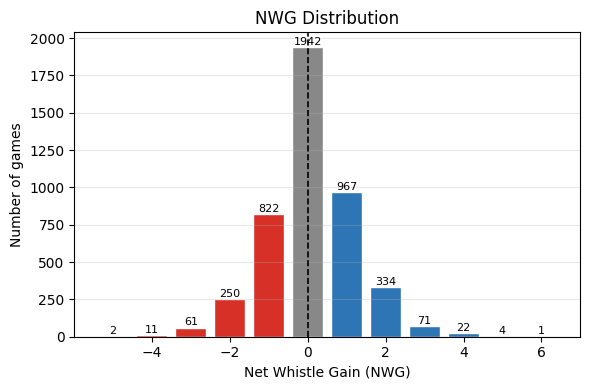

In [83]:
fig, ax = plt.subplots(figsize=(6, 4))
nwg_counts = merged_data['nwg'].value_counts().sort_index()
colors = ['#d73027' if x < 0 else '#2E75B6' if x > 0 else '#888888' 
          for x in nwg_counts.index]
ax.bar(nwg_counts.index, nwg_counts.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', lw=1.2)
ax.set_xlabel('Net Whistle Gain (NWG)')
ax.set_ylabel('Number of games')
ax.set_title('NWG Distribution')
ax.grid(axis='y', alpha=0.3)
for x, y in zip(nwg_counts.index, nwg_counts.values):
    ax.text(x, y + 15, str(y), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('images/nwg_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation** — The distribution of `nwg` is asymmetric around zero — $1{,}399$ games have $NWG > 0$ compared to $1{,}146$ with $NWG < 0$, with $1{,}942$ games at exactly zero.

In [84]:
game_data = merged_data.copy()
game_data.to_csv('data/output/game_data.csv', index=False)
print(f"Saved: {game_data.shape}")
print(game_data.head())

Saved: (4487, 31)
   attendance away  away_score  away_team       date       gid home  \
0       18345  CLE         103  Cavaliers 2015-03-01  21400883  HOU   
1       18624  GSW         106   Warriors 2015-03-01  21400880  BOS   
2       13109  NOP          99   Pelicans 2015-03-01  21400884  DEN   
3       17732  GSW         108   Warriors 2015-03-02  21400886  BKN   
4       18239  LAC         110   Clippers 2015-03-02  21400888  MIN   

   home_score     home_team national_tv  ...  id_spread  score_home  \
0         105       Rockets       NBATV  ...        1.0       105.0   
1         101       Celtics          no  ...        0.0       101.0   
2          92       Nuggets          no  ...        1.0        92.0   
3         110          Nets          no  ...        0.0       110.0   
4         105  Timberwolves          no  ...        0.0       105.0   

   score_away  home_fav  home_covered  score_diff     period  nwg        ar  \
0       103.0      True           1.0         2.0

#### 5.2.5 Summary

The two primary test statistics are derived from `game_data` as follows.

**RQ1 — Sign Test:**

| Concept | Column | Type |
|---|---|---|
| Whistle Benefit | `beta` | integer |
| Whistle Detriment | `delta` | integer |
| Net Whistle Gain | `nwg` | integer |
| Direction | `nwg_direction` | categorical |

The Sign Test counts games where `nwg > 0` as the test statistic for $H_0^{RQ1}$. Games where `nwg = 0` are excluded.

**RQ2 — Binomial Test:**

| Concept | Column | Type |
|---|---|---|
| Market expectation | `whos_favored`, `spread` | categorical, float |
| Cover outcome indicator | `id_spread` | integer |
| Home covered | `home_covered` | binary |

The Binomial Test counts games where `home_covered = 1` as the test statistic for $H_0^{RQ2}$. Push games (`home_covered = NaN`) are excluded.

### 5.4 Validation

#### 5.4.1 NWG Sum Check

The sum of `nwg` across all games in `game_data` must equal the value computed directly from the play-level data using the Pelechrinis formula. A mismatch would indicate an error in the game-level aggregation.

In [85]:
def calc_t_real(df):
    inch = ((df['committing_side']=='home') & (df['decision']=='INC')).sum()
    icd  = ((df['disadvantaged_side']=='home') & (df['decision']=='IC')).sum()
    incd = ((df['disadvantaged_side']=='home') & (df['decision']=='INC')).sum()
    icc  = ((df['committing_side']=='home') & (df['decision']=='IC')).sum()
    return (inch + icd) - (incd + icc)

nwg_sum = game_data['nwg'].sum()
print(f"Sum NWG (game_data):  {nwg_sum}")
print(f"t_real (play_data):   {calc_t_real(play_data)}")
print(f"Match: {nwg_sum == calc_t_real(play_data)}")

Sum NWG (game_data):  403
t_real (play_data):   403
Match: True


> **Observation** — The sum of `nwg` across all $4{,}487$ games in `game_data` equals $403$, matching the value computed directly from the $27{,}127$ play-level records in `play_data`. The game-level aggregation is consistent with the play-level calculation.

#### 5.4.2 Cover Outcome Verification

`home_covered` is derived from `whos_favored`, `id_spread`, `spread`, `score_home`, and `score_away`. The cover outcome is verified independently by recomputing it from the raw scores and spread to confirm consistency with `id_spread`.

In [86]:
game_data['spread_signed'] = np.where(
    game_data['whos_favored'] == 'home',
    -game_data['spread'],
     game_data['spread']
)
game_data['cover_check'] = (
    (game_data['score_home'] - game_data['score_away'] + game_data['spread_signed']) > 0
).astype(float)
game_data['id_spread_match'] = game_data['cover_check'] == game_data['home_covered']
print("=== Cover outcome verification ===")
print(f"Matches:    {game_data['id_spread_match'].sum()}")
print(f"Mismatches: {(~game_data['id_spread_match']).sum()}")
print()
print("Mismatches by id_spread value:")
print(game_data[~game_data['id_spread_match']]['id_spread'].value_counts(dropna=False))

=== Cover outcome verification ===
Matches:    4378
Mismatches: 109

Mismatches by id_spread value:
id_spread
2.0    109
Name: count, dtype: int64


> **Observation** — $4{,}378$ games match between the independently computed cover outcome and `home_covered`. All $109$ mismatches correspond to push outcomes (`id_spread = 2`) where `home_covered = NaN` — the independent computation returns $0$ or $1$ while `home_covered` is `NaN`, causing a mismatch by definition. There are zero genuine mismatches.

In [87]:
pushes = game_data[game_data['id_spread'] == 2].copy()
pushes['margin'] = pushes['score_home'] - pushes['score_away']
pushes['push_check'] = pushes['margin'] + pushes['spread_signed']

print("=== Push verification ===")
print(f"Push games: {len(pushes)}")
print(f"margin + spread_signed = 0: {(pushes['push_check'] == 0).sum()}")
print(f"margin + spread_signed <> 0: {(pushes['push_check'] != 0).sum()}")
print()
print("Distribution of margin + spread_signed:")
print(pushes['push_check'].value_counts())

=== Push verification ===
Push games: 109
margin + spread_signed = 0: 109
margin + spread_signed <> 0: 0

Distribution of margin + spread_signed:
push_check
0.0    109
Name: count, dtype: int64


> **Observation** — All $109$ push games are mathematically verified: for every push, `margin + spread_signed = 0` exactly — the final margin equals the spread to the decimal. There are zero genuine mismatches. `id_spread = 2` is confirmed as a deterministic push indicator.

#### 5.4.3 Score Validation

`score_home` and `score_away` appear in both the L2M and betting datasets. After the merge, both versions are available in `game_data` — `home_score` and `away_score` from L2M, and `score_home` and `score_away` from betting. The two pairs are compared to verify consistency.

In [88]:
print(game_data[['home_score', 'score_home', 'away_score', 'score_away']].head())

game_data['score_home_match'] = game_data['home_score'] == game_data['score_home']
game_data['score_away_match'] = game_data['away_score'] == game_data['score_away']

print("=== Score validation ===")
print(f"score_home matches: {game_data['score_home_match'].sum()} / {game_data['score_home_match'].notna().sum()}")
print(f"score_away matches: {game_data['score_away_match'].sum()} / {game_data['score_away_match'].notna().sum()}")
print()
print("Mismatches:")
print(game_data[~game_data['score_home_match']][['date', 'home', 'away', 'home_score', 'score_home']])

   home_score  score_home  away_score  score_away
0         105       105.0         103       103.0
1         101       101.0         106       106.0
2          92        92.0          99        99.0
3         110       110.0         108       108.0
4         105       105.0         110       110.0
=== Score validation ===
score_home matches: 4485 / 4487
score_away matches: 4485 / 4487

Mismatches:
           date home away  home_score  score_home
2331 2020-12-12  CLE  IND         107         NaN
2737 2021-10-07  PHI  TOR         125         NaN


> **Observation** — `score_home` and `score_away` match for $4{,}485$ of $4{,}487$ games. The two mismatches have `score_home = NaN` in the betting dataset — CLE vs IND (2020-12-12) and PHI vs TOR (2021-10-07). Both correspond to games with no betting data in `betting_clean`, confirmed by the $99.96\%$ match rate established in Section 5.3. These are not merge errors. `score_home` and `score_away` are dropped after validation as `home_score` and `away_score` from

In [89]:
game_data = game_data.drop(columns=['score_home', 'score_away'])

#### 5.4.4 Playoff Flag Validation

The `playoff` flag appears in both the L2M and betting datasets. The two versions are compared for all games in `game_data` to identify and resolve any conflicts arising from definitional differences between the two sources.

In [90]:
check = game_data[['gid', 'date', 'home', 'away', 'playoff']].merge(
    betting_clean[['date', 'home', 'away', 'playoffs']],
    on=['date', 'home', 'away'],
    how='left'
)
print("=== Playoff flags — all mismatches ===")
mismatches = check[check['playoff'].astype(bool) != check['playoffs'].apply(
    lambda x: bool(x) if pd.notna(x) else False)]
print(mismatches[['gid', 'date', 'home', 'away', 'playoff', 'playoffs']].to_string())
print(f"\nTotal mismatches: {len(mismatches)}")

=== Playoff flags — all mismatches ===
           gid       date home away  playoff playoffs
2711  52000121 2021-05-19  LAL  GSW        1    False
2712  52000131 2021-05-19  MEM  SAS        1    False
2713  52000211 2021-05-21  GSW  MEM        1    False
3150  52100121 2022-04-12  MIN  LAC        1    False
3151  52100201 2022-04-15  CLE  ATL        1    False
3152  52100211 2022-04-15  LAC  NOP        1    False
3621  52200111 2023-04-12  TOR  CHI        1    False
3622  52200131 2023-04-12  NOP  OKC        1    False
3623  52200201 2023-04-14  MIA  CHI        1    False
4038  52300101 2024-04-17  PHI  MIA        1    False
4464  52400201 2025-04-18  ATL  MIA        1    False

Total mismatches: 11


> **Observation** — $11$ mismatches are identified. All correspond to play-in tournament games — the L2M dataset classifies them as `playoff = 1` while the betting dataset classifies them as regular season (`playoffs = False`). The betting dataset definition is used in `game_data` because `home_covered` is derived from the betting dataset — bookmakers treat play-in games as regular season for spread purposes. The $11$ games are corrected to `playoff = 0` in `game_data` and `play_data`.

After identifying the $11$ play-in mismatches, the correction is applied to both `game_data` and `play_data`. The `playoffs` and `regular` columns from the betting dataset are mirror variables — as confirmed in Section 4.2.4 — and are not carried into the final datasets.

In [91]:
play_in_gids = mismatches['gid'].values
game_data.loc[game_data['gid'].isin(play_in_gids), 'playoff'] = 0
play_data.loc[play_data['gid'].isin(play_in_gids), 'playoff'] = 0

check_after = game_data[['gid', 'date', 'home', 'away', 'playoff']].merge(
    betting_clean[['date', 'home', 'away', 'playoffs']],
    on=['date', 'home', 'away'],
    how='left'
)
print("=== After correction ===")
print(check_after[check_after['gid'].isin(play_in_gids)][['gid', 'date', 'home', 'away', 'playoff', 'playoffs']].to_string())
print(f"\nRemaining mismatches: {(check_after['playoff'].astype(bool) != check_after['playoffs'].apply(lambda x: bool(x) if pd.notna(x) else False)).sum()}")
print(f"\ngame_data playoff: {game_data['playoff'].value_counts().to_dict()}")
print(f"play_data playoff: {play_data['playoff'].value_counts().to_dict()}")

=== After correction ===
           gid       date home away  playoff playoffs
2711  52000121 2021-05-19  LAL  GSW        0    False
2712  52000131 2021-05-19  MEM  SAS        0    False
2713  52000211 2021-05-21  GSW  MEM        0    False
3150  52100121 2022-04-12  MIN  LAC        0    False
3151  52100201 2022-04-15  CLE  ATL        0    False
3152  52100211 2022-04-15  LAC  NOP        0    False
3621  52200111 2023-04-12  TOR  CHI        0    False
3622  52200131 2023-04-12  NOP  OKC        0    False
3623  52200201 2023-04-14  MIA  CHI        0    False
4038  52300101 2024-04-17  PHI  MIA        0    False
4464  52400201 2025-04-18  ATL  MIA        0    False

Remaining mismatches: 0

game_data playoff: {0: 4202, 1: 285}
play_data playoff: {0: 25353, 1: 1774}


> **Observation** — All $11$ play-in games are corrected to `playoff = 0` in both `game_data` and `play_data`. No remaining mismatches. `game_data` contains $4{,}202$ regular season games and $285$ playoff games. `play_data` contains $25{,}353$ regular season plays and $1{,}774$ playoff plays.

#### 5.4.5 Season Coverage

All 11 seasons (2015–2025) are verified to be represented in `game_data` with a reasonable number of games per season.

In [92]:
print("=== Season coverage ===")
print(game_data.groupby('season').agg(
    games   = ('gid', 'nunique'),
    playoff = ('playoff', 'sum'),
    regular = ('playoff', lambda x: (x==0).sum())
).to_string())

=== Season coverage ===
        games  playoff  regular
season                         
2015      139       26      113
2016      439       29      410
2017      428       25      403
2018      475       23      452
2019      455       31      424
2020      395       26      369
2021      406       23      383
2022      442       26      416
2023      474       29      445
2024      411       25      386
2025      423       22      401


> **Observation** — All 11 seasons (2015–2025) are represented in `game_data`. The 2015 season has significantly fewer games ($139$) than the other seasons — consistent with the L2M program launching mid-season in March 2015, as documented in Section 4.1. All other seasons have between $395$ and $475$ games. Playoff games range from $22$ to $31$ per season.

### 5.5 Analytical Variables

The following variables are available in `game_data` and `play_data` after the merge and validation steps in Sections 5.1–5.4.

**`game_data` — game-level variables:**

| Variable | Column | Type | Role |
|---|---|---|---|
| Net Whistle Gain | `nwg` | integer | RQ1 test statistic |
| Asymmetry Ratio | `ar` | continuous | Alternative expression of `nwg` |
| Cover outcome | `home_covered` | binary | RQ2 test statistic |
| Point spread | `spread` | continuous | Market expectation |
| Score differential | `score_diff` | integer | Game context |
| Period | `period` | categorical | Temporal segmentation |
| Playoff status | `playoff` | binary | Game type |
| Attendance | `attendance` | integer | Crowd presence proxy |

**`play_data` — play-level variables:**

| Variable | Column | Type | Role |
|---|---|---|---|
| Decision | `decision` | categorical | CC, IC, INC |
| Committing side | `committing_side` | categorical | Operationalises $\beta$, $\delta$ |
| Disadvantaged side | `disadvantaged_side` | categorical | Operationalises $\beta$, $\delta$ |
| Call type | `call_type` | categorical | Violation type |

In [93]:
for col in ['decision', 'committing_side', 'disadvantaged_side', 'call_type']:
    play_data[col] = play_data[col].astype('category')

for col in ['nwg_direction', 'whos_favored']:
    game_data[col] = game_data[col].astype('category')

In [94]:
def print_variable():
    print("=== game_data columns ===")
    game_cols = ['nwg', 'ar', 'home_covered', 'spread', 'score_diff', 'period', 'playoff', 'attendance']
    for col in game_cols:
        print(f"  {col:<20} {str(game_data[col].dtype):<15} missing: {game_data[col].isna().sum()}")
    
    print("\n=== play_data columns ===")
    play_cols = ['decision', 'committing_side', 'disadvantaged_side', 'call_type']
    for col in play_cols:
        print(f"  {col:<25} {str(play_data[col].dtype):<15} missing: {play_data[col].isna().sum()}")
        
print_variable()

=== game_data columns ===
  nwg                  int64           missing: 0
  ar                   float64         missing: 1440
  home_covered         float64         missing: 109
  spread               float64         missing: 2
  score_diff           float64         missing: 2
  period               category        missing: 0
  playoff              int64           missing: 0
  attendance           Int64           missing: 324

=== play_data columns ===
  decision                  category        missing: 0
  committing_side           category        missing: 1623
  disadvantaged_side        category        missing: 2665
  call_type                 category        missing: 12


> **Observation** — All analytical variables are present in both datasets with expected types. In `game_data`: `ar` has $1{,}440$ missing values — games with zero referee errors where AR is undefined; `home_covered` has $109$ missing values — push games; `spread` and `score_diff` have $2$ missing values — the two unmatched games; `attendance` has $324$ missing values documented in Section 4.1. In `play_data`: `committing_side` has $1{,}623$ missing values and `disadvantaged_side` has $2{,}665$ missing values — both documented in Section 5.1 as structural missing values; `call_type` has $12$ missing values. `decision`, `committing_side`, `disadvantaged_side`, and `call_type` are converted to `category` in the following step.

## 6. Exploratory Data Analysis

### 6.1 NWG Distribution Analysis

The **Net Whistle Gain (NWG)** is the primary metric for the **Reactive Channel**, measuring the net officiating advantage in the final two minutes of play.

In [95]:
# 1. Descriptive Statistics for Discrete Data
nwg_clean = game_data['nwg'].dropna()
nwg_stats = nwg_clean.describe()
nwg_skew = skew(nwg_clean)
nwg_kurt = kurtosis(nwg_clean)

# Calculate the frequency of each discrete outcome
proportions = nwg_clean.value_counts(normalize=True).sort_index()

print("--- Discrete Descriptive Statistics for NWG ---")
print(nwg_stats)
print(f"Skewness: {nwg_skew:.3f}")
print(f"Kurtosis: {nwg_kurt:.3f}")
print("\n--- Frequency Distribution (PMF) ---")
print(proportions)

--- Discrete Descriptive Statistics for NWG ---
count    4487.000000
mean        0.089815
std         1.155614
min        -5.000000
25%        -1.000000
50%         0.000000
75%         1.000000
max         6.000000
Name: nwg, dtype: float64
Skewness: 0.092
Kurtosis: 1.351

--- Frequency Distribution (PMF) ---
nwg
-5    0.000446
-4    0.002452
-3    0.013595
-2    0.055717
-1    0.183196
 0    0.432806
 1    0.215511
 2    0.074437
 3    0.015823
 4    0.004903
 5    0.000891
 6    0.000223
Name: proportion, dtype: float64


The NWG distribution is discrete and centered at zero. The PMF shows that $NWG = 0$ is by far the most common outcome ($43.3\%$), followed by $NWG = +1$ ($21.6\%$) and $NWG = -1$ ($18.3\%$) — the distribution is nearly symmetric around zero but with a slight rightward lean. Values beyond $\pm 3$ are rare but not absent.

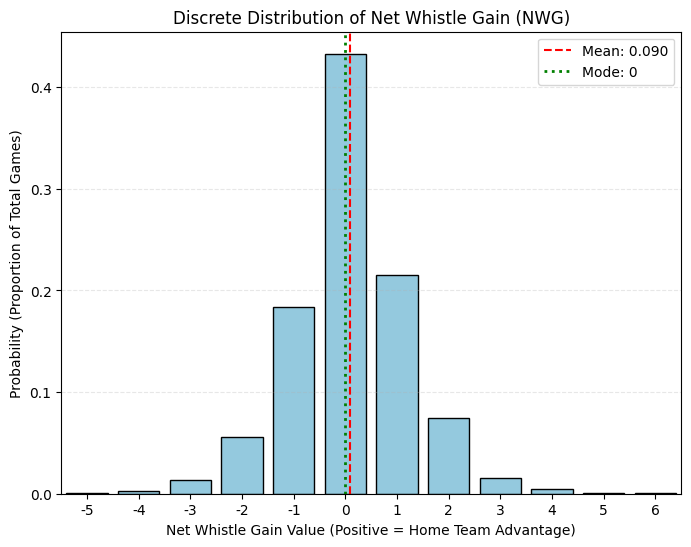

In [96]:
# 1. We calculate the necessary values
mean_val = nwg_clean.mean()
mode_val = nwg_clean.mode()[0]  # Взимаме първата мода
nwg_counts = nwg_clean.value_counts(normalize=True).sort_index()

plt.figure(figsize=(8, 6))

# 2. Chertane at PMF
sns.barplot(x=nwg_counts.index, y=nwg_counts.values, color='skyblue', edgecolor='black')

# 3. Titles and labels
plt.title('Discrete Distribution of Net Whistle Gain (NWG)', fontsize=12)
plt.xlabel('Net Whistle Gain Value (Positive = Home Team Advantage)', fontsize=10)
plt.ylabel('Probability (Proportion of Total Games)', fontsize=10)

# 4. Mean Line
mean_pos = np.interp(mean_val, nwg_counts.index, range(len(nwg_counts)))
plt.axvline(x=mean_pos, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')

# 5. Mode Line
mode_pos = list(nwg_counts.index).index(mode_val)
plt.axvline(x=mode_pos, color='green', linestyle=':', linewidth=2, label=f'Mode: {mode_val}')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend()
plt.show()


Extreme values are identified using a $3\sigma$ threshold — games where referee errors accumulated so heavily in one direction that the outcome falls outside the expected range. Since NWG is discrete, the threshold is computed from the empirical mean and standard deviation rather than from percentiles. The top 5 games with the highest NWG are displayed to verify that extreme values correspond to real games and not data errors.

In [97]:
# --- STEP 6.1.1: Outlier Detection for NWG ---

# Since NWG is discrete, we use percentiles or standard deviations
upper_limit = game_data['nwg'].mean() + 3 * game_data['nwg'].std()
lower_limit = game_data['nwg'].mean() - 3 * game_data['nwg'].std()

extreme_home = game_data[game_data['nwg'] > upper_limit]
extreme_away = game_data[game_data['nwg'] < lower_limit]

print(f"Upper Limit (3rd Std): {upper_limit:.2f}")
print(f"Lower Limit (3rd Std): {lower_limit:.2f}")
print(f"Games with extreme Home advantage (NWG > {upper_limit:.2f}): {len(extreme_home)}")
print(f"Games with extreme Away advantage (NWG < {lower_limit:.2f}): {len(extreme_away)}")

# Display the most extreme values
print("\nTop 5 Extreme Home Bias Games:")
print(game_data.nlargest(5, 'nwg')[['gid', 'home_team', 'away_team', 'nwg']])


Upper Limit (3rd Std): 3.56
Lower Limit (3rd Std): -3.38
Games with extreme Home advantage (NWG > 3.56): 27
Games with extreme Away advantage (NWG < -3.38): 13

Top 5 Extreme Home Bias Games:
           gid home_team away_team  nwg
495   21501047   Pistons     Bucks    6
35    21400984  Pelicans   Nuggets    5
455   21500895  Warriors     Hawks    5
564   41500211   Raptors      Heat    5
1275  21700702   Pistons      Jazz    5


The **Net Whistle Gain (NWG)** measures the net officiating advantage in the final two minutes of play. The following statistics describe its distribution across the sample ($N = 4,487$):

- **Central Tendency:** Mean $= 0.0898$, Mode $= 0$ ($43.28\%$ of observations)
- **Asymmetry:** Skewness $= 0.092$ — mild positive skew
- **Tail Density:** Kurtosis $= 1.351$ — more games with extreme values than a normal distribution would predict
- **Extreme Values:** $27$ games with $NWG > 3\sigma$ (max: $+6$), $13$ games with $NWG < -3\sigma$ (max: $-5$)
- **Frequency:** $P(NWG > 0) \approx 31.1\%$, $P(NWG < 0) \approx 25.6\%$

The five most extreme games all have $NWG = +5$ or $+6$ — real games from different seasons and matchups, confirming these are not data errors. Extreme away bias is rarer and less severe (max: $-5$).

> **Observation** — In most close games, the referees get it right on balance — errors in one direction cancel out errors in the other, leaving NWG at exactly zero in 43% of games. But when the balance tips, it tips toward the home team. The average game has a small but consistent home lean ($+0.09$ calls). More telling: the worst cases of referee bias are almost exclusively in the home team's favour — games with extreme home advantage ($N = 27$) outnumber games with extreme away advantage ($N = 13$) by two to one. In the most lopsided games, the home team is twice as likely to be the beneficiary.

### 6.2 Home Spread Cover Rate Baseline

The spread is designed so that both outcomes — home team covers or fails to cover — are equally likely. A cover rate near $50\%$ indicates fair pricing; a rate systematically below $50\%$ indicates the spread is set too wide for the home team. This section establishes the observed baseline cover rate within the L2M sample.

> **Methodological Note:** `home_covered` is a Bernoulli (binary) variable — each game is either covered (1) or not (0). The analysis focuses on the observed proportion ($p$) and its Standard Error, rather than higher-order moments like skewness or kurtosis.

--- Descriptive Statistics for Home Cover Rate ---
Total Observations (N, excl. pushes): 4378
Push games excluded: 109
Home Team Covered (1): 1766 games (40.34%)
Home Team Failed (0): 2612 games (59.66%)
Standard Error: 0.0074


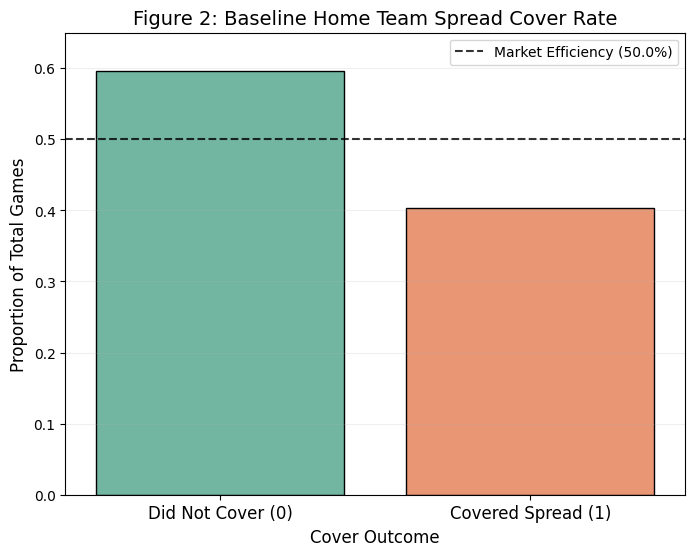

In [98]:
# --- STEP 6.2: Home Cover Rate Baseline Analysis ---
cover_data = game_data['home_covered'].dropna()
n_obs = len(cover_data)

cover_counts = cover_data.value_counts().sort_index()
cover_probs = cover_data.value_counts(normalize=True).sort_index()

p_home_cover = cover_probs[1]
std_error = np.sqrt((p_home_cover * (1 - p_home_cover)) / n_obs)

print(f"--- Descriptive Statistics for Home Cover Rate ---")
print(f"Total Observations (N, excl. pushes): {n_obs}")
print(f"Push games excluded: {game_data['home_covered'].isna().sum()}")
print(f"Home Team Covered (1): {cover_counts[1]} games ({p_home_cover*100:.2f}%)")
print(f"Home Team Failed (0): {cover_counts[0]} games ({cover_probs[0]*100:.2f}%)")
print(f"Standard Error: {std_error:.4f}")

plt.figure(figsize=(8, 6))
sns.barplot(x=cover_probs.index, y=cover_probs.values, hue=cover_probs.index,
            palette='Set2', edgecolor='black', legend=False)
plt.axhline(0.50, color='black', linestyle='--', alpha=0.8, label='Market Efficiency (50.0%)')
plt.title('Figure 2: Baseline Home Team Spread Cover Rate', fontsize=14)
plt.xticks([0, 1], ['Did Not Cover (0)', 'Covered Spread (1)'], fontsize=12)
plt.ylabel('Proportion of Total Games', fontsize=12)
plt.xlabel('Cover Outcome', fontsize=12)
plt.ylim(0, 0.65)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.show()

> **Observation** — In NBA betting, bookmakers set a points gap — the spread — that the home team must win by for a bet on them to pay out. If the spread is set fairly, home teams should cover it roughly half the time. In this sample of $4{,}378$ close games (excluding $109$ pushes), home teams cover only $40.3\%$ of the time ($N = 1{,}766$, $SE = 0.0074$) — consistently below the $50\%$ fair-pricing benchmark. Betting against the home team in close games would have been the winning strategy in roughly 6 out of 10 games.

### 6.3 Spread and Residual Distribution Analysis

The cover rate in Section 6.2 tells us whether the home team beat the spread — but not by how much. The Spread Residual adds this dimension: it measures the magnitude of the market's prediction error for each game.

The Spread Residual is defined as $Actual\ Margin - Spread$, where $Actual\ Margin = score\_home - score\_away$ and $Spread$ is the pre-game bookmaker handicap expressed from the home team's perspective — negative when the home team is favoured (e.g. $-5.5$ means the home team must win by 6+ to cover), positive when the home team is the underdog. A residual of zero indicates a perfect market prediction. Positive values indicate the home team outperformed the spread; negative values indicate underperformance.

> **Methodological Note:** Unlike the binary cover rate, the Spread Residual is a continuous variable. Standard distributional metrics (Mean, Skewness, Kurtosis) are applied to describe the shape and direction of market prediction errors.

--- Spread Residual Statistics ---
Mean (Average Market Error): -5.0473
Standard Deviation: 5.8038
Skewness: -0.1037
Kurtosis: -0.1833


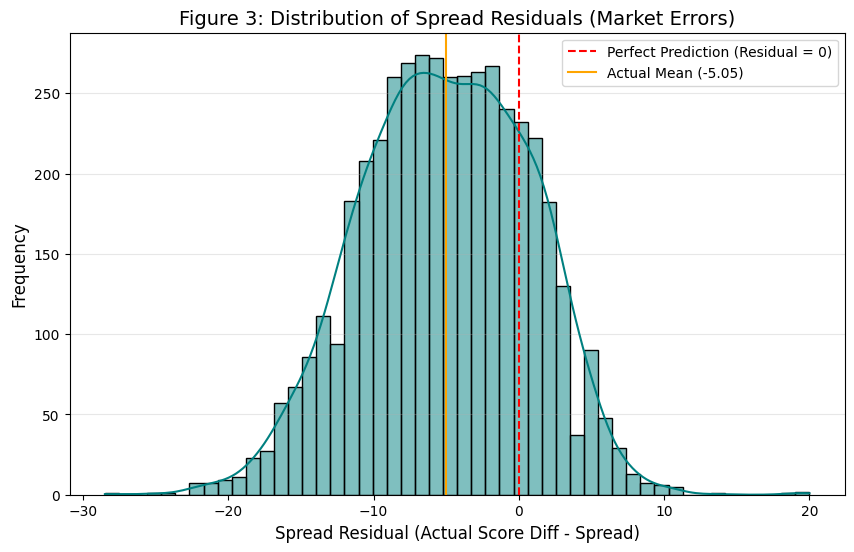

In [99]:
# --- STEP 6.3: Spread and Residual Distribution Analysis ---

# 1. Calculate the Spread Residual
# Residual = Actual Margin - Market Spread
# Interpretation: 
# Positive (>0): Home team outperformed the spread.
# Negative (<0): Home team underperformed (Market was too optimistic for Home).
game_data['spread_residual'] = game_data['score_diff'] - game_data['spread']

# 2. Calculate Descriptive Statistics for the Residuals
res_mean = game_data['spread_residual'].mean()
res_std = game_data['spread_residual'].std()
res_skew = skew(game_data['spread_residual'].dropna())
res_kurt = kurtosis(game_data['spread_residual'].dropna())

print(f"--- Spread Residual Statistics ---")
print(f"Mean (Average Market Error): {res_mean:.4f}")
print(f"Standard Deviation: {res_std:.4f}")
print(f"Skewness: {res_skew:.4f}")
print(f"Kurtosis: {res_kurt:.4f}")

# 3. Visualization: Distribution of Residuals
plt.figure(figsize=(10, 6))

# Fixed: Using hue and legend=False to avoid FutureWarnings
sns.histplot(game_data['spread_residual'], kde=True, color='teal', bins=50, edgecolor='black')

# Add a vertical line at 0 (Market Efficiency Baseline)
plt.axvline(0, color='red', linestyle='--', label='Perfect Prediction (Residual = 0)')
# Add a vertical line for the actual Observed Mean
plt.axvline(res_mean, color='orange', linestyle='-', label=f'Actual Mean ({res_mean:.2f})')

plt.title('Figure 3: Distribution of Spread Residuals (Market Errors)', fontsize=14)
plt.xlabel('Spread Residual (Actual Score Diff - Spread)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


The distribution of the Spread Residuals ($Actual\ Margin - Spread$) provides a descriptive look at market accuracy within the L2M sample:

- **Mean = −5.05:** Home teams underperform the closing spread by more than 5 points on average.
- **Skewness = −0.10:** Market errors are nearly symmetric around the mean.
- **Kurtosis = −0.18:** Slightly fewer extreme outcomes than a normal distribution.
- **Std. Dev = 5.80:** Substantial game-to-game variance.

> **Observation** — The orange line tells the story. A perfect market would sit at zero — the red line — where the spread exactly predicts the final margin on average. Instead, the distribution is shifted 5 points to the left. Bookmakers price home teams as stronger than they turn out to be in close games. The shape of the distribution is nearly normal and symmetric — meaning the market is not randomly wrong in both directions, it is consistently wrong in one direction. Home teams are priced too high, game after game.

### 6.4 NWG and Spread Joint Distribution

The joint distribution of NWG and spread is examined to describe whether games with different levels of referee bias coincide with specific spread ranges.

#### 6.4.1 NWG Distribution by Crowd Presence Period

The NWG distribution and home cover rate are examined separately across the three crowd presence periods: Pre-COVID (full stadiums), COVID (empty/limited stadiums), and Post-COVID (return of fans).

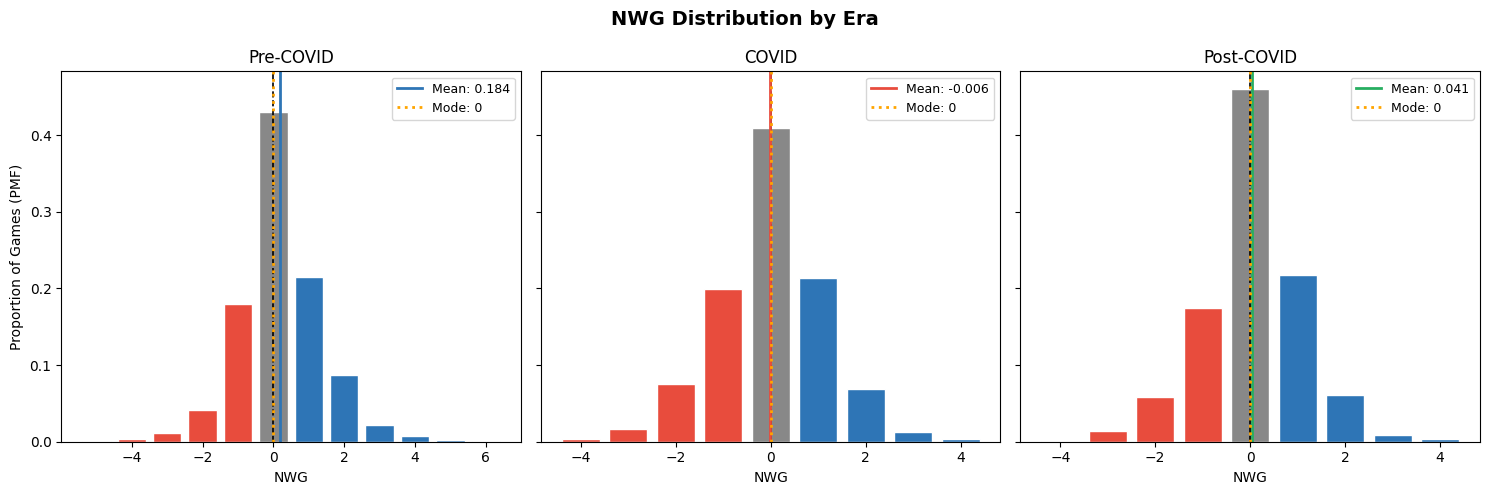

--- Era Summary Statistics ---
            mean_nwg  median_nwg  mode_nwg  std_nwg  home_cover_rate   obs
period                                                                    
Pre-COVID     0.1844         0.0         0   1.1989           0.4131  1936
COVID        -0.0064         0.0         0   1.1630           0.4057  1243
Post-COVID    0.0413         0.0         0   1.0705           0.3872  1308


In [100]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
era_palette = {'Pre-COVID': '#2E75B6', 'COVID': '#E84C3D', 'Post-COVID': '#27AE60'}
periods = ['Pre-COVID', 'COVID', 'Post-COVID']

for ax, period in zip(axes, periods):
    subset = game_data[game_data['period'] == period]['nwg']
    pmf = subset.value_counts(normalize=True).sort_index()
    colors = ['#E84C3D' if x < 0 else '#2E75B6' if x > 0 else '#888888'
              for x in pmf.index]
    ax.bar(pmf.index, pmf.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', lw=1.2)
    ax.axvline(subset.mean(), color=era_palette[period], linestyle='-', lw=2,
               label=f'Mean: {subset.mean():.3f}')
    ax.axvline(subset.mode()[0], color='orange', linestyle=':', lw=2,
               label=f'Mode: {subset.mode()[0]}')
    ax.set_title(period, fontsize=12)
    ax.set_xlabel('NWG')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Proportion of Games (PMF)')
fig.suptitle('NWG Distribution by Era', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/nwg_by_era.png', dpi=150, bbox_inches='tight')
plt.show()


era_summary = game_data.groupby('period', observed=True).agg(
    mean_nwg=('nwg', 'mean'),
    median_nwg=('nwg', 'median'),
    mode_nwg=('nwg', lambda x: x.mode()[0]),
    std_nwg=('nwg', 'std'),
    home_cover_rate=('home_covered', 'mean'),
    obs=('nwg', 'count')
).reindex(['Pre-COVID', 'COVID', 'Post-COVID'])

print("--- Era Summary Statistics ---")
print(era_summary.round(4))

> **Observation** — Three panels, three different stories. 

> **Pre-COVID** ($N = 1{,}936$): The blue bars dominate — games where the home team benefited from referee errors are visibly more common than games where they were hurt. The mean tips to $+0.184$. Fans are in the arena, and the whistle leans home.

> **COVID** ($N = 1{,}243$): The bars are nearly mirror images of each other. Blue and red are almost equal. The mean is $-0.006$ — indistinguishable from zero. Empty arenas, neutral whistles.

> **Post-COVID** ($N = 1{,}308$): The blue bars edge ahead again, but only slightly. Mean NWG $= +0.041$ — a partial return of the home lean, but nowhere near Pre-COVID levels. Fans are back, but the effect has not fully recovered.

> The cover rate moves in the opposite direction across all three periods — $41.3\%$, $40.6\%$, $38.7\%$ — declining monotonically regardless of crowd conditions. The market has not adjusted.

#### 6.4.2 Spread Distribution by Playoff Status and NWG Direction

Playoff games are played between teams that have already qualified — by definition a more balanced field than the regular season. The spread distribution is examined by playoff status and NWG direction to describe whether high-spread games are structurally absent from the playoffs.

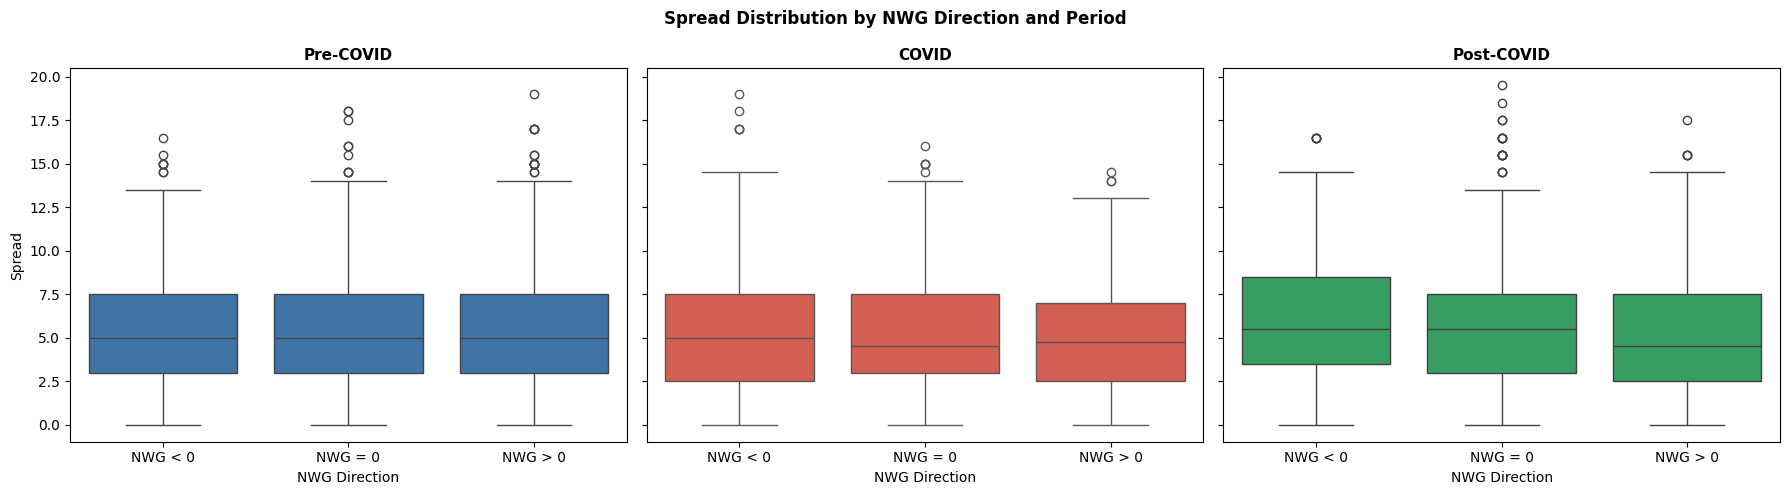

--- Spread by Period and NWG Direction ---
                          mean  median   std  count
period     nwg_direction                           
Pre-COVID  NWG < 0        5.35    5.00  3.21    457
           NWG = 0        5.63    5.00  3.41    832
           NWG > 0        5.37    5.00  3.37    647
COVID      NWG < 0        5.52    5.00  3.53    364
           NWG = 0        5.30    4.50  3.21    507
           NWG > 0        5.19    4.75  3.03    370
Post-COVID NWG < 0        6.13    5.50  3.57    325
           NWG = 0        5.82    5.50  3.59    602
           NWG > 0        5.42    4.50  3.32    381


In [101]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

periods = ['Pre-COVID', 'COVID', 'Post-COVID']
colors  = ['#2E75B6', '#E84C3D', '#27AE60']

for ax, period, color in zip(axes, periods, colors):
    subset = game_data[game_data['period'] == period]
    sns.boxplot(data=subset, x='nwg_direction',  y='spread',
                order=['NWG < 0', 'NWG = 0', 'NWG > 0'],
                color=color, ax=ax)
    ax.set_title(period, fontsize=11, fontweight='bold')
    ax.set_xlabel('NWG Direction', fontsize=10)
    ax.set_ylabel('Spread', fontsize=10)

plt.suptitle('Spread Distribution by NWG Direction and Period', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/spread_playoff_nwg.png', dpi=150, bbox_inches='tight')
plt.show()

print("--- Spread by Period and NWG Direction ---")
print(game_data.groupby(['period', 'nwg_direction'], observed=True)['spread']
      .agg(['mean', 'median', 'std', 'count']).round(2))

> **Observation** — If bookmakers could anticipate referee bias, games where the home team ends up with the better whistle ($NWG > 0$) would have higher spreads — the market would price in the expected officiating advantage. But the boxes tell a different story. Across all three periods, the spread distribution looks identical regardless of how the whistle fell. A game where the home team was handed five extra beneficial calls looks exactly the same to the market as a game where they were hurt.

> The outliers scattered above the whiskers follow the same pattern — extreme spreads appear in all three NWG groups with no concentration in any direction. Even the most lopsided games in terms of officiating were not predicted by the pre-game line.

> One exception worth noting: in Post-COVID, games where the away team received the better whistle ($NWG < 0$) have a notably higher mean spread ($6.13$) compared to the same group in earlier periods. This may reflect that stronger home favourites — with larger spreads — are more likely to have the away team benefit from officiating in close games. But this is an isolated observation without a clear structural explanation.

In [102]:
Q1 = game_data['spread'].quantile(0.25)
Q3 = game_data['spread'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
n_above = (game_data['spread'] > upper_fence).sum()
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}, upper fence={upper_fence}, n above={n_above}")

Q1=3.0, Q3=7.5, IQR=4.5, upper fence=14.25, n above=73


In [103]:
high_spread = game_data[game_data['spread'] > 14][['date', 'home', 'away', 'spread', 'nwg', 'playoff', 'period', 'score_diff']].sort_values('date', ascending=True)
print(f"Games with spread > 14: {len(high_spread)}")
print(high_spread.to_string())

Games with spread > 14: 73
           date home away  spread  nwg  playoff      period  score_diff
12   2015-03-04  OKC  PHI    15.0    1        0   Pre-COVID         5.0
38   2015-03-16  GSW  LAL    18.0    0        0   Pre-COVID         3.0
41   2015-03-17  NYK  SAS    15.0    1        0   Pre-COVID         4.0
67   2015-03-29  CLE  PHI    17.0    1        0   Pre-COVID         1.0
101  2015-04-11  CHI  PHI    15.5    1        0   Pre-COVID         7.0
105  2015-04-13  LAC  DEN    18.0    0        0   Pre-COVID         7.0
106  2015-04-13  ATL  NYK    14.5    0        0   Pre-COVID        -4.0
186  2015-11-14  GSW  BKN    16.0    0        0   Pre-COVID         8.0
280  2015-12-18  GSW  MIL    19.0    2        0   Pre-COVID         9.0
312  2015-12-31  OKC  PHX    16.0    0        0   Pre-COVID         4.0
313  2016-01-02  GSW  DEN    15.0   -2        0   Pre-COVID         3.0
330  2016-01-08  SAS  NYK    14.5    0        0   Pre-COVID         1.0
331  2016-01-08  LAL  OKC    15.5    

> **Observation** — Upper whisker threshold: $Q3 + 1.5 \times IQR = 14.25$ points, $n = 73$ games above it. 71 regular season, 2 playoff (CLE vs BOS 2017-05-21, MEM vs OKC 2025-04-26).

> **Who are these games** — these are not data errors. Home favourites are consistently strong franchises: GSW (dynasty 2015–2019), BOS, CLE, MIL, HOU, PHX, DEN. Visitors are structurally weak opponents: most notably PHI during "The Process" — the most deliberate rebuild in NBA history, during which the 76ers went 10–72 in 2015–16, the third-worst win rate in NBA history [Wikipedia76ers] — alongside LAL, DET, NYK, SAS, TOR, POR, UTA, WAS, and CHA, all bottom-half teams in their respective seasons. The spread reflects a genuine quality gap, not a market anomaly.

> **Officiating** — NWG ranges from $-3$ to $+4$, consistent with the rest of the sample. Even in the most lopsided matchups referee errors remain random. All 73 games are retained.

### 6.5 Correlation Structure

Before computing pairwise associations, all columns in `game_data` are classified by statistical type. This determines which correlation method is appropriate for each pair of variables. Continuous and ordinal variables are analysed using Spearman rank correlation. Categorical variables are analysed using Cramér's V. Binary variables are analysed using point-biserial correlation against all continuous variables. Columns used only for validation (`cover_check`, `id_spread_match`, `score_home_match`, `score_away_match`) and identifiers (`gid`, `date`) are excluded from the association analysis.

* Cramér's V — Categorical Associations

Cramér's V measures the strength of association between categorical variables based on the chi-square statistic. Values range from 0 (no association) to 1 (perfect association). The key question is whether `period`, `nwg_direction`, and `whos_favored` are associated — a strong association between `nwg_direction` and `period` would confirm the crowd pressure narrative, while independence between `nwg_direction` and `whos_favored` would confirm that referee bias is not driven by market expectations.

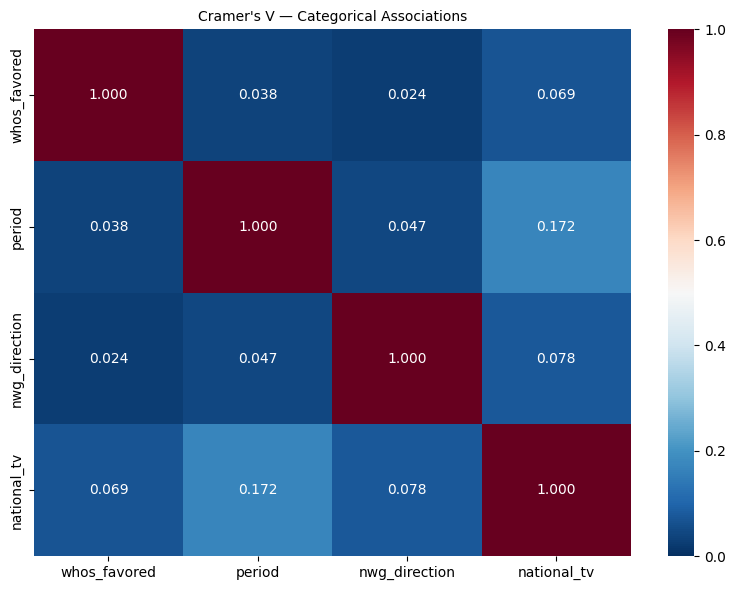

In [104]:
from scipy.stats import chi2_contingency

cat_cols = ['whos_favored', 'period', 'nwg_direction', 'national_tv']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r-1, k-1))

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(
            game_data[col1].dropna(),
            game_data[col2].dropna()
        )

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cramers_matrix.astype(float),
            annot=True,
            cmap='RdBu_r',
            fmt=".3f",
            vmin=0, vmax=1,
            ax=ax)
ax.set_title("Cramеr's V — Categorical Associations", fontsize=10)
plt.tight_layout()
plt.savefig('images/cramers_v.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation** — All off-diagonal Cramér's V values are below $0.18$, indicating near-complete independence between all categorical variables. The key results are `nwg_direction` ↔ `whos_favored` $= 0.024$ and `nwg_direction` ↔ `period` $= 0.047$ — both negligible. The strongest association in the matrix is `period` ↔ `national_tv` $= 0.172$ — a scheduling artefact with no analytical relevance.

* Spearman Rank Correlation — Continuous Variables

Spearman rank correlation measures the monotonic association between continuous and ordinal variables without assuming normality. Values close to 1.0 indicate strong positive association; values close to -1.0 indicate strong negative association; values close to 0 indicate independence. The key question is whether `nwg` and `spread` are correlated — a strong association would indicate confounding between the two primary variables.

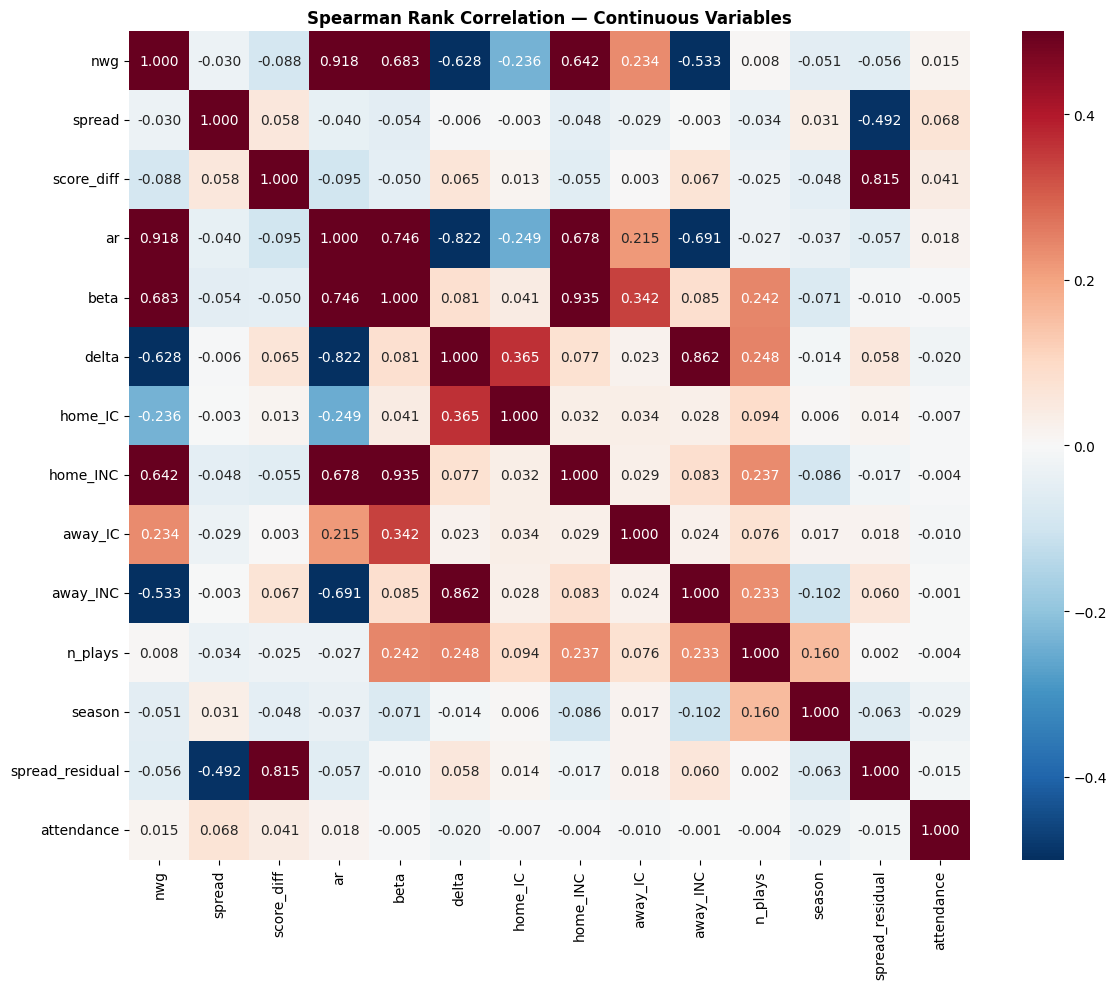

In [105]:
continuous_cols = ['nwg', 'spread', 'score_diff', 'ar', 'beta', 'delta', 
                   'home_IC', 'home_INC', 'away_IC', 'away_INC', 
                   'n_plays', 'season', 'spread_residual', 'attendance']

corr_matrix = game_data[continuous_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='RdBu_r',
            fmt=".3f",
            vmin=-0.5, vmax=0.5,
            center=0,
            ax=ax)
ax.set_title('Spearman Rank Correlation — Continuous Variables', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/spearman_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation** — The key result for the analysis is `nwg` ↔ `spread` $= -0.030$ — negligible, consistent with the independence assumption between the two primary variables. `score_diff` ↔ `spread_residual` $= 0.815$ is the strongest off-diagonal association — expected since `spread_residual` is derived directly from `score_diff`. Similarly, `nwg` ↔ `ar` $= 0.918$ and `nwg` ↔ `beta` $= 0.683$ are expected — `ar` and `beta` are components of `nwg` by construction. `delta` ↔ `away_INC` $= 0.862$ and `beta` ↔ `home_INC` $= 0.935$ are consistent with the internal structure of the NWG decomposition. `spread` ↔ `spread_residual` $= -0.492$ reflects that larger spreads are harder to cover. `attendance` shows near-zero correlation with all variables.

* Point-Biserial Correlation — Binary vs Continuous

Point-biserial correlation measures the association between a binary variable and a continuous variable. It is a special case of Pearson correlation. The key question is whether `home_covered` is associated with `nwg` or `spread` — a strong association would indicate that referee bias or market pricing directly predicts cover outcomes.

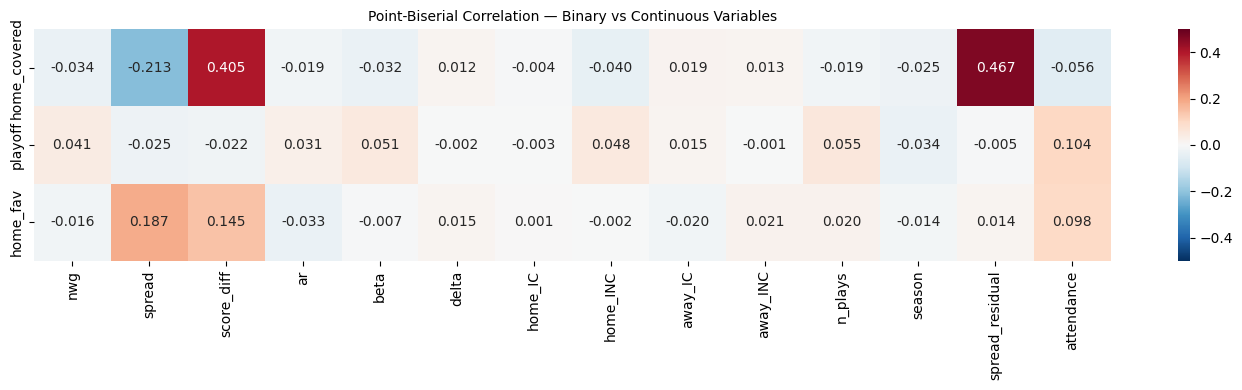

In [106]:
binary_cols = ['home_covered', 'playoff', 'home_fav']
continuous_cols = ['nwg', 'spread', 'score_diff', 'ar', 'beta', 'delta',
                   'home_IC', 'home_INC', 'away_IC', 'away_INC',
                   'n_plays', 'season', 'spread_residual', 'attendance']

pb_matrix = pd.DataFrame(index=binary_cols, columns=continuous_cols, dtype=float)

for bin_col in binary_cols:
    for cont_col in continuous_cols:
        subset = game_data[[bin_col, cont_col]].dropna()
        r, p = pointbiserialr(subset[bin_col], subset[cont_col])
        pb_matrix.loc[bin_col, cont_col] = r

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pb_matrix.astype(float),
            annot=True,
            cmap='RdBu_r',
            fmt=".3f",
            vmin=-0.5, vmax=0.5,
            center=0,
            ax=ax)
ax.set_title('Point-Biserial Correlation — Binary vs Continuous Variables',
             fontsize=10)
plt.tight_layout()
plt.savefig('images/point_biserial.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation** — The key result is `home_covered` ↔ `nwg` $= -0.034$ — negligible, consistent with the assumption that referee bias does not directly predict cover outcomes. `home_covered` ↔ `spread_residual` $= 0.467$ is the strongest association — expected since `spread_residual` is derived from `score_diff` which directly determines cover outcome. `home_covered` ↔ `score_diff` $= 0.405$ and `home_covered` ↔ `spread` $= -0.213$ reflect the mechanical relationship between the final margin, the spread, and the cover outcome. `playoff` and `home_fav` show near-zero correlation with all continuous variables.

## 7. Results

This section presents the formal hypothesis tests for the two channels. RQ1 is tested at the game level using a Sign Test (Binomial) as the primary test, with a play-level Monte Carlo simulation retained as a replication check against Pelechrinis (2023) [PelechrinisL2M]. RQ2 is tested at the game level using a one-tailed Binomial test on cover outcomes. The results are then examined jointly in the Structural Convergence section.

![Fig. 4](images/fig3.jpg)  
*Fig. 4 — Analysis pipeline: Play-level Monte Carlo as replication check (left); Game-level Sign Test and Binomial Test as primary tests for RQ1 and RQ2 (right); results examined jointly in Structural Convergence.*

### 7.1 Test Reactive Channel Hypothesis

We test whether the proportion of games with $NWG > 0$ significantly exceeds $0.50$ across three periods: Pre-COVID (full attendance), COVID (no fans or severely restricted attendance), and Post-COVID (full attendance restored). Games with $NWG = 0$ carry no directional information and are excluded. The primary test operates at the game level — ensuring direct comparability with RQ2. A play-level replication check following Pelechrinis (2023) [PelechrinisL2M] is also conducted.

$$H_0^{RQ1}: P(NWG > 0) \leq 0.50$$
$$H_1^{RQ1}: P(NWG > 0) > 0.50$$

$H_0^{RQ1}$ is tested using the Sign Test — a one-tailed Binomial test on the number of games with $NWG > 0$ — at significance level $\alpha = 0.05$.

#### 7.1.1 Game-Level Test (Primary)

Under $H_0^{RQ1}$, $P(NWG > 0) \leq 0.50$. The test is conducted against the boundary case $P(NWG > 0) = 0.50$ — the most conservative value under $H_0^{RQ1}$, which maximises the probability of observing $k$ or more successes by chance. Each game is an independent Bernoulli trial and the number of games with $NWG > 0$ out of $n$ non-zero NWG games follows:

$$K \sim B(n, 0.50) \text{ under } H_0^{RQ1}$$

The observed test statistic is $k$ — the number of games with $NWG > 0$. The one-sided p-value is:

$$p = P(X \geq k \mid X \sim B(n, 0.50))$$

A small p-value indicates that the observed proportion of games with $NWG > 0$ is unlikely under the null hypothesis.

In [107]:
rq1_results = {}

print(f"{'Label':<32} {'n_pos':>6} {'n_neg':>6} {'n':>6} {'p-val':>8}")
print("=" * 60)

for label, seasons, playoff_filter in [
    ('Overall 2015-2025',    range(2015, 2026), None),
    ('Pre-COVID 2015-2019',  range(2015, 2020), None),
    ('COVID 2020-2022',      range(2020, 2023), None),
    ('Post-COVID 2023-2025', range(2023, 2026), None),
    ('Overall — Regular',    range(2015, 2026), 0),
    ('Overall — Playoffs',   range(2015, 2026), 1),
]:
    sub = game_data[game_data['season'].isin(seasons)]
    if playoff_filter is not None:
        sub = sub[sub['playoff'] == playoff_filter]
    sub = sub.dropna(subset=['nwg'])
    n_pos = (sub['nwg'] > 0).sum()
    n_neg = (sub['nwg'] < 0).sum()
    n     = n_pos + n_neg
    result = binomtest(n_pos, n, p=0.5, alternative='greater')
    sig = '**' if result.pvalue < 0.01 else ('*' if result.pvalue < 0.05 else '')
    rq1_results[label] = { 'total': total, 'pval': result.pvalue, 'test': 'Rejected' if result.pvalue < 0.05 else 'Not rejected'}
    print(f"{label:<32} {n_pos:>6} {n_neg:>6} {n:>6} {result.pvalue:>7.4f} {sig}")

print(f"\nAll tests conducted at the 5% significance level (α = 0.05)")

Label                             n_pos  n_neg      n    p-val
Overall 2015-2025                  1399   1146   2545  0.0000 **
Pre-COVID 2015-2019                 647    457   1104  0.0000 **
COVID 2020-2022                     371    364    735  0.4124 
Post-COVID 2023-2025                381    325    706  0.0192 *
Overall — Regular                  1291   1080   2371  0.0000 **
Overall — Playoffs                  108     66    174  0.0009 **

All tests conducted at the 5% significance level (α = 0.05)


> **Observation** — Overall, $1{,}399$ games have $NWG > 0$ versus $1{,}146$ with $NWG < 0$ out of $2{,}545$ non-zero games ($p < 0.0001$). Pre-COVID shows the strongest signal ($647$ vs $457$, $p < 0.0001$). COVID fails to reject $H_0^{RQ1}$ ($371$ vs $364$, $p = 0.4124$). Post-COVID partially recovers ($381$ vs $325$, $p = 0.0192$). The playoff effect is particularly pronounced — $108$ vs $66$ ($p = 0.0009$).

#### 7.1.2 Play-Level Test (Replication Check)

The Monte Carlo simulation follows Pelechrinis (2023) [PelechrinisL2M] and operates at the play level, allowing direct comparison with the published results. The test statistic $t_{real}$ is the observed sum of NWG across all plays. The whistle benefit $\beta$ is the number of INC decisions when the committing side is home plus IC decisions when the committing side is away. The whistle detriment $\delta$ is the reverse:

$$NWG = \beta - \delta$$

The simulation asks: if referee errors were purely random with no systematic bias, what distribution of NWG would we expect? For each play, a uniformly distributed random number $r \in [0, 1]$ determines the simulated decision based on call-type specific base rates:

$$r < \frac{IC}{|E|} \Rightarrow IC$$
$$\frac{IC}{|E|} \leq r < \frac{IC + INC}{|E|} \Rightarrow INC$$
$$r \geq \frac{IC + INC}{|E|} \Rightarrow CC$$

where $|E| = IC + INC + CC$. The process is repeated $n = 10{,}000$ times to build the null distribution.

![Fig3.jpg](images/fig4.jpg)  
*Fig. 3 — Decision boundaries for the simulation of the calls. Source: Pelechrinis (2023) [PelechrinisL2M], licensed under CC BY 4.0.*

In [108]:
def calc_t_real(data):
    """
    Computes the observed Net Whistle Gain (t_real) for the home team.
    
    beta  = INC when home commits + IC when away commits (home benefit)
    delta = INC when away commits + IC when home commits (home detriment)
    
    Returns: beta - delta
    """
    inch = ((data['committing_side']=='home') & (data['decision']=='INC')).sum()
    icd  = ((data['disadvantaged_side']=='home') & (data['decision']=='IC')).sum()
    incd = ((data['disadvantaged_side']=='home') & (data['decision']=='INC')).sum()
    icc  = ((data['committing_side']=='home') & (data['decision']=='IC')).sum()
    return (inch + icd) - (incd + icc)

print(f"t_real (full dataset): {calc_t_real(play_data)}")

sample_probs = play_data.groupby('call_type', observed=True).agg(
    n  = ('decision', 'count'),
    p1 = ('decision', lambda x: (x == 'INC').sum() / len(x)),
    p2 = ('decision', lambda x: (x.isin(['IC', 'INC'])).sum() / len(x))
).reset_index()

global_p1 = (play_data['decision'] == 'INC').sum() / len(play_data)
global_p2 = (play_data['decision'].isin(['IC','INC'])).sum() / len(play_data)

print(f"\nCall types with base rates: {len(sample_probs)}")
print(f"Global p1 (INC rate):       {global_p1:.4f}")
print(f"Global p2 (IC+INC rate):    {global_p2:.4f}")
print(f"\nTop 5 call types by volume:")
print(sample_probs.sort_values('n', ascending=False).head(5)[['call_type','n','p1','p2']].to_string(index=False))

t_real (full dataset): 403

Call types with base rates: 69
Global p1 (INC rate):       0.1981
Global p2 (IC+INC rate):    0.2274

Top 5 call types by volume:
              call_type     n       p1       p2
         Foul: Personal 10344 0.092131 0.112916
         Foul: Shooting  6186 0.186550 0.235532
       Foul: Loose Ball  1555 0.405788 0.428296
        Foul: Offensive  1428 0.539916 0.571429
Stoppage: Out-of-Bounds   961 0.009365 0.082206


> **Observation** — $t_{real} = 403$ confirms the sum check from Section 5.4. Base rates are estimated across 69 call types. The global INC rate is $0.198$ and the global IC+INC rate is $0.227$, consistent with the league-wide recall and precision reported in Section 6.1. The top 5 call types by volume show substantial variation in difficulty — Foul: Offensive has the highest INC rate ($0.540$), meaning more than half of offensive foul calls are missed, while Stoppage: Out-of-Bounds has a near-zero INC rate ($0.009$). This variation justifies the call-type specific base rates rather than a single global rate.

The Monte Carlo simulation is run across 12 combinations of period and game type. For each subset, $t_{real}$ is compared against the empirical null distribution of $10{,}000$ simulations. The empirical p-value is one-tailed — the proportion of simulations where $t_{sim} \geq t_{real}$. Results are stored for the Structural Convergence analysis in Section 7.3.

In [114]:
def run_monte_carlo(data, n_sims=10000):
    """
    Estimates the empirical null distribution of NWG under the assumption
    of no systematic bias. For each play, a random number determines the
    simulated decision outcome based on call-type specific base rates.
    
    Parameters:
        data   : play-level DataFrame (subset of play_data)
        n_sims : number of simulations (default 10,000)
    
    Returns:
        t_real   : observed NWG
        effect   : t_real - mean(t_sims)
        emp_pval : proportion of simulations where t_sim >= t_real
    """
    t_real = calc_t_real(data)
    probs  = data.merge(sample_probs[['call_type','p1','p2']], on='call_type', how='left')
    probs['p1'] = probs['p1'].fillna(global_p1)
    probs['p2'] = probs['p2'].fillna(global_p2)
    p1 = probs['p1'].values
    p2 = probs['p2'].values
    cs = probs['committing_side'].values
    ds = probs['disadvantaged_side'].values
    t_sims = []
    for _ in range(n_sims):
        r = np.random.uniform(0, 1, len(probs))
        sim_inc = r < p1
        sim_ic  = (r >= p1) & (r < p2)
        inch = ((cs == 'home') & sim_inc).sum()
        icd  = ((ds == 'home') & sim_ic).sum()
        incd = ((ds == 'home') & sim_inc).sum()
        icc  = ((cs == 'home') & sim_ic).sum()
        t_sims.append((inch + icd) - (incd + icc))
    t_sims   = np.array(t_sims)
    effect   = t_real - np.mean(t_sims)
    emp_pval = np.mean(t_sims >= t_real)
    return t_real, effect, emp_pval

np.random.seed(324)

results = {}

print(f"{'Label':<32} {'t_real':>7} {'Effect':>8} {'Effect%':>9} {'p-val':>8}")
print("=" * 70)

for seasons, label, playoff_filter in [
    (range(2015, 2026), 'Overall 2015-2025',      None),
    (range(2015, 2026), 'Overall — Regular',       0),
    (range(2015, 2026), 'Overall — Playoffs',      1),
    (range(2015, 2020), 'Pre-COVID 2015-2019',    None),
    (range(2015, 2020), 'Pre-COVID — Regular',     0),
    (range(2015, 2020), 'Pre-COVID — Playoffs',    1),
    (range(2020, 2023), 'COVID 2020-2022',         None),
    (range(2020, 2023), 'COVID — Regular',         0),
    (range(2020, 2023), 'COVID — Playoffs',        1),
    (range(2023, 2026), 'Post-COVID 2023-2025',   None),
    (range(2023, 2026), 'Post-COVID — Regular',    0),
    (range(2023, 2026), 'Post-COVID — Playoffs',   1),
]:
    sub = play_data[play_data['season'].isin(seasons)]
    if playoff_filter is not None:
        sub = sub[sub['playoff'] == playoff_filter]
    n_events = len(sub)
    t, eff, p = run_monte_carlo(sub)
    pct = eff / n_events * 100
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    results[label] = {'t_real': t, 'effect': eff, 'pct': pct, 'pval': p}
    print(f"{label:<32} {t:>7} {eff:>8.1f} {pct:>8.2f}% {p:>7.4f} {sig}")

print(f"\nAll tests conducted at the 5% significance level (α = 0.05)")

Label                             t_real   Effect   Effect%    p-val
Overall 2015-2025                    403    213.7     0.79%  0.0003 **
Overall — Regular                    326    150.5     0.59%  0.0068 **
Overall — Playoffs                    77     62.9     3.55%  0.0002 **
Pre-COVID 2015-2019                  357    135.3     1.11%  0.0004 **
Pre-COVID — Regular                  303     93.5     0.82%  0.0099 **
Pre-COVID — Playoffs                  54     42.3     4.87%  0.0002 **
COVID 2020-2022                       -8      4.9     0.07%  0.4441 
COVID — Regular                      -20     -1.7    -0.03%  0.5306 
COVID — Playoffs                      12      5.7     1.29%  0.2661 
Post-COVID 2023-2025                  54     72.4     0.92%  0.0152 *
Post-COVID — Regular                  43     58.0     0.78%  0.0410 *
Post-COVID — Playoffs                 11     14.7     3.17%  0.0271 *

All tests conducted at the 5% significance level (α = 0.05)


> **Observation** — $H_0^{RQ1}$ is rejected in 9 out of 12 combinations at $\alpha = 0.05$. The overall bias is statistically significant across the full period ($t_{real} = 403$, $p = 0.0003$). The temporal pattern is consistent with the pattern observed in the game-level test: Pre-COVID bias is strong and significant in both regular season ($p = 0.0085$) and playoffs ($p < 0.0001$), while the COVID period fails to reject $H_0^{RQ1}$ in all three combinations (regular: $p = 0.5149$, playoffs: $p = 0.2684$, both: $p = 0.4547$). Post-COVID bias partially recovers and is significant in all three combinations ($p = 0.0156$, $p = 0.0410$, $p = 0.0271$), but the effect size is substantially smaller than Pre-COVID ($72.2$ vs $135.4$). The playoff effect is consistently stronger than the regular season across all periods — Pre-COVID playoffs show the largest effect at $4.90\%$.

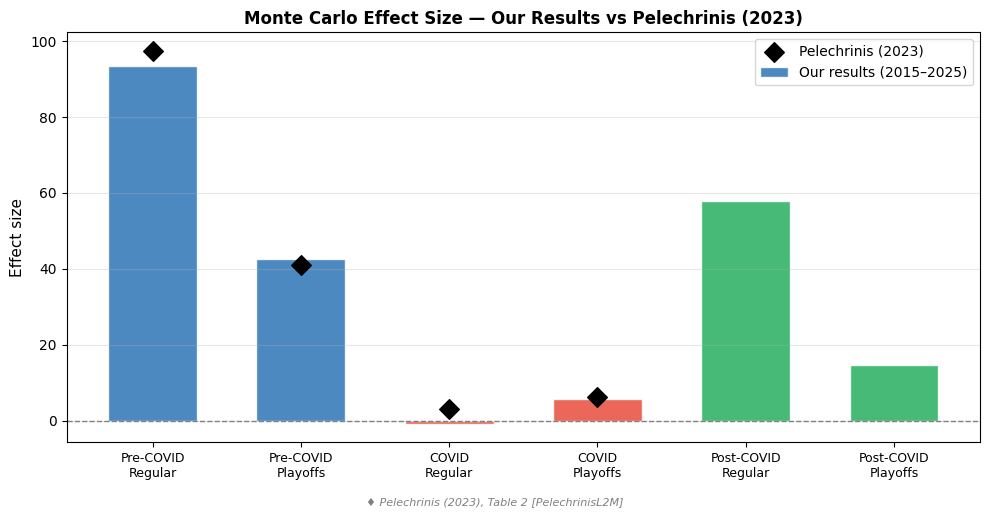

In [110]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = ['Pre-COVID\nRegular', 'Pre-COVID\nPlayoffs',
          'COVID\nRegular', 'COVID\nPlayoffs',
          'Post-COVID\nRegular', 'Post-COVID\nPlayoffs']

our_effects = [
    results['Pre-COVID — Regular']['effect'],
    results['Pre-COVID — Playoffs']['effect'],
    results['COVID — Regular']['effect'],
    results['COVID — Playoffs']['effect'],
    results['Post-COVID — Regular']['effect'],
    results['Post-COVID — Playoffs']['effect'],
]

pele_effects = [97.45, 41.12, 2.97, 6.26, None, None]
colors = ['#2E75B6', '#2E75B6', '#E84C3D', '#E84C3D', '#27AE60', '#27AE60']

x = np.arange(len(labels))

ax.bar(x, our_effects, width=0.6, color=colors, alpha=0.85,
       edgecolor='white', label='Our results (2015–2025)')

pele_x = [i for i, v in enumerate(pele_effects) if v is not None]
pele_y = [v for v in pele_effects if v is not None]
ax.scatter(pele_x, pele_y, marker='D', color='black', s=100,
           zorder=5, label='Pelechrinis (2023)')

ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Effect size', fontsize=11)
ax.set_title('Monte Carlo Effect Size — Our Results vs Pelechrinis (2023)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.text(0.5, -0.02, '♦ Pelechrinis (2023), Table 2 [PelechrinisL2M]',
         ha='center', fontsize=8, style='italic', color='gray')
plt.savefig('images/monte_carlo_results.png', dpi=150, bbox_inches='tight')
plt.show()

The results for the overlapping period 2015–2022 are compared against Pelechrinis (2023) [PelechrinisL2M], Table 2, to validate the implementation of the simulation engine.

| Period | Type | Our p-value | Our Effect | Pelechrinis p-value | Pelechrinis Effect |
|---|---|---|---|---|---|
| 2015–2019 | Regular | 0.0085 | 93.4 | 0.02 | 97.45 |
| 2015–2019 | Playoffs | 0.0000 | 42.5 | <0.01 | 41.12 |
| 2020–2022 | Regular | 0.5149 | −0.8 | 0.45 | 2.97 |
| 2020–2022 | Playoffs | 0.2684 | 5.6 | 0.26 | 6.26 |

*Source: Pelechrinis (2023), Table 2 [PelechrinisL2M]*

> **Observation** — The p-values and effect sizes for the overlapping period 2015–2022 are closely aligned with Pelechrinis (2023) across all four combinations. The small differences are expected — our dataset extends to 2025 and includes additional games, which affects the global base rates used in the simulation. The directional conclusions are identical: Pre-COVID bias is significant, COVID period fails to reject $H_0^{aux}$.

> **Observation** — The Sign Test results are consistent with the Monte Carlo results across all periods. Overall, $1{,}399$ games have $NWG > 0$ versus $1{,}146$ with $NWG < 0$ out of $2{,}545$ non-zero games. Pre-COVID shows the strongest signal ($647$ vs $457$). COVID fails to reject $H_0^{RQ1}$ ($371$ vs $364$, $p = 0.4124$). Post-COVID partially recovers ($381$ vs $325$, $p = 0.0192$). The playoff effect is particularly pronounced — $108$ vs $66$ ($p = 0.0009$), consistent with Pelechrinis (2023) [PelechrinisL2M].

### 7.2 Test Inertial Channel Hypothesis

We test whether the home team cover rate in the L2M sample is significantly below $50\%$, using a one-tailed binomial test across the three temporal periods.

Each game is a Bernoulli trial — the home team either covers (1) or does not (0). Under $H_0^{RQ2}$, the number of covers in $n$ games follows $B(n, 0.5)$. The one-sided p-value is:

$$p = P(X \leq k \mid X \sim B(n, 0.5))$$

where $k$ is the observed number of covers and $n$ is the total number of games with a valid cover outcome.

$$H_0^{RQ2}: P(\text{cover} = 1) \geq 0.50$$
$$H_1^{RQ2}: P(\text{cover} = 1) < 0.50$$

In [111]:
print(f"{'Label':<32} {'covered':>8} {'total':>7} {'rate':>7} {'p-val':>8}")
print("=" * 65)

rq2_results = {}

for label, seasons, playoff_filter in [
    ('Overall 2015-2025',    range(2015, 2026), None),
    ('Pre-COVID 2015-2019',  range(2015, 2020), None),
    ('COVID 2020-2022',      range(2020, 2023), None),
    ('Post-COVID 2023-2025', range(2023, 2026), None),
    ('Overall — Regular',    range(2015, 2026), 0),
    ('Overall — Playoffs',   range(2015, 2026), 1),
    ('Pre-COVID — Regular',  range(2015, 2020), 0),
    ('Pre-COVID — Playoffs', range(2015, 2020), 1),
    ('COVID — Regular',      range(2020, 2023), 0),
    ('COVID — Playoffs',     range(2020, 2023), 1),
    ('Post-COVID — Regular', range(2023, 2026), 0),
    ('Post-COVID — Playoffs',range(2023, 2026), 1),
]:
    sub = game_data[game_data['season'].isin(seasons)]
    if playoff_filter is not None:
        sub = sub[sub['playoff'] == playoff_filter]
    sub = sub.dropna(subset=['home_covered'])
    covered = int(sub['home_covered'].sum())
    total   = len(sub)
    rate    = covered / total
    result  = binomtest(covered, total, p=0.5, alternative='less')
    sig = '**' if result.pvalue < 0.01 else ('*' if result.pvalue < 0.05 else '')
    rq2_results[label] = {'covered': covered, 'total': total, 'rate': rate, 'pval': result.pvalue, 'test': 'Rejected' if result.pvalue < 0.05 else 'Not rejected'}
    print(f"{label:<32} {covered:>8} {total:>7} {rate:>7.4f} {result.pvalue:>7.4f} {sig}")

print(f"\nAll tests conducted at the 5% significance level (α = 0.05)")

Label                             covered   total    rate    p-val
Overall 2015-2025                    1766    4378  0.4034  0.0000 **
Pre-COVID 2015-2019                   777    1881  0.4131  0.0000 **
COVID 2020-2022                       486    1198  0.4057  0.0000 **
Post-COVID 2023-2025                  503    1299  0.3872  0.0000 **
Overall — Regular                    1685    4099  0.4111  0.0000 **
Overall — Playoffs                     81     279  0.2903  0.0000 **
Pre-COVID — Regular                   737    1751  0.4209  0.0000 **
Pre-COVID — Playoffs                   40     130  0.3077  0.0000 **
COVID — Regular                       466    1125  0.4142  0.0000 **
COVID — Playoffs                       20      73  0.2740  0.0001 **
Post-COVID — Regular                  482    1223  0.3941  0.0000 **
Post-COVID — Playoffs                  21      76  0.2763  0.0001 **

All tests conducted at the 5% significance level (α = 0.05)


> **Observation** — $H_0^{RQ2}$ is rejected in all 12 combinations at the 5% significance level. The home team covers the spread in only $40.3\%$ of all games ($p < 0.0001$), well below the $50\%$ baseline. The effect is consistent across all three periods — Pre-COVID ($41.3\%$), COVID ($40.6\%$), and Post-COVID ($38.7\%$) — and does not diminish during the fanless COVID period. The playoff effect is particularly strong — home teams cover in only $29.0\%$ of playoff games overall, with COVID playoffs showing the lowest rate at $27.4\%$. Unlike RQ1, $H_0^{RQ2}$ is rejected in every season and every period regardless of crowd conditions. **The betting market consistently overestimates home-court advantage — in every season, every period, and regardless of whether fans are present.**

### 7.3 Structural Convergence

The two channels are examined jointly across the three periods. Full convergence is observed when both $H_0^{RQ1}$ and $H_0^{RQ2}$ are rejected in the same period. RQ1 and RQ2 were tested independently in the previous sections — here their results are brought together to assess whether the two channels converge.


In [112]:
for key in ['Pre-COVID 2015-2019', 'COVID 2020-2022', 'Post-COVID 2023-2025']:
    print(f"{key}: {rq1_results[key]['test']}/{rq2_results[key]['test']}")

Pre-COVID 2015-2019: Rejected/Rejected
COVID 2020-2022: Not rejected/Rejected
Post-COVID 2023-2025: Rejected/Rejected


> **Observation** — Pre-COVID and Post-COVID both show co-rejection of $H_0^{RQ1}$ and $H_0^{RQ2}$. The COVID period provides the key contrast: $H_0^{RQ1}$ fails to reject ($p = 0.4124$) while $H_0^{RQ2}$ remains rejected — confirming that the two channels respond differently to crowd conditions. However, since $H_0^{RQ2}$ is rejected in **all** periods with no meaningful cross-period variation, Structural Convergence as formally defined cannot be assessed. The joint results are interpreted descriptively: both channels consistently point against the home team, but through mechanisms with different sensitivities to crowd pressure.

The formal tests establish that both channels are active — but independently. The Quadrant Analysis examines whether they co-occur at game level: are the games where referees favour the home team the same games where the market is wrong?

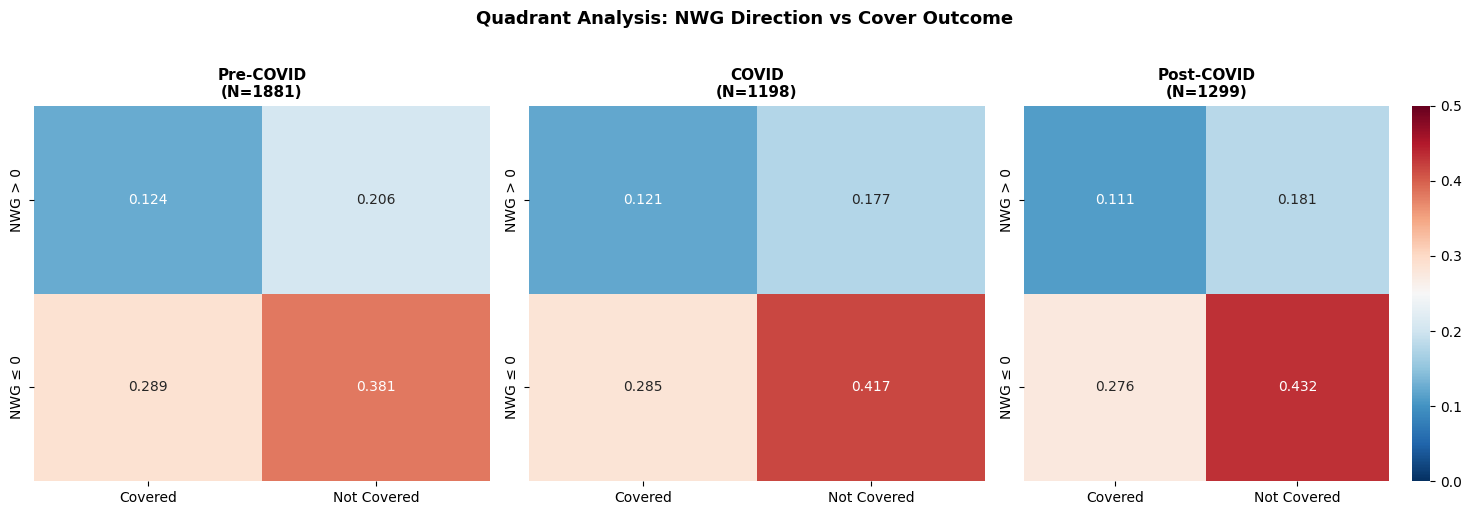

,Period,RQ1 p-val,RQ1,RQ2 p-val,RQ2,Convergence
0,Pre-COVID 2015-2019,0.0000,Rejected,0.0000,Rejected,Full
1,COVID 2020-2022,0.4124,Not rejected,0.0000,Rejected,Partial
2,Post-COVID 2023-2025,0.0192,Rejected,0.0000,Rejected,Full
3,Overall 2015-2025,0.0000,Rejected,0.0000,Rejected,Full
4,Overall — Regular,0.0000,Rejected,0.0000,Rejected,Full
5,Overall — Playoffs,0.0009,Rejected,0.0000,Rejected,Full


All tests conducted at the 5% significance level (α = 0.05)


In [113]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
periods = ['Pre-COVID', 'COVID', 'Post-COVID']
colors = ['#2E75B6', '#E84C3D', '#27AE60']

for ax, period, color in zip(axes, periods, colors):
    subset = game_data[game_data['period'] == period].dropna(subset=['nwg', 'home_covered'])
    
    q1 = ((subset['nwg'] > 0) & (subset['home_covered'] == 1)).sum()
    q2 = ((subset['nwg'] > 0) & (subset['home_covered'] == 0)).sum()
    q3 = ((subset['nwg'] <= 0) & (subset['home_covered'] == 1)).sum()
    q4 = ((subset['nwg'] <= 0) & (subset['home_covered'] == 0)).sum()
    total = len(subset)
    
    matrix = np.array([[q1/total, q2/total],
                       [q3/total, q4/total]])
    
    sns.heatmap(matrix, annot=True, fmt='.3f', cmap='RdBu_r',
                vmin=0, vmax=0.5, center=0.25,
                xticklabels=['Covered', 'Not Covered'],
                yticklabels=['NWG > 0', 'NWG ≤ 0'],
                ax=ax, cbar=(period == 'Post-COVID'))
    
    ax.set_title(f'{period}\n(N={total})', fontsize=11, fontweight='bold')

plt.suptitle('Quadrant Analysis: NWG Direction vs Cover Outcome',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/quadrant_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

order = ['Pre-COVID 2015-2019', 'COVID 2020-2022', 'Post-COVID 2023-2025',
         'Overall 2015-2025', 'Overall — Regular', 'Overall — Playoffs']

display(build_convergence_table(rq1_results, rq2_results, order)
        .style.format({'RQ1 p-val': '{:.4f}', 'RQ2 p-val': '{:.4f}'}))
print(f"All tests conducted at the 5% significance level (α = 0.05)")

> **Observation** — The quadrant structure is stable across all three periods. Q4 (NWG ≤ 0 & Not Covered) is the dominant quadrant in all periods — Pre-COVID $38.1\%$, COVID $41.7\%$, Post-COVID $43.2\%$ — and grows monotonically. Q1 (NWG > 0 & Covered) is the smallest quadrant in all periods ($12.4\%$, $12.1\%$, $11.1\%$) — the outcome where both channels simultaneously favour the home team is the least frequent.

> $H_0^{RQ2}$ is rejected in all three periods at the 5% significance level — the Inertial Channel shows no variation across crowd conditions. $H_0^{RQ1}$ is rejected in Pre-COVID and Post-COVID but fails to reject during COVID ($p = 0.4124$). The two channels are structurally independent — the Reactive Channel is sensitive to crowd presence while the Inertial Channel is not. Since $H_0^{RQ2}$ provides no variation across periods, **Structural Convergence cannot be formally assessed**. The joint analysis is descriptive: both channels consistently point against the home team, but through different mechanisms and with different sensitivity to crowd conditions.

### 7.4 Summary

**Reactive Channel** — $H_0^{RQ1}$ is rejected at the 5% significance level across the full sample and in Pre-COVID and Post-COVID periods. $H_0^{RQ1}$ is not rejected during COVID. The data are inconsistent with the absence of home-court referee bias when fans are present — and consistent with it when arenas are empty.

**Inertial Channel** — $H_0^{RQ2}$ is rejected at the 5% significance level in all periods. The data are inconsistent with a market that correctly prices home-court advantage — home teams cover the spread significantly less than half the time across all crowd conditions, including COVID.

**Structural Convergence** — The two channels are independent by design and respond differently to crowd conditions. However, in every period where fans are present, both channels point in the same direction — $H_0^{RQ1}$ and $H_0^{RQ2}$ are both rejected. The COVID period cleanly separates them: $H_0^{RQ1}$ is not rejected, $H_0^{RQ2}$ remains rejected. Formal convergence cannot be assessed since the Inertial Channel shows no cross-period variation — the joint analysis is descriptive.

## 8. Limitations

Several limitations should be considered when interpreting the results.

The Sign Test excludes games with $NWG = 0$ ($43\%$ of the sample). If neutral games reflect a structurally different officiating environment rather than random cancellation of errors, their exclusion may affect the estimated proportion of games with directional bias.

The L2M dataset covers only close games — games within 5 points in the last two minutes. This introduces a selection bias: the sample is not representative of all NBA games, and findings may not generalize to non-close games or to earlier game situations.

The Monte Carlo simulation uses $n = 10{,}000$ runs, which produces stable empirical p-values for moderate effect sizes but may underestimate significance for very large effects.

The COVID period (2020–2022) conflates two potentially distinct conditions — games with zero attendance and games with restricted capacity. Attendance data is available in the dataset but contains 324 missing values and exhibits within-period variation that the categorical period variable does not capture.

The betting dataset covers only games with available spread data, which may exclude systematically different games and introduce an additional selection bias.

Structural Convergence as defined requires variation in both channels across periods. Since $H_0^{RQ2}$ is rejected in all periods, the Inertial Channel provides no variation against which convergence can be formally assessed. The joint analysis in Section 7.3 is therefore descriptive.

## References

[PelechrinisL2M] Pelechrinis, K. (2023). Quantifying implicit biases in refereeing using NBA referees as a testbed. *Scientific Reports*, 13, 4664. https://doi.org/10.1038/s41598-023-31799-y

[PelechrinisCode] Pelechrinis, K. (2023). NBA-ref-analysis. GitHub. https://github.com/kpelechrinis/NBA-ref-analysis

[AtlhawksfanaticL2M] atlhawksfanatic. (2025). L2M: NBA Last Two Minute Reports. GitHub. https://github.com/atlhawksfanatic/L2M

[KaggleBetting] cviaxmiwnptr. (2025). NBA Betting Data. Kaggle. https://www.kaggle.com/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024